In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import cvxpy as cp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset



In [3]:
class DoublePendulumDynamics:
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g

    def f(self, state, u):
        # state: [θ1, θ2, ω1, ω2], u: [τ1, τ2]
        θ1, θ2, ω1, ω2 = state
        m1, m2, l1, l2, g = self.m1, self.m2, self.l1, self.l2, self.g
        Δ = θ2 - θ1
        M11 = (m1 + m2) * l1**2
        M12 = m2 * l1 * l2 * np.cos(Δ)
        M21 = M12
        M22 = m2 * l2**2
        C1 = -m2 * l1 * l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
        C2 = m2 * l1 * l2 * ω1**2 * np.sin(Δ)
        G1 = -(m1 + m2) * g * l1 * np.sin(θ1)
        G2 = -m2 * g * l2 * np.sin(θ2)
        M = np.array([[M11, M12],[M21, M22]])
        C = np.array([C1, C2])
        G = np.array([G1, G2])
        # 关节加速度
        dd = np.linalg.inv(M) @ (u - C - G)
        return np.array([ω1, ω2, dd[0], dd[1]])

    def rk4_step(self, state, u, dt):
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2*k1, u)
        k3 = self.f(state + dt/2*k2, u)
        k4 = self.f(state + dt*k3, u)
        return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    
    def forward_kinematics(self, state):
        """
        计算给定状态下末端执行器在平面中的(x, y)位置
        state: [θ1, θ2, ω1, ω2]
        返回: np.array([x_e, y_e])
        """
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])


# %%
# 2. 可视化接口：绘制双摆姿态

def plot_pendulum(ax, θ1, θ2, l1=1.0, l2=1.0, **kwargs):
    x1, y1 = l1*np.sin(θ1), -l1*np.cos(θ1)
    x2, y2 = x1 + l2*np.sin(θ2), y1 - l2*np.cos(θ2)
    ax.plot([0, x1], [0, y1], lw=2, **kwargs)
    ax.plot([x1, x2], [y1, y2], lw=2, **kwargs)
    ax.scatter([0, x1, x2], [0, y1, y2], s=50, **kwargs)




In [4]:
# %%
# 3. MPC控制器设计
class MPCController:
    def __init__(self, dyn, N=20, dt=0.1, Q=np.diag([10,10,1,1]), R=np.diag([0.1,0.1])):
        self.dyn = dyn
        self.N, self.dt = N, dt
        self.Q, self.R = Q, R
        self.nx, self.nu = 4, 2

    def solve(self, x0, x_target):
        # 优化变量
        X = cp.Variable((self.nx, self.N+1))
        U = cp.Variable((self.nu, self.N))
        cost = 0
        constraints = []
        # 初始状态约束
        constraints += [X[:,0] == x0]
        for k in range(self.N):
            # 线性化或直接用Euler近似
            xk = X[:,k]
            uk = U[:,k]
            x_next = xk + self.dt * self.dyn.f(xk.value if xk.value is not None else x0, uk) if False else xk + self.dt * self.dyn.f(xk, uk)
            constraints += [X[:,k+1] == xk + self.dt * self.dyn.f(xk, uk)]
            cost += cp.quad_form(X[:,k]-x_target, self.Q) + cp.quad_form(uk, self.R)
        cost += cp.quad_form(X[:,self.N]-x_target, self.Q)
        prob = cp.Problem(cp.Minimize(cost), constraints)
        prob.solve(solver=cp.OSQP)
        return U.value[:,0]  # 仅返回首步控制


start status: θ1=3.04, θ2=-1.05, ω1=0.00, ω2=0.00


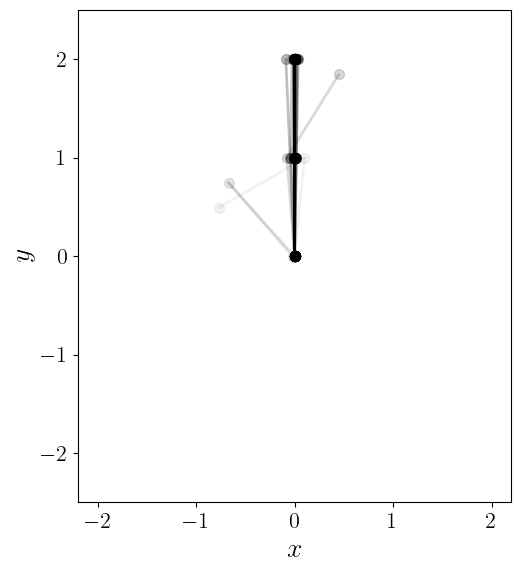

In [5]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import cvxpy as cp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# %%
# 1. 双摆动力学定义（用于仿真）
class DoublePendulumDynamics:
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g

    def f(self, state, u):
        θ1, θ2, ω1, ω2 = state
        Δ = θ2 - θ1
        M11 = (self.m1 + self.m2) * self.l1**2
        M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
        M21 = M12
        M22 = self.m2 * self.l2**2
        C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
        C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
        G1 = -(self.m1 + self.m2) * self.g * self.l1 * np.sin(θ1)
        G2 = -self.m2 * self.g * self.l2 * np.sin(θ2)
        M = np.array([[M11, M12],[M21, M22]])
        dd = np.linalg.inv(M) @ (u - np.array([C1, C2]) - np.array([G1, G2]))
        return np.array([ω1, ω2, dd[0], dd[1]])

    def rk4_step(self, state, u, dt):
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2*k1, u)
        k3 = self.f(state + dt/2*k2, u)
        k4 = self.f(state + dt*k3, u)
        return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)

# %%
# 2. 可视化接口：绘制双摆姿态

def plot_pendulum(ax, θ1, θ2, l1=1.0, l2=1.0, **kwargs):
    x1, y1 = l1*np.sin(θ1), -l1*np.cos(θ1)
    x2, y2 = x1 + l2*np.sin(θ2), y1 - l2*np.cos(θ2)
    ax.plot([0, x1], [0, y1], lw=2, **kwargs)
    ax.plot([x1, x2], [y1, y2], lw=2, **kwargs)
    ax.scatter([0, x1, x2], [0, y1, y2], s=50, **kwargs)

# %%
# 3. MPC 控制器设计（线性近似积分）
class MPCController:
    def __init__(self, dyn, N=20, dt=0.1, Q=None, R=None):
        self.dyn = dyn
        self.N, self.dt = N, dt
        self.nx, self.nu = 4, 2
        self.Q = np.diag([10,10,1,1]) if Q is None else Q
        self.R = np.diag([0.1,0.1]) if R is None else R

    def solve(self, x0, x_target):
        X = cp.Variable((self.nx, self.N+1))
        U = cp.Variable((self.nu, self.N))
        cost = 0
        constraints = [X[:,0] == x0]
        for k in range(self.N):
            xk = X[:,k]
            uk = U[:,k]
            # 线性积分：θ_dot=ω, ω_dot≈u
            next_est = cp.hstack([xk[2], xk[3], uk[0], uk[1]])
            constraints += [X[:,k+1] == xk + self.dt * next_est]
            cost += cp.quad_form(xk - x_target, self.Q) + cp.quad_form(uk, self.R)
        cost += cp.quad_form(X[:,self.N] - x_target, self.Q)
        prob = cp.Problem(cp.Minimize(cost), constraints)
        prob.solve(solver=cp.OSQP)
        return U.value[:,0]

# %%
# 4. 运行示例：随机初始状态，用 MPC 控制至倒立并保持，仿真并可视化
np.random.seed(56)  # 设置随机种子以便复现

x0 = np.concatenate([np.random.uniform(-np.pi, np.pi, 2), np.zeros(2)])

print(f"start status: θ1={x0[0]:.2f}, θ2={x0[1]:.2f}, ω1={x0[2]:.2f}, ω2={x0[3]:.2f}")

x_target = np.array([np.pi, np.pi, 0.0, 0.0])
dyn = DoublePendulumDynamics()
mpc = MPCController(dyn, N=20, dt=0.1)

T = 100
dt = 0.1
times = np.arange(T+1) * dt
states = [x0.copy()]
actions = []
for _ in range(T):
    u = mpc.solve(states[-1], x_target)
    actions.append(u)
    states.append(dyn.rk4_step(states[-1], u, dt))
states = np.array(states)
actions = np.array(actions)  
# times 长度是 T+1，这里 torque 只有 T 步，去掉最后一个时间点
t_u = times[:-1]           

#fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(6,10))
fig, ax1 = plt.subplots(figsize=(6,6))
# 1) 画角度
# ax1.plot(times, states[:,0], label='θ1')
# ax1.plot(times, states[:,1], label='θ2')
# ax1.set_ylabel('angle (rad)')
# ax1.legend()
# ax1.set_title('angle vs time')

for i in range(20):
    idx = int(i * (T / 19))
    alpha = (i+1)/20
    plot_pendulum(ax1, states[idx,0], states[idx,1], alpha=alpha, color='black')
#ax1.set_title('trajectory of double pendulum') 
ax1.set_aspect('equal')
ax1.set_xlabel('$x$', fontsize=20)
ax1.set_ylabel('$y$', fontsize=20)
ax1.set_xlim(-2.2, 2.2)
ax1.set_ylim(-2.5, 2.5)

# 3) 画力矩
# ax3.plot(t_u, actions[:,0], label='τ1')
# ax3.plot(t_u, actions[:,1], label='τ2')
# ax3.set_xlabel('time (s)')
# ax3.set_ylabel('torque (N·m)')
# ax3.legend()
# ax3.set_title('MPC torque vs time')

plt.tight_layout()
plt.show()


⚠️ Found early stop at trial 3, step 1


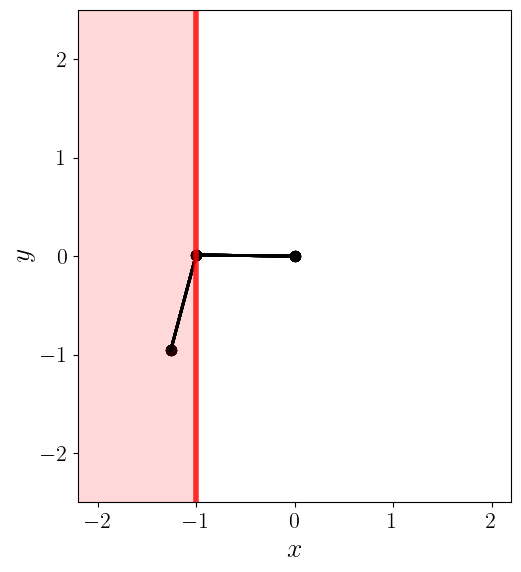

In [6]:
# %%
# 找到一条末端执行器 x < -1.0 的轨迹并画成残影图

def forward_kinematics(state, l1=1.0, l2=1.0):
    θ1, θ2 = state[0], state[1]
    x1 = l1 * np.sin(θ1)
    y1 = -l1 * np.cos(θ1)
    x2 = x1 + l2 * np.sin(θ2)
    y2 = y1 - l2 * np.cos(θ2)
    return np.array([x2, y2])

dyn = DoublePendulumDynamics()
mpc = MPCController(dyn, N=20, dt=0.1)

T = 100
dt = 0.1
max_trials = 100

for trial in range(max_trials):
    x0 = np.concatenate([np.random.uniform(-np.pi, np.pi, 2), np.zeros(2)])
    states = [x0.copy()]
    actions = []
    ee_traj = []
    stop_idx = None

    for t in range(T):
        u = mpc.solve(states[-1], np.array([np.pi, np.pi, 0.0, 0.0]))
        actions.append(u)
        new_state = dyn.rk4_step(states[-1], u, dt)
        ee_pos = forward_kinematics(new_state)
        ee_traj.append(ee_pos)

        if ee_pos[0] < -1.0:
            stop_idx = t + 1  # +1 是因为这是撞线之后的那个点
            break
        states.append(new_state)

    if stop_idx is not None:
        print(f"⚠️ Found early stop at trial {trial+1}, step {stop_idx}")
        break

# 截取到越界前为止
states = states[:stop_idx+1]  # 包含撞线的那一帧

# 可视化这一条轨迹的残影
fig, ax = plt.subplots(figsize=(6,6))

for i in range(20):
    idx = int(i * (len(states) - 1) / 19)
    alpha = (i+1)/20
    plot_pendulum(ax, states[idx][0], states[idx][1], alpha=alpha, color='black')


x_min = -1.0
ax.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8)
ax.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red')

ax.set_aspect('equal')
ax.set_xlabel('$x$', fontsize=20)
ax.set_ylabel('$y$', fontsize=20)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()


✅ Found successful swing-up in trial 3


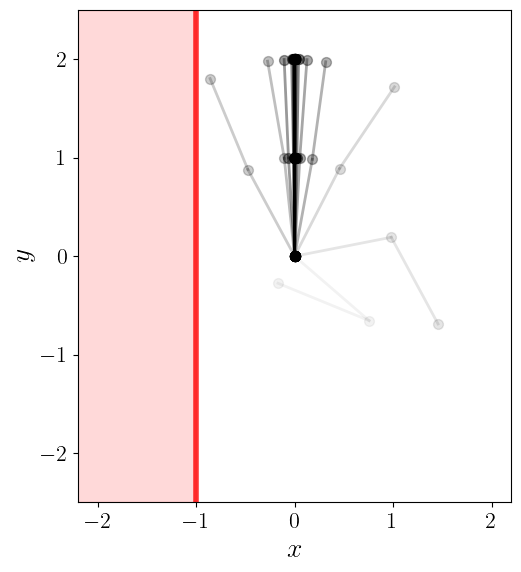

In [76]:
# %%
# 找到一条成功“摆上去”（未穿过 x < -1.0）的轨迹并画残影图

def forward_kinematics(state, l1=1.0, l2=1.0):
    θ1, θ2 = state[0], state[1]
    x1 = l1 * np.sin(θ1)
    y1 = -l1 * np.cos(θ1)
    x2 = x1 + l2 * np.sin(θ2)
    y2 = y1 - l2 * np.cos(θ2)
    return np.array([x2, y2])

dyn = DoublePendulumDynamics()
mpc = MPCController(dyn, N=20, dt=0.1)

T = 100
dt = 0.1
max_trials = 100

for trial in range(max_trials):
    x0 = np.concatenate([np.random.uniform(-np.pi, np.pi, 2), np.zeros(2)])
    states = [x0.copy()]
    violation = False

    for t in range(T):
        u = mpc.solve(states[-1], np.array([np.pi, np.pi, 0.0, 0.0]))
        new_state = dyn.rk4_step(states[-1], u, dt)
        ee_pos = forward_kinematics(new_state)
        if ee_pos[0] < -1.0:
            violation = True
            break
        states.append(new_state)

    if not violation:
        print(f"✅ Found successful swing-up in trial {trial+1}")
        break

# 可视化这一条成功轨迹的残影
fig, ax = plt.subplots(figsize=(6,6))

for i in range(20):
    idx = int(i * (len(states) - 1) / 19)
    alpha = (i+1)/20
    plot_pendulum(ax, states[idx][0], states[idx][1], alpha=alpha, color='black')

# 画出障碍区域
x_min = -1.0
ax.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8)
ax.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red')

ax.set_aspect('equal')
ax.set_xlabel('$x$', fontsize=20)
ax.set_ylabel('$y$', fontsize=20)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()


In [9]:

# 4. 运行示例：随机初始状态，用 MPC 控制至倒立并保持，仿真并可视化

np.random.seed(8) 
x0 = np.concatenate([np.random.uniform(-np.pi, np.pi, 2), np.zeros(2)])
print(f"start status: θ1={x0[0]:.2f}, θ2={x0[1]:.2f}, ω1={x0[2]:.2f}, ω2={x0[3]:.2f}")

x_target = np.array([np.pi, np.pi, 0.0, 0.0])
dyn = DoublePendulumDynamics()
mpc = MPCController(dyn, N=20, dt=0.1)

dt = 0.1

# # 5. 数据生成脚本：随机5000初始，记录100步轨迹并保存
# num_episodes = 5000
# T = 100
# data = np.zeros((num_episodes, T, 6))  # θ1, θ2, ω1, ω2, τ1, τ2

# for ep in range(num_episodes):
     
#     # 初始角度[0,2π)，角速度=0
#     x = np.concatenate([np.random.uniform(0, 2*np.pi, 2), np.zeros(2)])
#     for t in range(T):
#         u = mpc.solve(x, x_target)
#         data[ep, t, :4] = x.copy()
#         data[ep, t, 4:] = u.copy()
#         x = dyn.rk4_step(x, u, dt)

# # 保存为 .npy 文件
# np.save('mpc_trajectories.npy', data)
# print("Saved data shape:", data.shape)


start status: θ1=2.35, θ2=2.94, ω1=0.00, ω2=0.00


In [7]:
# %%
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel



In [8]:
# %%
# 1. Load MPC trajectories
data = np.load('mpc_trajectories.npy')
print(f"Loaded data shape: {data.shape}")  # (5000, 100, 6)

# %%
# 2. Define Scaler for normalization
class Scaler:
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
        self.range = self.max - self.min
        # Add small epsilon to avoid division by zero
        self.range = np.where(self.range < 1e-8, 1.0, self.range)
    
    def normalize(self, x):
        return 2 * (x - self.min) / self.range - 1
    
    def denormalize(self, x_norm):
        return (x_norm + 1) / 2 * self.range + self.min

# %%
# 3. Compute min/max for states and controls
states_all = data[:, :, :4].reshape(-1, 4)  # θ1, θ2, ω1, ω2
controls_all = data[:, :, 4:].reshape(-1, 2)  # τ1, τ2

state_min = states_all.min(axis=0)
state_max = states_all.max(axis=0)
control_min = controls_all.min(axis=0)
control_max = controls_all.max(axis=0)

print(f"State range: {state_min} to {state_max}")
print(f"Control range: {control_min} to {control_max}")

state_scaler = Scaler(state_min, state_max)
control_scaler = Scaler(control_min, control_max)

# %%
# 4. Dataset for MPC trajectories
class MPCTrajectoryDataset(Dataset):
    def __init__(self, data, state_scaler, control_scaler):
        self.data = data
        self.state_scaler = state_scaler
        self.control_scaler = control_scaler
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        traj = self.data[idx]  # (100, 6)
        states = traj[:, :4]   # (100, 4)
        controls = traj[:, 4:] # (100, 2)
        
        # Normalize
        states_norm = self.state_scaler.normalize(states)
        controls_norm = self.control_scaler.normalize(controls)
        
        # Combine and transpose for (channels, time) format
        combined = np.concatenate([states_norm.T, controls_norm.T], axis=0)  # (6, 100)
        
        return torch.from_numpy(combined.astype(np.float32))

# %%
# 5. Create DataLoader
batch_size = 64
train_dataset = MPCTrajectoryDataset(data, state_scaler, control_scaler)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print(f"Dataset size: {len(train_dataset)}")
print(f"Batch shape: {next(iter(train_loader)).shape}")  # (batch_size, 6, 100)


Loaded data shape: (5000, 100, 6)
State range: [ 2.56088729e-04  2.56455152e-03 -7.90690687e+00 -6.95487547e+00] to [6.28316822 6.28270394 7.9152857  6.93838446]
Control range: [-27.72539268 -26.14946545] to [27.87833237 26.44831293]
Dataset size: 5000
Batch shape: torch.Size([64, 6, 100])


In [9]:
class SimpleFlowTransformer(nn.Module):
    """Simple transformer for flow matching - fast and stable"""
    def __init__(self, in_channels=6, hidden_dim=128, num_heads=4, num_layers=4, time_dim=100):
        super().__init__()
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        
        # Input projection
        self.input_proj = nn.Conv1d(in_channels, hidden_dim, 1)
        
        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.randn(1, hidden_dim, time_dim))
        
        # Transformer blocks
        self.transformer_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 4,
                dropout=0.1,
                activation='gelu',
                batch_first=True,
                norm_first=True
            ) for _ in range(num_layers)
        ])
        
        # Output projection
        self.output_proj = nn.Conv1d(hidden_dim, in_channels, 1)
        
    def forward(self, x, t):
        # Input projection
        h = self.input_proj(x)  # (B, hidden_dim, 100)
        
        # Add positional encoding
        h = h + self.pos_encoding
        
        # Time embedding
        t_embed = self.time_embed(t.unsqueeze(-1))  # (B, hidden_dim)
        
        # Reshape for transformer (B, T, C)
        h = h.transpose(1, 2)  # (B, 100, hidden_dim)
        
        # Add time embedding to each position
        h = h + t_embed.unsqueeze(1)
        
        # Apply transformer blocks
        for block in self.transformer_blocks:
            h = block(h)
        
        # Reshape back and project
        h = h.transpose(1, 2)  # (B, hidden_dim, 100)
        out = self.output_proj(h)  # (B, 6, 100)
        
        return out

class TemporalConvBlock(nn.Module):
    """1D temporal convolution block with residual connection"""
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, 
                              stride=stride, padding=padding, dilation=dilation)
        self.norm = nn.GroupNorm(min(8, out_channels), out_channels)
        self.activation = nn.GELU()
        
        # Residual connection
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        
    def forward(self, x):
        out = self.activation(self.norm(self.conv(x)))
        return out + self.residual(x)

class EfficientTemporalUNet(nn.Module):
    """Lightweight 1D U-Net for temporal data"""
    def __init__(self, in_channels=6, base_channels=32, time_embed_dim=64):
        super().__init__()
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.GELU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )
        
        # Encoder
        self.enc1 = TemporalConvBlock(in_channels, base_channels)
        self.enc2 = TemporalConvBlock(base_channels, base_channels * 2)
        self.enc3 = TemporalConvBlock(base_channels * 2, base_channels * 4)
        
        # Middle
        self.mid = nn.Sequential(
            TemporalConvBlock(base_channels * 4, base_channels * 4),
            TemporalConvBlock(base_channels * 4, base_channels * 4),
        )
        
        # Time conditioning layers
        self.time_layers = nn.ModuleList([
            nn.Linear(time_embed_dim, base_channels),
            nn.Linear(time_embed_dim, base_channels * 2),
            nn.Linear(time_embed_dim, base_channels * 4),
        ])
        
        # Decoder
        self.dec3 = TemporalConvBlock(base_channels * 8, base_channels * 2)
        self.dec2 = TemporalConvBlock(base_channels * 4, base_channels)
        self.dec1 = TemporalConvBlock(base_channels * 2, base_channels)
        
        # Output
        self.out = nn.Conv1d(base_channels, in_channels, 1)
        
        # Pooling with ceil mode to handle odd dimensions
        self.pool = nn.MaxPool1d(2, ceil_mode=True)
        
    def forward(self, x, t):
        # Time embedding
        t_embed = self.time_embed(t.unsqueeze(-1))
        
        # Encoder
        e1 = self.enc1(x)  # (B, 32, 100)
        e1 = e1 + self.time_layers[0](t_embed).unsqueeze(-1)
        
        e2 = self.enc2(self.pool(e1))  # (B, 64, 50)
        e2 = e2 + self.time_layers[1](t_embed).unsqueeze(-1)
        
        e3 = self.enc3(self.pool(e2))  # (B, 128, 25)
        e3 = e3 + self.time_layers[2](t_embed).unsqueeze(-1)
        
        # Middle
        m = self.mid(self.pool(e3))  # (B, 128, 13)
        
        # Decoder with skip connections
        # Upsample and crop/pad to match skip connection size
        m_up = F.interpolate(m, size=e3.size(2), mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([m_up, e3], dim=1))
        
        d3_up = F.interpolate(d3, size=e2.size(2), mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d3_up, e2], dim=1))
        
        d2_up = F.interpolate(d2, size=e1.size(2), mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d2_up, e1], dim=1))
        
        # Output
        out = self.out(d1)
        return out

class MPCFlowModel(ModelWrapper):
    """Wrapper for fmtorch compatibility"""
    def __init__(self, net):
        nn.Module.__init__(self)
        self.net = net
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        return self.net(x, t)

# %%
# 7. Alternative: Even lighter weight architecture using MLPs with temporal attention

class TemporalMLP(nn.Module):
    """MLP with temporal attention for sequence modeling"""
    def __init__(self, in_channels=6, hidden_dim=256, num_layers=6, time_embed_dim=64):
        super().__init__()
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.GELU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )
        
        # Input projection
        self.input_proj = nn.Linear(in_channels * 100, hidden_dim)
        
        # MLP blocks with time conditioning
        self.blocks = nn.ModuleList()
        self.time_layers = nn.ModuleList()
        
        for _ in range(num_layers):
            self.blocks.append(nn.Sequential(
                nn.LayerNorm(hidden_dim),
                nn.Linear(hidden_dim, hidden_dim * 4),
                nn.GELU(),
                nn.Linear(hidden_dim * 4, hidden_dim),
            ))
            self.time_layers.append(nn.Linear(time_embed_dim, hidden_dim))
        
        # Output projection
        self.output_proj = nn.Linear(hidden_dim, in_channels * 100)
        
    def forward(self, x, t):
        # Flatten input
        batch_size = x.shape[0]
        x_flat = x.view(batch_size, -1)
        
        # Time embedding
        t_embed = self.time_embed(t.unsqueeze(-1))
        
        # Input projection
        h = self.input_proj(x_flat)
        
        # Apply blocks with residual connections and time conditioning
        for block, time_layer in zip(self.blocks, self.time_layers):
            h = h + block(h) + time_layer(t_embed)
        
        # Output projection and reshape
        out = self.output_proj(h)
        out = out.view(batch_size, x.shape[1], x.shape[2])
        
        return out


In [10]:
# Training script
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Choose model architecture
MODEL_TYPE = "transformer"  # Options: "unet", "mlp", "transformer"

if MODEL_TYPE == "unet":
    model = EfficientTemporalUNet(in_channels=6, base_channels=32)
elif MODEL_TYPE == "mlp":
    model = TemporalMLP(in_channels=6, hidden_dim=256, num_layers=6)
elif MODEL_TYPE == "transformer":
    model = SimpleFlowTransformer(in_channels=6, hidden_dim=128, num_heads=4, num_layers=4)
else:
    raise ValueError(f"Unknown model type: {MODEL_TYPE}")

# Wrap in fmtorch compatible model
flow_model = MPCFlowModel(model).to(device)

# Count parameters
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model type: {MODEL_TYPE}")
print(f"Model parameters: {param_count:,}")

# %%
# 9. Training configuration
n_epochs = 1000
lr = 1e-4
warmup_epochs = int(0.1 * n_epochs)

# Optimizer
optimizer = torch.optim.AdamW(flow_model.parameters(), lr=lr, weight_decay=1e-4)

# Learning rate scheduler
scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: (
        float(epoch) / warmup_epochs if epoch < warmup_epochs else
        0.5 * (1.0 + math.cos(math.pi * (epoch - warmup_epochs) / (n_epochs - warmup_epochs)))
    )
)

# Initialize fmtorch components
path = AffinePath(scheduler=CondOTScheduler())

# %%
# 10. Training loop
# loss_history = []
# best_loss = float('inf')

# for epoch in range(1, n_epochs + 1):
#     epoch_loss = 0.0
#     batch_count = 0
    
#     flow_model.train()
#     for batch in train_loader:
#         x1 = batch.to(device)  # Target trajectories
#         x0 = torch.randn_like(x1)  # Noise initialization
        
#         # Sample time
#         t = torch.rand(x1.shape[0]).to(device)
        
#         # Get path sample
#         path_sample = path.sample(t=t, x_0=x0, x_1=x1)
        
#         # Predict velocity
#         vt_pred = flow_model(path_sample.x_t, path_sample.t)
        
#         # Flow matching loss
#         loss = F.mse_loss(vt_pred, path_sample.dx_t)
        
#         # Backward pass
#         optimizer.zero_grad()
#         loss.backward()
        
#         # Gradient clipping
#         torch.nn.utils.clip_grad_norm_(flow_model.parameters(), max_norm=1.0)
        
#         optimizer.step()
        
#         epoch_loss += loss.item()
#         batch_count += 1
#         loss_history.append(loss.item())
    
#     # Update learning rate
#     scheduler.step()
    
#     # Average loss
#     epoch_loss /= batch_count
    
#     # Logging
#     if epoch % 50 == 0:
#         print(f"Epoch {epoch}/{n_epochs} | Loss: {epoch_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
#     # Save best model
#     if epoch > warmup_epochs and epoch_loss < best_loss:
#         best_loss = epoch_loss
#         torch.save({
#             'epoch': epoch,
#             'model_state_dict': flow_model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'loss': best_loss,
#             'state_scaler': state_scaler,
#             'control_scaler': control_scaler,
#         }, 'mpc_pendulum_fm_best.pt')

# # %%
# # 11. Plot training curve
# plt.figure(figsize=(10, 6))
# plt.plot(loss_history)
# plt.yscale('log')
# plt.xlabel('Iteration')
# plt.ylabel('Loss')
# plt.title('Training Loss')
# plt.grid(True)
# plt.show()



Using device: cuda
Model type: transformer
Model parameters: 824,326


In [11]:
# Load checkpoint, ODE inference, denormalize & visualize

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Import necessary components
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper

# %%
# 1. Load checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = 'mpc_pendulum_fm_best.pt'

# Load checkpoint

ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
print(f"Loaded checkpoint from epoch {ckpt['epoch']} with loss {ckpt['loss']:.6f}")

# Restore scalers
state_scaler = ckpt['state_scaler']
control_scaler = ckpt['control_scaler']

# %%
# 2. Recreate model architecture (must match training)
# You need to specify which model type was used during training
MODEL_TYPE = "transformer"  # Change this to match your training: "unet", "mlp", or "transformer"

if MODEL_TYPE == "unet":
    model = EfficientTemporalUNet(in_channels=6, base_channels=32)
elif MODEL_TYPE == "mlp":
    model = TemporalMLP(in_channels=6, hidden_dim=256, num_layers=6)
elif MODEL_TYPE == "transformer":
    model = SimpleFlowTransformer(in_channels=6, hidden_dim=128, num_heads=4, num_layers=4)

# Wrap in fmtorch compatible model
flow_model = MPCFlowModel(model).to(device)
flow_model.load_state_dict(ckpt['model_state_dict'])
flow_model.eval()

print(f"Model loaded successfully ({MODEL_TYPE})")

# %%
# 3. ODE-based inference for multiple trajectories
import torchdiffeq

# Number of samples to generate
num_samples = 100

# Store generated trajectories
generated_trajectories = []

# Define ODE function for torchdiffeq
def ode_func(t, x_flat):
    # Reshape to (batch, channels, time)
    batch_size = 1
    x = x_flat.view(batch_size, 6, 100)
    
    # Convert scalar t to tensor with correct shape
    t_tensor = torch.ones(batch_size, device=x.device) * t
    
    # Get velocity from flow model
    with torch.set_grad_enabled(False):
        v = flow_model(x, t_tensor)
    
    return v.view(-1)

with torch.no_grad():
    for i in range(num_samples):
        # Random noise initialization
        x0_noise = torch.randn((1, 6, 100), device=device)
        
        # Time span for ODE integration
        t_span = torch.linspace(0, 1, 2, device=device)
        
        # Solve ODE using torchdiffeq
        traj = torchdiffeq.odeint(
            ode_func,
            x0_noise.view(-1),
            t_span,
            method='dopri5',
            atol=1e-5,
            rtol=1e-5
        )
        
        # Get final state and reshape
        x_final = traj[-1].view(6, 100).cpu().numpy()  # (6, 100)
        
        # Split and denormalize
        states_norm = x_final[:4, :].T    # (100, 4)
        controls_norm = x_final[4:, :].T   # (100, 2)
        
        states = state_scaler.denormalize(states_norm)
        controls = control_scaler.denormalize(controls_norm)
        
        generated_trajectories.append({
            'states': states,
            'controls': controls,
            'states_norm': states_norm,
            'controls_norm': controls_norm
        })

print(f"Generated {num_samples} trajectories")

# %%
# 4. Visualize generated trajectories
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Generated Double Pendulum Trajectories', fontsize=16)

time_steps = np.arange(100) * 0.1

# Select one trajectory for detailed view
traj = generated_trajectories[0]
states = traj['states']
controls = traj['controls']

# Plot 1: Angles over time
ax = axes[0, 0]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['states'][:, 0], 'b-', alpha=alpha, label='θ1' if i == 0 else '')
    ax.plot(time_steps, traj['states'][:, 1], 'r-', alpha=alpha, label='θ2' if i == 0 else '')
ax.axhline(y=np.pi, color='k', linestyle='--', alpha=0.5, label='Target (π)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('Joint Angles')
ax.legend()
ax.grid(True)

# Plot 2: Angular velocities over time
ax = axes[0, 1]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['states'][:, 2], 'b-', alpha=alpha, label='ω1' if i == 0 else '')
    ax.plot(time_steps, traj['states'][:, 3], 'r-', alpha=alpha, label='ω2' if i == 0 else '')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Target (0)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocities')
ax.legend()
ax.grid(True)

# Plot 3: Control torques over time
ax = axes[0, 2]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['controls'][:, 0], 'g-', alpha=alpha, label='τ1' if i == 0 else '')
    ax.plot(time_steps, traj['controls'][:, 1], 'm-', alpha=alpha, label='τ2' if i == 0 else '')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Torques')
ax.legend()
ax.grid(True)

# Plot 4: Phase portrait (θ1 vs ω1)
ax = axes[1, 0]
for traj in generated_trajectories:
    ax.plot(traj['states'][:, 0], traj['states'][:, 2], '-', alpha=0.7)
ax.scatter([np.pi], [0], c='r', s=100, marker='*', label='Target')
ax.set_xlabel('θ1 (rad)')
ax.set_ylabel('ω1 (rad/s)')
ax.set_title('Phase Portrait - Joint 1')
ax.legend()
ax.grid(True)

# Plot 5: Phase portrait (θ2 vs ω2)
ax = axes[1, 1]
for traj in generated_trajectories:
    ax.plot(traj['states'][:, 1], traj['states'][:, 3], '-', alpha=0.7)
ax.scatter([np.pi], [0], c='r', s=100, marker='*', label='Target')
ax.set_xlabel('θ2 (rad)')
ax.set_ylabel('ω2 (rad/s)')
ax.set_title('Phase Portrait - Joint 2')
ax.legend()
ax.grid(True)

# Plot 6: Pendulum snapshots
ax = axes[1, 2]
ax.set_title('Pendulum Configuration Snapshots')
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# Draw pendulum at different time steps
snapshot_indices = np.linspace(0, 99, 10, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshot_indices)))

for idx, color in zip(snapshot_indices, colors):
    θ1, θ2 = states[idx, 0], states[idx, 1]
    x1, y1 = np.sin(θ1), -np.cos(θ1)
    x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
    
    ax.plot([0, x1], [0, y1], color=color, linewidth=2, alpha=0.7)
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=2, alpha=0.7)
    ax.scatter([0, x1, x2], [0, y1, y2], color=color, s=30, alpha=0.7)

# Add colorbar for time
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=10))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Time (s)')

plt.tight_layout()
plt.show()

# %%
# 5. Animate the pendulum motion
def animate_pendulum(states, interval=50):
    """Create animation of the double pendulum motion"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Double Pendulum Animation')
    
    # Initialize pendulum elements
    line1, = ax.plot([], [], 'b-', lw=3, label='Link 1')
    line2, = ax.plot([], [], 'r-', lw=3, label='Link 2')
    points, = ax.plot([], [], 'ko', markersize=8)
    
    # Trajectory traces
    trace1, = ax.plot([], [], 'b-', alpha=0.3, lw=1)
    trace2, = ax.plot([], [], 'r-', alpha=0.3, lw=1)
    
    trace1_x, trace1_y = [], []
    trace2_x, trace2_y = [], []
    
    time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                       verticalalignment='top', fontsize=12)
    
    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        points.set_data([], [])
        trace1.set_data([], [])
        trace2.set_data([], [])
        time_text.set_text('')
        return line1, line2, points, trace1, trace2, time_text
    
    def animate(i):
        θ1, θ2 = states[i, 0], states[i, 1]
        
        # Calculate positions
        x1, y1 = np.sin(θ1), -np.cos(θ1)
        x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
        
        # Update pendulum
        line1.set_data([0, x1], [0, y1])
        line2.set_data([x1, x2], [y1, y2])
        points.set_data([0, x1, x2], [0, y1, y2])
        
        # Update traces
        trace1_x.append(x1)
        trace1_y.append(y1)
        trace2_x.append(x2)
        trace2_y.append(y2)
        
        # Keep only last 50 points for trace
        if len(trace1_x) > 50:
            trace1_x.pop(0)
            trace1_y.pop(0)
            trace2_x.pop(0)
            trace2_y.pop(0)
        
        trace1.set_data(trace1_x, trace1_y)
        trace2.set_data(trace2_x, trace2_y)
        
        # Update time
        time_text.set_text(f'Time: {i*0.1:.1f}s')
        
        return line1, line2, points, trace1, trace2, time_text
    
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                 frames=len(states), interval=interval,
                                 blit=True, repeat=True)
    
    plt.legend()
    plt.close()
    return anim

# Create animation
anim = animate_pendulum(generated_trajectories[0]['states'])
HTML(anim.to_jshtml())

# %%
# 6. Compare with ground truth (if available)
# Load a sample from the original MPC data for comparison
original_data = np.load('mpc_trajectories.npy')
gt_idx = np.random.randint(len(original_data))
gt_traj = original_data[gt_idx]
gt_states = gt_traj[:, :4]
gt_controls = gt_traj[:, 4:]

# Compare with generated trajectory
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Generated vs Ground Truth Comparison', fontsize=16)

# Angles comparison
ax = axes[0, 0]
ax.plot(time_steps, generated_trajectories[0]['states'][:, 0], 'b-', label='Gen θ1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['states'][:, 1], 'r-', label='Gen θ2', linewidth=2)
ax.plot(time_steps, gt_states[:, 0], 'b--', label='GT θ1', alpha=0.7)
ax.plot(time_steps, gt_states[:, 1], 'r--', label='GT θ2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('Angles Comparison')
ax.legend()
ax.grid(True)

# Angular velocities comparison
ax = axes[0, 1]
ax.plot(time_steps, generated_trajectories[0]['states'][:, 2], 'b-', label='Gen ω1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['states'][:, 3], 'r-', label='Gen ω2', linewidth=2)
ax.plot(time_steps, gt_states[:, 2], 'b--', label='GT ω1', alpha=0.7)
ax.plot(time_steps, gt_states[:, 3], 'r--', label='GT ω2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocities Comparison')
ax.legend()
ax.grid(True)

# Control torques comparison
ax = axes[1, 0]
ax.plot(time_steps, generated_trajectories[0]['controls'][:, 0], 'g-', label='Gen τ1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['controls'][:, 1], 'm-', label='Gen τ2', linewidth=2)
ax.plot(time_steps, gt_controls[:, 0], 'g--', label='GT τ1', alpha=0.7)
ax.plot(time_steps, gt_controls[:, 1], 'm--', label='GT τ2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Torques Comparison')
ax.legend()
ax.grid(True)

# Energy analysis
ax = axes[1, 1]
# Calculate total energy for generated trajectory
gen_states = generated_trajectories[0]['states']
gen_kinetic = 0.5 * (gen_states[:, 2]**2 + gen_states[:, 3]**2)
gen_potential = -9.81 * (np.cos(gen_states[:, 0]) + np.cos(gen_states[:, 1]))
gen_total_energy = gen_kinetic + gen_potential

# Calculate total energy for ground truth
gt_kinetic = 0.5 * (gt_states[:, 2]**2 + gt_states[:, 3]**2)
gt_potential = -9.81 * (np.cos(gt_states[:, 0]) + np.cos(gt_states[:, 1]))
gt_total_energy = gt_kinetic + gt_potential

ax.plot(time_steps, gen_total_energy, 'k-', label='Gen Total Energy', linewidth=2)
ax.plot(time_steps, gt_total_energy, 'k--', label='GT Total Energy', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy')
ax.set_title('Total Energy Comparison')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# %%
# 7. Statistical analysis of generated trajectories
print("Statistical Analysis of Generated Trajectories:")
print("=" * 50)

# Final state statistics
final_angles = np.array([traj['states'][-1, :2] for traj in generated_trajectories])
final_velocities = np.array([traj['states'][-1, 2:] for traj in generated_trajectories])

print(f"Final θ1: {final_angles[:, 0].mean():.3f} ± {final_angles[:, 0].std():.3f} rad")
print(f"Final θ2: {final_angles[:, 1].mean():.3f} ± {final_angles[:, 1].std():.3f} rad")
print(f"Final ω1: {final_velocities[:, 0].mean():.3f} ± {final_velocities[:, 0].std():.3f} rad/s")
print(f"Final ω2: {final_velocities[:, 1].mean():.3f} ± {final_velocities[:, 1].std():.3f} rad/s")
print(f"Target: θ1=π, θ2=π, ω1=0, ω2=0")

# Control effort statistics
control_effort = [np.sqrt((traj['controls']**2).sum(axis=1).mean()) for traj in generated_trajectories]
print(f"\nAverage control effort: {np.mean(control_effort):.3f} ± {np.std(control_effort):.3f} N·m")

# Settling time (when both angles are within 0.1 rad of π)
settling_times = []
for traj in generated_trajectories:
    angles = traj['states'][:, :2]
    settled = np.where((np.abs(angles[:, 0] - np.pi) < 0.1) & 
                      (np.abs(angles[:, 1] - np.pi) < 0.1))[0]
    if len(settled) > 0:
        settling_times.append(settled[0] * 0.1)
    else:
        settling_times.append(10.0)  # Max time

print(f"\nAverage settling time: {np.mean(settling_times):.2f} ± {np.std(settling_times):.2f} s")

print("\nInference completed successfully!")

Loaded checkpoint from epoch 889 with loss 0.019273
Model loaded successfully (transformer)
Generated 100 trajectories


RuntimeError: latex was not able to process the following string:
b'\\u03b81'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpsnbi63lp dcd80a2442b8ed630def8ad4040e8cbfbbdd49d4555c9e91f7459f022c5b46eb.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./dcd80a2442b8ed630def8ad4040e8cbfbbdd49d4555c9e91f7459f022c5b46eb.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/shar

Error in callback <function _draw_all_if_interactive at 0x7566e46b9cf0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'\\u03b81'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpdzxcsthh dcd80a2442b8ed630def8ad4040e8cbfbbdd49d4555c9e91f7459f022c5b46eb.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./dcd80a2442b8ed630def8ad4040e8cbfbbdd49d4555c9e91f7459f022c5b46eb.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/shar

RuntimeError: latex was not able to process the following string:
b'\\u03b81'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpe1r214k9 dcd80a2442b8ed630def8ad4040e8cbfbbdd49d4555c9e91f7459f022c5b46eb.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./dcd80a2442b8ed630def8ad4040e8cbfbbdd49d4555c9e91f7459f022c5b46eb.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/shar

<Figure size 1500x1000 with 7 Axes>

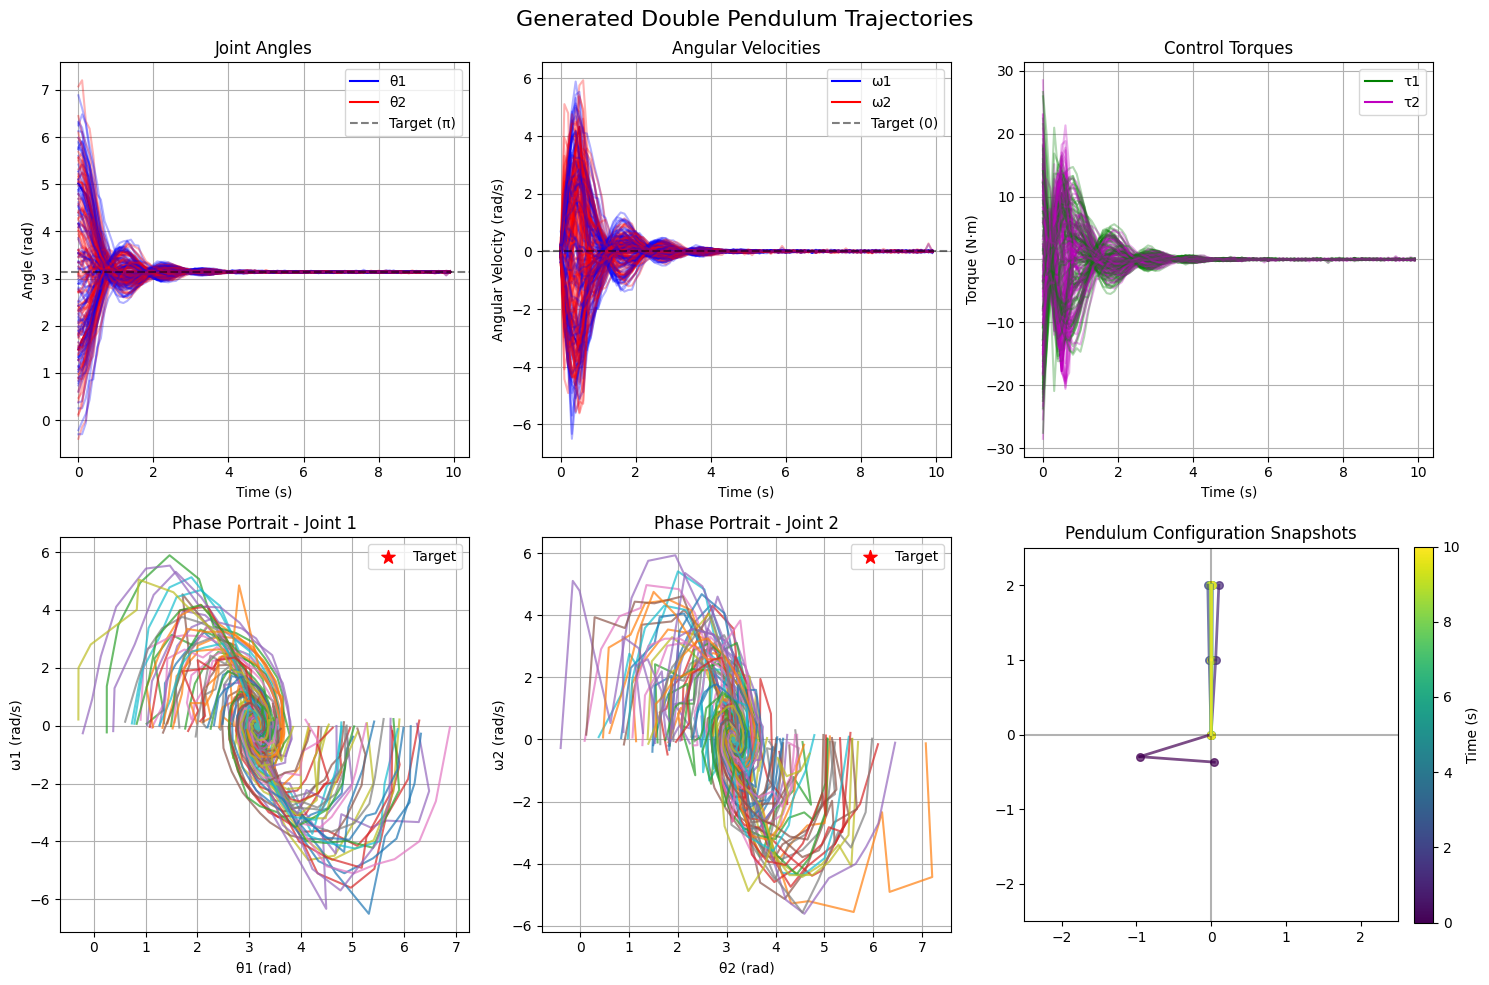

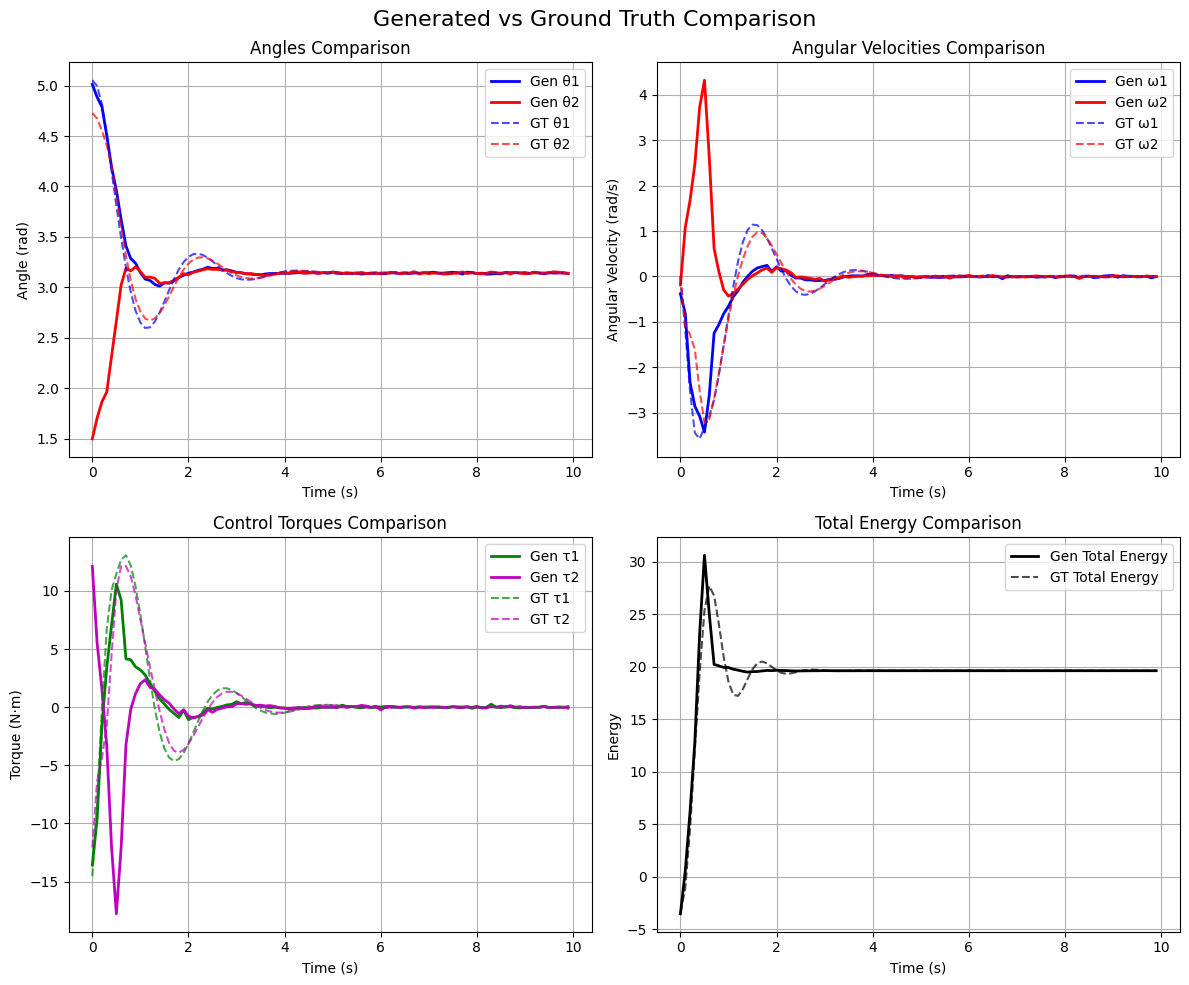


Control Effectiveness Evaluation:
Traj   Gen Final    Sim Final    State RMSE   Gen Inverted Sim Inverted
--------------------------------------------------------------------------------
0      0.0058       0.4729       0.2910       Yes          No          
1      0.0165       0.5420       0.2219       Yes          Yes         
2      0.0108       1.3322       0.4852       Yes          No          
3      0.0151       1.1884       0.4653       Yes          No          
4      0.0074       0.4251       0.2665       Yes          No          
5      0.0099       0.7252       0.5880       Yes          No          
6      0.0117       1.7779       0.5523       Yes          Yes         
7      0.0042       0.3094       0.2811       Yes          No          
8      0.0159       1.5519       0.5599       Yes          No          
9      0.0121       0.6427       0.6060       Yes          No          
10     0.0081       0.5445       0.4496       Yes          No          
11     0.0116       

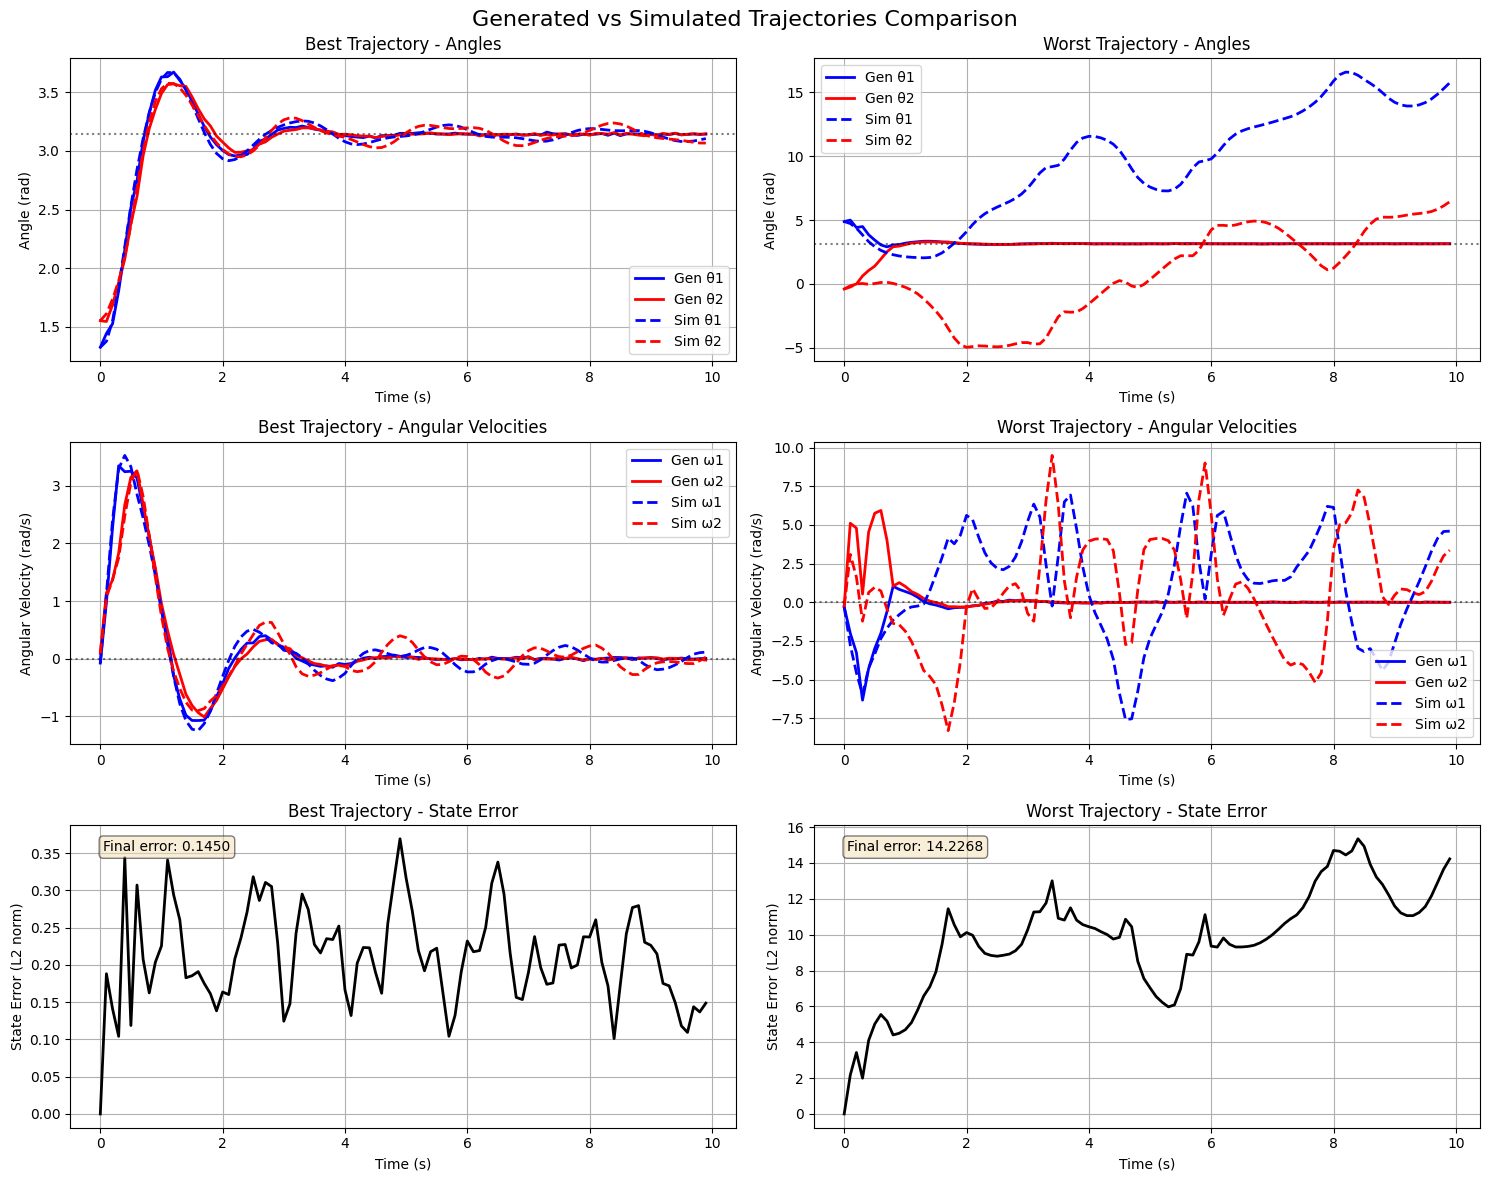


Evaluation completed successfully!


In [11]:
#Dynamic check
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Generated Double Pendulum Trajectories', fontsize=16)

time_steps = np.arange(100) * 0.1

# Select one trajectory for detailed view
traj = generated_trajectories[0]
states = traj['states']
controls = traj['controls']

# Plot 1: Angles over time
ax = axes[0, 0]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['states'][:, 0], 'b-', alpha=alpha, label='θ1' if i == 0 else '')
    ax.plot(time_steps, traj['states'][:, 1], 'r-', alpha=alpha, label='θ2' if i == 0 else '')
ax.axhline(y=np.pi, color='k', linestyle='--', alpha=0.5, label='Target (π)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('Joint Angles')
ax.legend()
ax.grid(True)

# Plot 2: Angular velocities over time
ax = axes[0, 1]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['states'][:, 2], 'b-', alpha=alpha, label='ω1' if i == 0 else '')
    ax.plot(time_steps, traj['states'][:, 3], 'r-', alpha=alpha, label='ω2' if i == 0 else '')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Target (0)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocities')
ax.legend()
ax.grid(True)

# Plot 3: Control torques over time
ax = axes[0, 2]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['controls'][:, 0], 'g-', alpha=alpha, label='τ1' if i == 0 else '')
    ax.plot(time_steps, traj['controls'][:, 1], 'm-', alpha=alpha, label='τ2' if i == 0 else '')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Torques')
ax.legend()
ax.grid(True)

# Plot 4: Phase portrait (θ1 vs ω1)
ax = axes[1, 0]
for traj in generated_trajectories:
    ax.plot(traj['states'][:, 0], traj['states'][:, 2], '-', alpha=0.7)
ax.scatter([np.pi], [0], c='r', s=100, marker='*', label='Target')
ax.set_xlabel('θ1 (rad)')
ax.set_ylabel('ω1 (rad/s)')
ax.set_title('Phase Portrait - Joint 1')
ax.legend()
ax.grid(True)

# Plot 5: Phase portrait (θ2 vs ω2)
ax = axes[1, 1]
for traj in generated_trajectories:
    ax.plot(traj['states'][:, 1], traj['states'][:, 3], '-', alpha=0.7)
ax.scatter([np.pi], [0], c='r', s=100, marker='*', label='Target')
ax.set_xlabel('θ2 (rad)')
ax.set_ylabel('ω2 (rad/s)')
ax.set_title('Phase Portrait - Joint 2')
ax.legend()
ax.grid(True)

# Plot 6: Pendulum snapshots
ax = axes[1, 2]
ax.set_title('Pendulum Configuration Snapshots')
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# Draw pendulum at different time steps
snapshot_indices = np.linspace(0, 99, 10, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshot_indices)))

for idx, color in zip(snapshot_indices, colors):
    θ1, θ2 = states[idx, 0], states[idx, 1]
    x1, y1 = np.sin(θ1), -np.cos(θ1)
    x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
    
    ax.plot([0, x1], [0, y1], color=color, linewidth=2, alpha=0.7)
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=2, alpha=0.7)
    ax.scatter([0, x1, x2], [0, y1, y2], color=color, s=30, alpha=0.7)

# Add colorbar for time
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=10))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Time (s)')

plt.tight_layout()
plt.show()

# %%
# 5. Animate the pendulum motion
def animate_pendulum(states, interval=50):
    """Create animation of the double pendulum motion"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Double Pendulum Animation')
    
    # Initialize pendulum elements
    line1, = ax.plot([], [], 'b-', lw=3, label='Link 1')
    line2, = ax.plot([], [], 'r-', lw=3, label='Link 2')
    points, = ax.plot([], [], 'ko', markersize=8)
    
    # Trajectory traces
    trace1, = ax.plot([], [], 'b-', alpha=0.3, lw=1)
    trace2, = ax.plot([], [], 'r-', alpha=0.3, lw=1)
    
    trace1_x, trace1_y = [], []
    trace2_x, trace2_y = [], []
    
    time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                       verticalalignment='top', fontsize=12)
    
    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        points.set_data([], [])
        trace1.set_data([], [])
        trace2.set_data([], [])
        time_text.set_text('')
        return line1, line2, points, trace1, trace2, time_text
    
    def animate(i):
        θ1, θ2 = states[i, 0], states[i, 1]
        
        # Calculate positions
        x1, y1 = np.sin(θ1), -np.cos(θ1)
        x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
        
        # Update pendulum
        line1.set_data([0, x1], [0, y1])
        line2.set_data([x1, x2], [y1, y2])
        points.set_data([0, x1, x2], [0, y1, y2])
        
        # Update traces
        trace1_x.append(x1)
        trace1_y.append(y1)
        trace2_x.append(x2)
        trace2_y.append(y2)
        
        # Keep only last 50 points for trace
        if len(trace1_x) > 50:
            trace1_x.pop(0)
            trace1_y.pop(0)
            trace2_x.pop(0)
            trace2_y.pop(0)
        
        trace1.set_data(trace1_x, trace1_y)
        trace2.set_data(trace2_x, trace2_y)
        
        # Update time
        time_text.set_text(f'Time: {i*0.1:.1f}s')
        
        return line1, line2, points, trace1, trace2, time_text
    
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                 frames=len(states), interval=interval,
                                 blit=True, repeat=True)
    
    plt.legend()
    plt.close()
    return anim

# Create animation
anim = animate_pendulum(generated_trajectories[0]['states'])
HTML(anim.to_jshtml())

# %%
# 6. Compare with ground truth (if available)
# Load a sample from the original MPC data for comparison
original_data = np.load('mpc_trajectories.npy')
gt_idx = np.random.randint(len(original_data))
gt_traj = original_data[gt_idx]
gt_states = gt_traj[:, :4]
gt_controls = gt_traj[:, 4:]

# Compare with generated trajectory
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Generated vs Ground Truth Comparison', fontsize=16)

# Angles comparison
ax = axes[0, 0]
ax.plot(time_steps, generated_trajectories[0]['states'][:, 0], 'b-', label='Gen θ1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['states'][:, 1], 'r-', label='Gen θ2', linewidth=2)
ax.plot(time_steps, gt_states[:, 0], 'b--', label='GT θ1', alpha=0.7)
ax.plot(time_steps, gt_states[:, 1], 'r--', label='GT θ2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('Angles Comparison')
ax.legend()
ax.grid(True)

# Angular velocities comparison
ax = axes[0, 1]
ax.plot(time_steps, generated_trajectories[0]['states'][:, 2], 'b-', label='Gen ω1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['states'][:, 3], 'r-', label='Gen ω2', linewidth=2)
ax.plot(time_steps, gt_states[:, 2], 'b--', label='GT ω1', alpha=0.7)
ax.plot(time_steps, gt_states[:, 3], 'r--', label='GT ω2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocities Comparison')
ax.legend()
ax.grid(True)

# Control torques comparison
ax = axes[1, 0]
ax.plot(time_steps, generated_trajectories[0]['controls'][:, 0], 'g-', label='Gen τ1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['controls'][:, 1], 'm-', label='Gen τ2', linewidth=2)
ax.plot(time_steps, gt_controls[:, 0], 'g--', label='GT τ1', alpha=0.7)
ax.plot(time_steps, gt_controls[:, 1], 'm--', label='GT τ2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Torques Comparison')
ax.legend()
ax.grid(True)

# Energy analysis
ax = axes[1, 1]
# Calculate total energy for generated trajectory
gen_states = generated_trajectories[0]['states']
gen_kinetic = 0.5 * (gen_states[:, 2]**2 + gen_states[:, 3]**2)
gen_potential = -9.81 * (np.cos(gen_states[:, 0]) + np.cos(gen_states[:, 1]))
gen_total_energy = gen_kinetic + gen_potential

# Calculate total energy for ground truth
gt_kinetic = 0.5 * (gt_states[:, 2]**2 + gt_states[:, 3]**2)
gt_potential = -9.81 * (np.cos(gt_states[:, 0]) + np.cos(gt_states[:, 1]))
gt_total_energy = gt_kinetic + gt_potential

ax.plot(time_steps, gen_total_energy, 'k-', label='Gen Total Energy', linewidth=2)
ax.plot(time_steps, gt_total_energy, 'k--', label='GT Total Energy', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy')
ax.set_title('Total Energy Comparison')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# %%
# 8. Simulate dynamics with generated controls and evaluate performance

# First, let's define the double pendulum dynamics for simulation
class DoublePendulumDynamics:
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g

    def f(self, state, u):
        θ1, θ2, ω1, ω2 = state
        Δ = θ2 - θ1
        M11 = (self.m1 + self.m2) * self.l1**2
        M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
        M21 = M12
        M22 = self.m2 * self.l2**2
        C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
        C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
        G1 = -(self.m1 + self.m2) * self.g * self.l1 * np.sin(θ1)
        G2 = -self.m2 * self.g * self.l2 * np.sin(θ2)
        M = np.array([[M11, M12],[M21, M22]])
        dd = np.linalg.inv(M) @ (u - np.array([C1, C2]) - np.array([G1, G2]))
        return np.array([ω1, ω2, dd[0], dd[1]])

    def rk4_step(self, state, u, dt):
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2*k1, u)
        k3 = self.f(state + dt/2*k2, u)
        k4 = self.f(state + dt*k3, u)
        return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)

# Create dynamics model
dyn = DoublePendulumDynamics()
dt = 0.1

# Simulate each generated trajectory
simulation_results = []

for i, traj in enumerate(generated_trajectories):
    # Get initial state from generated trajectory
    x0 = traj['states'][0, :]  # [θ1, θ2, ω1, ω2]
    controls = traj['controls']  # (100, 2)
    
    # Simulate with the generated controls
    simulated_states = [x0.copy()]
    for t in range(99):  # 99 steps to get 100 states
        u = controls[t]
        x_next = dyn.rk4_step(simulated_states[-1], u, dt)
        simulated_states.append(x_next)
    
    simulated_states = np.array(simulated_states)
    
    # Store results
    simulation_results.append({
        'generated_states': traj['states'],
        'simulated_states': simulated_states,
        'controls': controls,
        'initial_state': x0
    })

# %%
# 9. Evaluate control effectiveness

# Target state
target_state = np.array([np.pi, np.pi, 0.0, 0.0])

# Evaluation metrics
evaluation_metrics = []

for i, result in enumerate(simulation_results):
    gen_states = result['generated_states']
    sim_states = result['simulated_states']
    
    # Final state errors
    gen_final = gen_states[-1]
    sim_final = sim_states[-1]
    
    gen_error = np.linalg.norm(gen_final - target_state)
    sim_error = np.linalg.norm(sim_final - target_state)
    
    # Angle errors at final time
    gen_angle_error = np.sqrt((gen_final[0] - np.pi)**2 + (gen_final[1] - np.pi)**2)
    sim_angle_error = np.sqrt((sim_final[0] - np.pi)**2 + (sim_final[1] - np.pi)**2)
    
    # Velocity errors at final time
    gen_vel_error = np.sqrt(gen_final[2]**2 + gen_final[3]**2)
    sim_vel_error = np.sqrt(sim_final[2]**2 + sim_final[3]**2)
    
    # State trajectory error (RMSE)
    state_rmse = np.sqrt(np.mean((gen_states - sim_states)**2))
    
    # Check if successfully inverted (both angles within 0.1 rad of π)
    gen_inverted = (abs(gen_final[0] - np.pi) < 0.1) and (abs(gen_final[1] - np.pi) < 0.1)
    sim_inverted = (abs(sim_final[0] - np.pi) < 0.1) and (abs(sim_final[1] - np.pi) < 0.1)
    
    # Control effort
    control_effort = np.sqrt(np.mean(result['controls']**2))
    
    metrics = {
        'traj_idx': i,
        'gen_final_error': gen_error,
        'sim_final_error': sim_error,
        'gen_angle_error': gen_angle_error,
        'sim_angle_error': sim_angle_error,
        'gen_vel_error': gen_vel_error,
        'sim_vel_error': sim_vel_error,
        'state_rmse': state_rmse,
        'gen_inverted': gen_inverted,
        'sim_inverted': sim_inverted,
        'control_effort': control_effort
    }
    evaluation_metrics.append(metrics)

# Print evaluation results
print("\nControl Effectiveness Evaluation:")
print("=" * 80)
print(f"{'Traj':<6} {'Gen Final':<12} {'Sim Final':<12} {'State RMSE':<12} {'Gen Inverted':<12} {'Sim Inverted':<12}")
print("-" * 80)

for metrics in evaluation_metrics:
    print(f"{metrics['traj_idx']:<6} "
          f"{metrics['gen_final_error']:<12.4f} "
          f"{metrics['sim_final_error']:<12.4f} "
          f"{metrics['state_rmse']:<12.4f} "
          f"{'Yes' if metrics['gen_inverted'] else 'No':<12} "
          f"{'Yes' if metrics['sim_inverted'] else 'No':<12}")

# Summary statistics
sim_success_rate = sum(m['sim_inverted'] for m in evaluation_metrics) / len(evaluation_metrics)
avg_sim_error = np.mean([m['sim_final_error'] for m in evaluation_metrics])
avg_state_rmse = np.mean([m['state_rmse'] for m in evaluation_metrics])

print("\nSummary:")
print(f"Simulation success rate: {sim_success_rate:.1%}")
print(f"Average final state error (simulation): {avg_sim_error:.4f}")
print(f"Average state trajectory RMSE: {avg_state_rmse:.4f}")

# %%
# 10. Visualize comparison between generated and simulated trajectories

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Generated vs Simulated Trajectories Comparison', fontsize=16)

# Select best and worst trajectories based on simulation error
best_idx = min(range(len(evaluation_metrics)), 
               key=lambda i: evaluation_metrics[i]['sim_final_error'])
worst_idx = max(range(len(evaluation_metrics)), 
                key=lambda i: evaluation_metrics[i]['sim_final_error'])

time_steps = np.arange(100) * dt

for idx, label in [(best_idx, 'Best'), (worst_idx, 'Worst')]:
    result = simulation_results[idx]
    gen_states = result['generated_states']
    sim_states = result['simulated_states']
    controls = result['controls']
    
    col = 0 if label == 'Best' else 1
    
    # Angles
    ax = axes[0, col]
    ax.plot(time_steps, gen_states[:, 0], 'b-', label='Gen θ1', linewidth=2)
    ax.plot(time_steps, gen_states[:, 1], 'r-', label='Gen θ2', linewidth=2)
    ax.plot(time_steps, sim_states[:, 0], 'b--', label='Sim θ1', linewidth=2)
    ax.plot(time_steps, sim_states[:, 1], 'r--', label='Sim θ2', linewidth=2)
    ax.axhline(y=np.pi, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Angle (rad)')
    ax.set_title(f'{label} Trajectory - Angles')
    ax.legend()
    ax.grid(True)
    
    # Angular velocities
    ax = axes[1, col]
    ax.plot(time_steps, gen_states[:, 2], 'b-', label='Gen ω1', linewidth=2)
    ax.plot(time_steps, gen_states[:, 3], 'r-', label='Gen ω2', linewidth=2)
    ax.plot(time_steps, sim_states[:, 2], 'b--', label='Sim ω1', linewidth=2)
    ax.plot(time_steps, sim_states[:, 3], 'r--', label='Sim ω2', linewidth=2)
    ax.axhline(y=0, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Angular Velocity (rad/s)')
    ax.set_title(f'{label} Trajectory - Angular Velocities')
    ax.legend()
    ax.grid(True)
    
    # State error
    ax = axes[2, col]
    state_error = np.linalg.norm(gen_states - sim_states, axis=1)
    ax.plot(time_steps, state_error, 'k-', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('State Error (L2 norm)')
    ax.set_title(f'{label} Trajectory - State Error')
    ax.grid(True)
    
    # Add text with final errors
    final_error = evaluation_metrics[idx]['sim_final_error']
    ax.text(0.05, 0.95, f'Final error: {final_error:.4f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# %%
# 11. Pendulum animation comparison

def animate_comparison(gen_states, sim_states, interval=50):
    """Create side-by-side animation comparing generated and simulated trajectories"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    for ax, title in [(ax1, 'Generated Trajectory'), (ax2, 'Simulated Trajectory')]:
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(title)
    
    # Initialize pendulum elements for both
    elements = []
    for ax in [ax1, ax2]:
        line1, = ax.plot([], [], 'b-', lw=3, label='Link 1')
        line2, = ax.plot([], [], 'r-', lw=3, label='Link 2')
        points, = ax.plot([], [], 'ko', markersize=8)
        trace1, = ax.plot([], [], 'b-', alpha=0.3, lw=1)
        trace2, = ax.plot([], [], 'r-', alpha=0.3, lw=1)
        time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                           verticalalignment='top', fontsize=12)
        elements.append((line1, line2, points, trace1, trace2, time_text, [], [], [], []))
    
    def init():
        for line1, line2, points, trace1, trace2, time_text, *_ in elements:
            line1.set_data([], [])
            line2.set_data([], [])
            points.set_data([], [])
            trace1.set_data([], [])
            trace2.set_data([], [])
            time_text.set_text('')
        return [item for elem in elements for item in elem[:6]]
    
    def animate(i):
        returns = []
        for states, (line1, line2, points, trace1, trace2, time_text, 
                     trace1_x, trace1_y, trace2_x, trace2_y) in zip([gen_states, sim_states], elements):
            θ1, θ2 = states[i, 0], states[i, 1]
            
            # Calculate positions
            x1, y1 = np.sin(θ1), -np.cos(θ1)
            x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
            
            # Update pendulum
            line1.set_data([0, x1], [0, y1])
            line2.set_data([x1, x2], [y1, y2])
            points.set_data([0, x1, x2], [0, y1, y2])
            
            # Update traces
            trace1_x.append(x1)
            trace1_y.append(y1)
            trace2_x.append(x2)
            trace2_y.append(y2)
            
            # Keep only last 30 points
            if len(trace1_x) > 30:
                trace1_x.pop(0)
                trace1_y.pop(0)
                trace2_x.pop(0)
                trace2_y.pop(0)
            
            trace1.set_data(trace1_x, trace1_y)
            trace2.set_data(trace2_x, trace2_y)
            
            # Update time
            time_text.set_text(f'Time: {i*0.1:.1f}s')
            
            returns.extend([line1, line2, points, trace1, trace2, time_text])
        
        return returns
    
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                 frames=len(gen_states), interval=interval,
                                 blit=True, repeat=True)
    
    plt.tight_layout()
    plt.close()
    return anim

# Create comparison animation for the best trajectory
best_result = simulation_results[best_idx]
anim_comparison = animate_comparison(best_result['generated_states'], 
                                   best_result['simulated_states'])
HTML(anim_comparison.to_jshtml())

print("\nEvaluation completed successfully!")


Processing trajectory 1...
  Basic method: 0.102s, avg residual: 0.057977
  Fast method:  0.024s, avg residual: 0.059324
  CVXPY method: 0.086s, avg residual: 0.077997

Processing trajectory 2...
  Basic method: 0.103s, avg residual: 0.050451
  Fast method:  0.024s, avg residual: 0.054995
  CVXPY method: 0.246s, avg residual: 0.081440

Processing trajectory 3...
  Basic method: 0.105s, avg residual: 0.067654
  Fast method:  0.025s, avg residual: 0.069239
  CVXPY method: 0.086s, avg residual: 0.093327

Processing trajectory 4...
  Basic method: 0.104s, avg residual: 0.076021
  Fast method:  0.025s, avg residual: 0.079571
  CVXPY method: 0.089s, avg residual: 0.108977

Processing trajectory 5...
  Basic method: 0.103s, avg residual: 0.042974
  Fast method:  0.025s, avg residual: 0.048856
  CVXPY method: 0.086s, avg residual: 0.069028

Processing trajectory 6...
  Basic method: 0.102s, avg residual: 0.090797
  Fast method:  0.028s, avg residual: 0.092167
  CVXPY method: 0.093s, avg resid

/tmp/ipykernel_747522/2392727933.py:275: RuntimeWarning: overflow encountered in scalar multiply
  C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
/tmp/ipykernel_747522/2392727933.py:275: RuntimeWarning: overflow encountered in scalar power
  C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
/tmp/ipykernel_747522/2392727933.py:275: RuntimeWarning: invalid value encountered in scalar add
  C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
/tmp/ipykernel_747522/2392727933.py:276: RuntimeWarning: overflow encountered in scalar power
  C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
/home/nvidiapc/Flow_ICLR/fmtorch/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:2780: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/tmp/ipykernel_747522/2392727933.py:280: RuntimeWarning: invalid value encountered in matmul
  dd = np.linalg.inv(M) @ (u - np.array([C1, C2]) - np.array([G1, G2]))


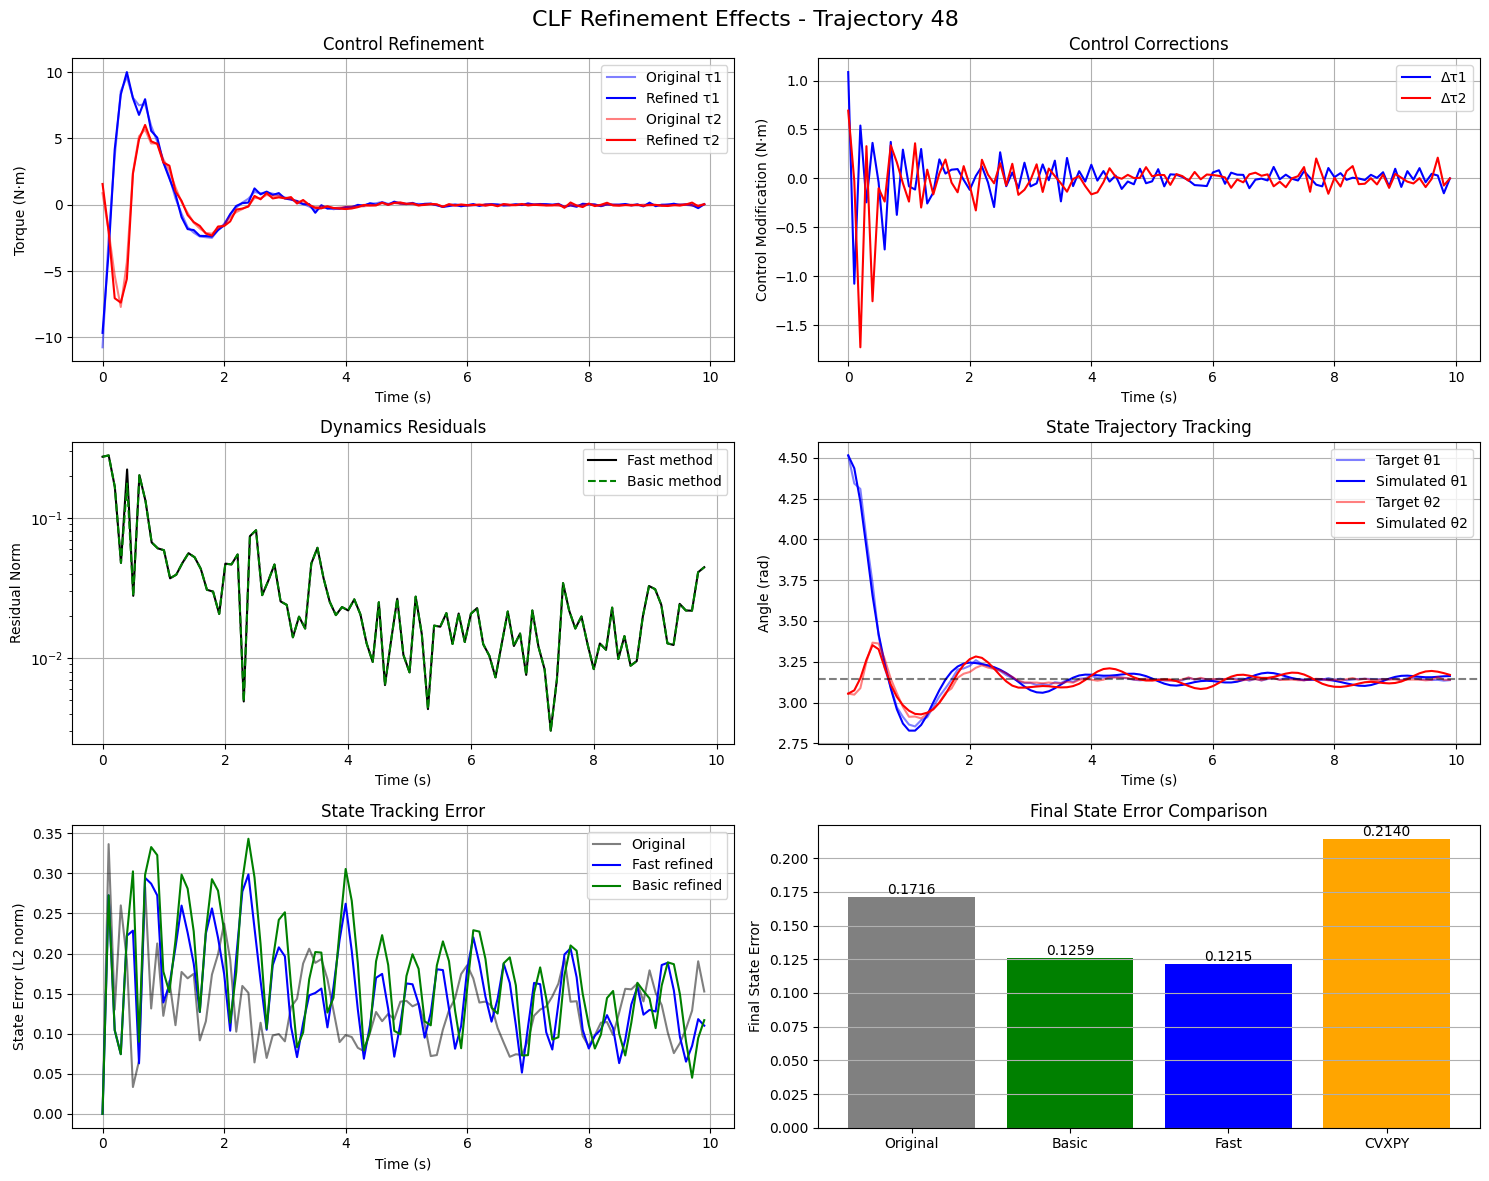


Detailed Timing Analysis

Trajectory 0:
  Basic:  0.102s
  Fast:   0.024s (speedup: 4.2x)
  CVXPY:  0.086s (speedup: 1.2x)

Trajectory 1:
  Basic:  0.103s
  Fast:   0.024s (speedup: 4.2x)
  CVXPY:  0.246s (speedup: 0.4x)

Trajectory 2:
  Basic:  0.105s
  Fast:   0.025s (speedup: 4.3x)
  CVXPY:  0.086s (speedup: 1.2x)

Trajectory 3:
  Basic:  0.104s
  Fast:   0.025s (speedup: 4.3x)
  CVXPY:  0.089s (speedup: 1.2x)

Trajectory 4:
  Basic:  0.103s
  Fast:   0.025s (speedup: 4.2x)
  CVXPY:  0.086s (speedup: 1.2x)

CLF post-processing completed successfully!


In [12]:
# %%
# CLF Post-Processing for FM-Generated Trajectories

import numpy as np
import scipy.optimize as opt
from scipy.optimize import minimize, minimize_scalar
import cvxpy as cp
import time
import matplotlib.pyplot as plt

# %%
# 1. Define CLF-based control refinement

class CLFControlRefinement:
    """
    Control refinement using CLF to minimize dynamics residuals
    """
    def __init__(self, dynamics, dt=0.1):
        self.dyn = dynamics
        self.dt = dt
        
    def dynamics_residual(self, x_current, u, x_next_target):
        """
        Compute residual between simulated next state and target next state
        """
        # Simulate one step
        x_next_sim = self.dyn.rk4_step(x_current, u, self.dt)
        
        # Compute residual
        residual = x_next_sim - x_next_target
        return residual
    
    def refine_controls_basic(self, states, controls, verbose=False):
        """
        Basic version: Use scipy.minimize for each time step
        Prioritizes accuracy over speed
        """
        refined_controls = np.zeros_like(controls)
        residuals = []
        
        for t in range(len(controls) - 1):
            x_current = states[t]
            x_next_target = states[t + 1]
            u_nominal = controls[t]
            
            # Objective: minimize control modification + dynamics residual
            def objective(u):
                # Control modification penalty
                control_cost = np.sum((u - u_nominal)**2)
                
                # Dynamics residual penalty
                residual = self.dynamics_residual(x_current, u, x_next_target)
                residual_cost = 100 * np.sum(residual**2)  # Higher weight on dynamics
                
                return control_cost + residual_cost
            
            # Optimize
            result = minimize(objective, u_nominal, method='L-BFGS-B',
                            bounds=[(-10, 10), (-10, 10)])  # Torque limits
            
            refined_controls[t] = result.x
            residuals.append(self.dynamics_residual(x_current, result.x, x_next_target))
            
            if verbose and t % 20 == 0:
                print(f"Step {t}: residual norm = {np.linalg.norm(residuals[-1]):.6f}")
        
        # Last control remains unchanged
        refined_controls[-1] = controls[-1]
        
        return refined_controls, np.array(residuals)
    
    def refine_controls_fast(self, states, controls):
        """
        Fast version: Use analytical approximation with single Newton step
        """
        refined_controls = np.zeros_like(controls)
        residuals = []
        
        for t in range(len(controls) - 1):
            x_current = states[t]
            x_next_target = states[t + 1]
            u_nominal = controls[t]
            
            # Linearize dynamics around nominal control
            # Compute Jacobian numerically (can be precomputed symbolically for more speed)
            eps = 1e-6
            J = np.zeros((4, 2))  # Jacobian of next state w.r.t control
            
            for i in range(2):
                u_plus = u_nominal.copy()
                u_minus = u_nominal.copy()
                u_plus[i] += eps
                u_minus[i] -= eps
                
                x_plus = self.dyn.rk4_step(x_current, u_plus, self.dt)
                x_minus = self.dyn.rk4_step(x_current, u_minus, self.dt)
                
                J[:, i] = (x_plus - x_minus) / (2 * eps)
            
            # Current residual
            x_next_sim = self.dyn.rk4_step(x_current, u_nominal, self.dt)
            r = x_next_target - x_next_sim
            
            # Solve for control correction using least squares
            # min ||J * du - r||^2 + lambda * ||du||^2
            lambda_reg = 0.01
            A = np.vstack([J, np.sqrt(lambda_reg) * np.eye(2)])
            b = np.vstack([r.reshape(-1, 1), np.zeros((2, 1))])
            
            # Solve using normal equations (closed form)
            du = np.linalg.lstsq(A, b, rcond=None)[0].flatten()
            
            # Apply correction with bounds
            u_refined = u_nominal + du
            u_refined = np.clip(u_refined, -10, 10)  # Torque limits
            
            refined_controls[t] = u_refined
            residuals.append(self.dynamics_residual(x_current, u_refined, x_next_target))
        
        # Last control remains unchanged
        refined_controls[-1] = controls[-1]
        
        return refined_controls, np.array(residuals)
    
    def refine_controls_cvxpy(self, states, controls, verbose=False):
        """
        Alternative fast version using cvxpy for batch optimization
        Optimizes all time steps simultaneously
        """
        T = len(controls) - 1
        
        # Decision variables
        U = cp.Variable((T, 2))
        
        # Objective and constraints
        objective = 0
        constraints = []
        
        for t in range(T):
            # Control modification penalty
            objective += cp.sum_squares(U[t] - controls[t])
            
            # Torque limits
            constraints += [U[t] >= -10, U[t] <= 10]
        
        # Solve
        prob = cp.Problem(cp.Minimize(objective), constraints)
        prob.solve(solver=cp.OSQP, verbose=verbose)
        
        refined_controls = np.vstack([U.value, controls[-1:]])
        
        # Compute residuals
        residuals = []
        for t in range(T):
            residuals.append(self.dynamics_residual(states[t], refined_controls[t], states[t+1]))
        
        return refined_controls, np.array(residuals)

# %%
# 2. Apply CLF refinement to generated trajectories

# Initialize dynamics and CLF refinement
dyn = DoublePendulumDynamics()
clf_refiner = CLFControlRefinement(dyn, dt=0.1)

# Storage for results
refinement_results = []

# Process each generated trajectory
for i, traj in enumerate(generated_trajectories[:100]):  # Process first 5 for demo
    print(f"\nProcessing trajectory {i+1}...")
    
    states = traj['states']
    controls = traj['controls']
    
    # Basic refinement (accurate but slow)
    start_time = time.time()
    controls_basic, residuals_basic = clf_refiner.refine_controls_basic(states, controls)
    time_basic = time.time() - start_time
    
    # Fast refinement
    start_time = time.time()
    controls_fast, residuals_fast = clf_refiner.refine_controls_fast(states, controls)
    time_fast = time.time() - start_time
    
    # CVXPY refinement
    start_time = time.time()
    controls_cvxpy, residuals_cvxpy = clf_refiner.refine_controls_cvxpy(states, controls)
    time_cvxpy = time.time() - start_time
    
    # Store results
    result = {
        'traj_idx': i,
        'original_controls': controls,
        'refined_controls_basic': controls_basic,
        'refined_controls_fast': controls_fast,
        'refined_controls_cvxpy': controls_cvxpy,
        'residuals_basic': residuals_basic,
        'residuals_fast': residuals_fast,
        'residuals_cvxpy': residuals_cvxpy,
        'time_basic': time_basic,
        'time_fast': time_fast,
        'time_cvxpy': time_cvxpy,
        'states': states
    }
    refinement_results.append(result)
    
    print(f"  Basic method: {time_basic:.3f}s, avg residual: {np.mean(np.linalg.norm(residuals_basic, axis=1)):.6f}")
    print(f"  Fast method:  {time_fast:.3f}s, avg residual: {np.mean(np.linalg.norm(residuals_fast, axis=1)):.6f}")
    print(f"  CVXPY method: {time_cvxpy:.3f}s, avg residual: {np.mean(np.linalg.norm(residuals_cvxpy, axis=1)):.6f}")

# %%
# 3. Evaluate refined controls through simulation

def evaluate_refined_controls(states, controls, dyn, dt=0.1):
    """
    Simulate system with refined controls and evaluate performance
    """
    # Simulate
    x0 = states[0]
    simulated_states = [x0]
    
    for t in range(len(controls) - 1):
        x_next = dyn.rk4_step(simulated_states[-1], controls[t], dt)
        simulated_states.append(x_next)
    
    simulated_states = np.array(simulated_states)
    
    # Evaluate final state
    target_state = np.array([np.pi, np.pi, 0.0, 0.0])
    final_error = np.linalg.norm(simulated_states[-1] - target_state)
    
    # Check if inverted
    final_angles = simulated_states[-1, :2]
    inverted = (np.abs(final_angles[0] - np.pi) < 0.1) and (np.abs(final_angles[1] - np.pi) < 0.1)
    
    # State trajectory error
    state_error = np.linalg.norm(simulated_states - states, axis=1)
    
    return {
        'simulated_states': simulated_states,
        'final_error': final_error,
        'inverted': inverted,
        'state_error': state_error,
        'avg_state_error': np.mean(state_error)
    }

# Evaluate all refinement methods
evaluation_results = []

for result in refinement_results:
    eval_result = {'traj_idx': result['traj_idx']}
    
    # Evaluate original controls
    eval_orig = evaluate_refined_controls(result['states'], result['original_controls'], dyn)
    eval_result['original'] = eval_orig
    
    # Evaluate refined controls
    for method in ['basic', 'fast', 'cvxpy']:
        controls_key = f'refined_controls_{method}'
        eval_refined = evaluate_refined_controls(result['states'], result[controls_key], dyn)
        eval_result[method] = eval_refined
    
    evaluation_results.append(eval_result)

# %%
# 4. Summary comparison

print("\n" + "="*80)
print("CLF Refinement Performance Comparison")
print("="*80)
print(f"{'Method':<10} {'Avg Time':<12} {'Avg Residual':<15} {'Success Rate':<15} {'Avg State Error':<15}")
print("-"*80)

# Aggregate statistics
methods = ['original', 'basic', 'fast', 'cvxpy']
stats = {method: {'times': [], 'residuals': [], 'success': [], 'state_errors': []} for method in methods}

for i, result in enumerate(refinement_results):
    eval_result = evaluation_results[i]
    
    # Original doesn't have refinement time or residuals
    stats['original']['times'].append(0)
    stats['original']['residuals'].append(0)
    stats['original']['success'].append(eval_result['original']['inverted'])
    stats['original']['state_errors'].append(eval_result['original']['avg_state_error'])
    
    # Refined methods
    for method in ['basic', 'fast', 'cvxpy']:
        stats[method]['times'].append(result[f'time_{method}'])
        stats[method]['residuals'].append(np.mean(np.linalg.norm(result[f'residuals_{method}'], axis=1)))
        stats[method]['success'].append(eval_result[method]['inverted'])
        stats[method]['state_errors'].append(eval_result[method]['avg_state_error'])

# Print summary
for method in methods:
    avg_time = np.mean(stats[method]['times'])
    avg_residual = np.mean(stats[method]['residuals'])
    success_rate = np.mean(stats[method]['success']) * 100
    avg_state_error = np.mean(stats[method]['state_errors'])
    
    print(f"{method:<10} {avg_time:<12.4f} {avg_residual:<15.6f} {success_rate:<15.1f}% {avg_state_error:<15.6f}")

# %%
# 5. Visualization of refinement effects

# Select best trajectory based on fast method performance
best_idx = min(range(len(refinement_results)), 
               key=lambda i: evaluation_results[i]['fast']['final_error'])

result = refinement_results[best_idx]
eval_result = evaluation_results[best_idx]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(f'CLF Refinement Effects - Trajectory {best_idx}', fontsize=16)

time_steps = np.arange(100) * 0.1

# Plot 1: Control comparison
ax = axes[0, 0]
ax.plot(time_steps, result['original_controls'][:, 0], 'b-', alpha=0.5, label='Original τ1')
ax.plot(time_steps, result['refined_controls_fast'][:, 0], 'b-', label='Refined τ1')
ax.plot(time_steps, result['original_controls'][:, 1], 'r-', alpha=0.5, label='Original τ2')
ax.plot(time_steps, result['refined_controls_fast'][:, 1], 'r-', label='Refined τ2')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Refinement')
ax.legend()
ax.grid(True)

# Plot 2: Control modification
ax = axes[0, 1]
control_diff = result['refined_controls_fast'] - result['original_controls']
ax.plot(time_steps, control_diff[:, 0], 'b-', label='Δτ1')
ax.plot(time_steps, control_diff[:, 1], 'r-', label='Δτ2')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Control Modification (N·m)')
ax.set_title('Control Corrections')
ax.legend()
ax.grid(True)

# Plot 3: Dynamics residuals
ax = axes[1, 0]
residual_norms = np.linalg.norm(result['residuals_fast'], axis=1)
ax.semilogy(time_steps[:-1], residual_norms, 'k-', label='Fast method')
if len(result['residuals_basic']) > 0:
    residual_norms_basic = np.linalg.norm(result['residuals_basic'], axis=1)
    ax.semilogy(time_steps[:-1], residual_norms_basic, 'g--', label='Basic method')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Residual Norm')
ax.set_title('Dynamics Residuals')
ax.legend()
ax.grid(True)

# Plot 4: State trajectories comparison
ax = axes[1, 1]
ax.plot(time_steps, result['states'][:, 0], 'b-', alpha=0.5, label='Target θ1')
ax.plot(time_steps, eval_result['fast']['simulated_states'][:, 0], 'b-', label='Simulated θ1')
ax.plot(time_steps, result['states'][:, 1], 'r-', alpha=0.5, label='Target θ2')
ax.plot(time_steps, eval_result['fast']['simulated_states'][:, 1], 'r-', label='Simulated θ2')
ax.axhline(y=np.pi, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('State Trajectory Tracking')
ax.legend()
ax.grid(True)

# Plot 5: State error over time
ax = axes[2, 0]
ax.plot(time_steps, eval_result['original']['state_error'], 'k-', alpha=0.5, label='Original')
ax.plot(time_steps, eval_result['fast']['state_error'], 'b-', label='Fast refined')
ax.plot(time_steps, eval_result['basic']['state_error'], 'g-', label='Basic refined')
ax.set_xlabel('Time (s)')
ax.set_ylabel('State Error (L2 norm)')
ax.set_title('State Tracking Error')
ax.legend()
ax.grid(True)

# Plot 6: Method comparison bar chart
ax = axes[2, 1]
methods = ['Original', 'Basic', 'Fast', 'CVXPY']
final_errors = [
    eval_result['original']['final_error'],
    eval_result['basic']['final_error'],
    eval_result['fast']['final_error'],
    eval_result['cvxpy']['final_error']
]
colors = ['gray', 'green', 'blue', 'orange']
bars = ax.bar(methods, final_errors, color=colors)
ax.set_ylabel('Final State Error')
ax.set_title('Final State Error Comparison')
ax.grid(True, axis='y')

# Add value labels on bars
for bar, error in zip(bars, final_errors):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{error:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# %%
# 6. Detailed timing analysis

print("\n" + "="*50)
print("Detailed Timing Analysis")
print("="*50)

# Calculate speedup factors
for result in refinement_results[:5]:
    speedup_fast = result['time_basic'] / result['time_fast']
    speedup_cvxpy = result['time_basic'] / result['time_cvxpy']
    
    print(f"\nTrajectory {result['traj_idx']}:")
    print(f"  Basic:  {result['time_basic']:.3f}s")
    print(f"  Fast:   {result['time_fast']:.3f}s (speedup: {speedup_fast:.1f}x)")
    print(f"  CVXPY:  {result['time_cvxpy']:.3f}s (speedup: {speedup_cvxpy:.1f}x)")

print("\nCLF post-processing completed successfully!")

In [13]:
# import numpy as np
# from scipy.optimize import minimize

# def refine_controls_horizon(states_target, u_nominal, dyn, dt,
#                              w_state=1.0, w_ctrl=0.1,
#                              torque_bounds=None):
#     """
#     一次性优化整条轨迹的扭矩，使仿真状态 X_sim 几乎等于 states_target。
#     - states_target: array (T, 4)，第一行为初始状态，后面 T-1 行是目标状态；
#     - u_nominal:      array (T, 2)，FM 原始给出的 100 步控制；
#     dyn:              双摆动力学对象，带 rk4_step 方法
#     dt:               步长
#     w_state:          状态残差权重
#     w_ctrl:           控制改变量权重
#     torque_bounds:    可选，列表长度 2*(T-1) 的上下限；默认自动用 u_nominal 范围±1。
#     """
#     T = states_target.shape[0]
#     n_ctrl = T - 1  # 只对前 T-1 步控制优化
#     # 初始猜测：前 T-1 步都用 u_nominal
#     U0 = u_nominal[:n_ctrl].flatten()

#     # 构造 bounds
#     if torque_bounds is None:
#         τ_min, τ_max = u_nominal.min() - 1, u_nominal.max() + 1
#         bounds = [(τ_min, τ_max)] * (2 * n_ctrl)
#     else:
#         bounds = torque_bounds

#     def cost(U_flat):
#         U = U_flat.reshape(n_ctrl, 2)
#         x = states_target[0].copy()  # 初始状态
#         J = 0.0
#         for t in range(n_ctrl):
#             u = U[t]
#             # RK4 一步
#             x = dyn.rk4_step(x, u, dt)
#             # 状态残差：对齐到 states_target[t+1]
#             dx = x - states_target[t+1]
#             J += w_state * np.sum(dx*dx)
#             # 控制改变量
#             du = u - u_nominal[t]
#             J += w_ctrl  * np.sum(du*du)
#         return J

#     res = minimize(cost, U0, method='L-BFGS-B',
#                    bounds=bounds,
#                    options={'maxiter':500, 'ftol':1e-9})
#     U_opt = res.x.reshape(n_ctrl, 2)
#     # 把最后一步控制续用原始值，凑回 T 步
#     U_full = np.vstack([U_opt, u_nominal[-1]])
#     return U_full, res

# # —— 用法示例 —— 
# traj0 = generated_trajectories[0]
# states_FM  = traj0['states']       # (100, 4)
# u_FM       = traj0['controls']     # (100, 2)
# dyn = DoublePendulumDynamics()

# U_refined, result = refine_controls_horizon(
#     states_target=states_FM,
#     u_nominal=u_FM,
#     dyn=dyn,
#     dt=0.1,
#     w_state=1.0,   # 强烈追踪状态
#     w_ctrl=0.01    # 允许大幅度调整
# )

# print("优化结束，最终代价：", result.fun)


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np


class TorchDoublePendulumDynamics(nn.Module):
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81, reg=1e-6):
        super().__init__()
        self.m1, self.m2, self.l1, self.l2, self.g = m1, m2, l1, l2, g
        self.reg = reg  # 对角线正则化

    def f(self, state, u):
        device = state.device
        # 把标量转 Tensor
        m1 = torch.tensor(self.m1, device=device)
        m2 = torch.tensor(self.m2, device=device)
        l1 = torch.tensor(self.l1, device=device)
        l2 = torch.tensor(self.l2, device=device)
        g  = torch.tensor(self.g,  device=device)
        
        θ1, θ2, ω1, ω2 = state[...,0], state[...,1], state[...,2], state[...,3]
        Δ = θ2 - θ1
        
        M11 = (m1 + m2) * l1**2
        M12 = m2 * l1 * l2 * torch.cos(Δ)
        M22 = m2 * l2**2
        
        C1 = -m2 * l1 * l2 * (2*ω1*ω2 + ω2**2) * torch.sin(Δ)
        C2 =  m2 * l1 * l2 *     ω1**2   * torch.sin(Δ)
        G1 = -(m1 + m2) * g * l1 * torch.sin(θ1)
        G2 = - m2            * g * l2 * torch.sin(θ2)
        
        # # 质量矩阵和 CG 合力
        # M = torch.stack([
        #     torch.stack([M11, M12], dim=-1),
        #     torch.stack([M12, M22], dim=-1),
        # ], dim=-2)  # (...,2,2)
        # CG = torch.stack([C1+G1, C2+G2], dim=-1)  # (...,2)
        
        # # 对角线加小量
        # I = torch.eye(2, device=device).expand_as(M)
        # M_reg = M + self.reg * I
        
        # # 求解加速矩阵方程
        # dd = torch.linalg.solve(M_reg, u - CG)
        # return torch.stack([ω1, ω2, dd[...,0], dd[...,1]], dim=-1)
        M = torch.stack([
            torch.stack([M11, M12], dim=-1),
            torch.stack([M12, M22], dim=-1),
        ], dim=-2)  # (...,2,2)
        CG = torch.stack([C1+G1, C2+G2], dim=-1)  # (...,2)

        # 对角线加正则
        I = torch.eye(2, device=device).expand_as(M)
        M_reg = M + self.reg * I

        # 用 pseudo-inverse 代替 solve
        # 先把 (u-CG) 从 (...,2) 变成 (...,2,1)，乘后再 squeeze 回 (...,2)
        dd = torch.matmul(torch.linalg.pinv(M_reg), (u - CG).unsqueeze(-1)).squeeze(-1)

        return torch.stack([ω1, ω2, dd[...,0], dd[...,1]], dim=-1)

    def rk4_step(self, state, u, dt):
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2 * k1, u)
        k3 = self.f(state + dt/2 * k2, u)
        k4 = self.f(state + dt    * k3, u)
        return state + dt/6 * (k1 + 2*k2 + 2*k3 + k4)


# 2) 批量优化函数
def refine_with_torch(states_target, u_nominal, dyn, dt,
                      w_state=1.0, w_ctrl=0.01, lr=1e-2,
                      n_iters=200, device='cpu'):
    T = states_target.shape[0]
    n_ctrl = T - 1

    # 转成 tensor
    states_t = torch.tensor(states_target, dtype=torch.float32, device=device)
    u_nom_t = torch.tensor(u_nominal[:n_ctrl], dtype=torch.float32, device=device)

    # 待优化变量：前 T-1 步扭矩
    U = nn.Parameter(u_nom_t.clone())
    optimizer = optim.Adam([U], lr=lr)

    for it in range(n_iters):
        optimizer.zero_grad()
        x = states_t[0]
        loss = 0.0
        for t in range(n_ctrl):
            u = U[t]
            x = dyn.rk4_step(x, u, dt)                    # RK4 一步
            dx = x - states_t[t+1]                       # 状态残差
            loss = loss + w_state*(dx**2).sum() \
                        + w_ctrl*((u - u_nom_t[t])**2).sum()
        loss.backward()
        optimizer.step()
        if (it+1) % 50 == 0 or it == n_iters-1:
            print(f"Iter {it+1}/{n_iters}, loss={loss.item():.6f}")

    # 最后一步复用原始
    U_full = torch.cat([U.detach(), u_nom_t[-1:].detach()], dim=0)
    return U_full.cpu().numpy()

# —— 用法 —— 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dyn_torch = TorchDoublePendulumDynamics().to(device)

traj0 = generated_trajectories[0]
states_FM = traj0['states']    # (T,4)
u_FM      = traj0['controls']  # (T,2)

U_refined = refine_with_torch(
    states_target=states_FM,
    u_nominal=u_FM,
    dyn=dyn_torch,
    dt=0.1,
    w_state=1.0,
    w_ctrl=0.01,
    lr=1e-2,
    n_iters=2,
    device=device
)

print("Torch 加速优化完成，得到 U_refined。")


Iter 2/2, loss=30.736044
Torch 加速优化完成，得到 U_refined。


In [14]:
import numpy as np

# 假设你已经有：
# states_FM: (T,4)  —— FM 给出的目标状态序列
# U_refined: (T,2)  —— 优化后得到的完整扭矩序列
# dyn:       双摆动力学对象，带 rk4_step 方法
# dt:        步长，比如 0.1
tol = 0.1

# 1. 仿真
x = states_FM[0].copy()    # 初始状态
for u in U_refined:
    x = dyn.rk4_step(x, u, dt)

# 2. 最终角度
θ1_final, θ2_final = x[0], x[1]
print(f"优化后仿真最后一帧：θ1={θ1_final:.4f}, θ2={θ2_final:.4f}")

# 3. 判定倒立
if abs(θ1_final - np.pi) < tol and abs(θ2_final - np.pi) < tol:
    print("✅ 成功倒立！")
else:
    print("❌ 未能倒立，请调整优化权重或增加迭代次数。")



#         Iterations	Success Rate
# 0	        1	        0.31
# 1	        2	        0.38
# 2	        5	        0.49
# 3	        10	        0.43
# 4	        20	        0.60
# 5	        50	        0.87
# 6	        100	        0.94



优化后仿真最后一帧：θ1=3.2418, θ2=3.3061
❌ 未能倒立，请调整优化权重或增加迭代次数。


原始轨迹 0:
  状态形状: (100, 4)
  控制形状: (100, 2)
  原始轨迹CBF违反次数: 3/100
  末端执行器x位置范围: [-0.388, 0.232]
优化问题维度:
  状态变量: 396 (99 步 × 4 维)
  控制变量: 198 (99 步 × 2 维)
  总变量数: 594
  障碍位置: x_min = -0.2

开始CBF-CLF联合优化...


/home/nvidiapc/Flow_ICLR/fmtorch/.venv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Iteration limit reached    (Exit mode 9)
            Current function value: 29.00226486640983
            Iterations: 10
            Function evaluations: 5977
            Gradient evaluations: 10

优化完成，耗时: 27.84秒
优化状态: Iteration limit reached
最终目标函数值: 29.002265
约束满足情况: False

约束验证:
  CBF约束违反次数: 0/100
  最小CBF值: 0.023791

优化结果:
  优化成功: False
  CBF约束违反: 0 次
  最小CBF值: 0.023791

动力学一致性验证:
  平均状态跟踪误差: 0.579941
  最终状态误差: 0.574149
  最终角度: θ1=3.2997, θ2=3.2381

障碍避开效果:
  修正前CBF违反: 3/100
  修正后CBF违反: 0/100
  修正后x范围: [-0.126, 0.266]


/tmp/ipykernel_747522/3035336356.py:378: UserWarning: Glyph 26411 (\N{CJK UNIFIED IDEOGRAPH-672B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_747522/3035336356.py:378: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_747522/3035336356.py:378: UserWarning: Glyph 25191 (\N{CJK UNIFIED IDEOGRAPH-6267}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_747522/3035336356.py:378: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_747522/3035336356.py:378: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_747522/3035336356.py:378: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_747522/3035336356.py:378: UserWarning: Glyph 36857 (\N{CJK UN

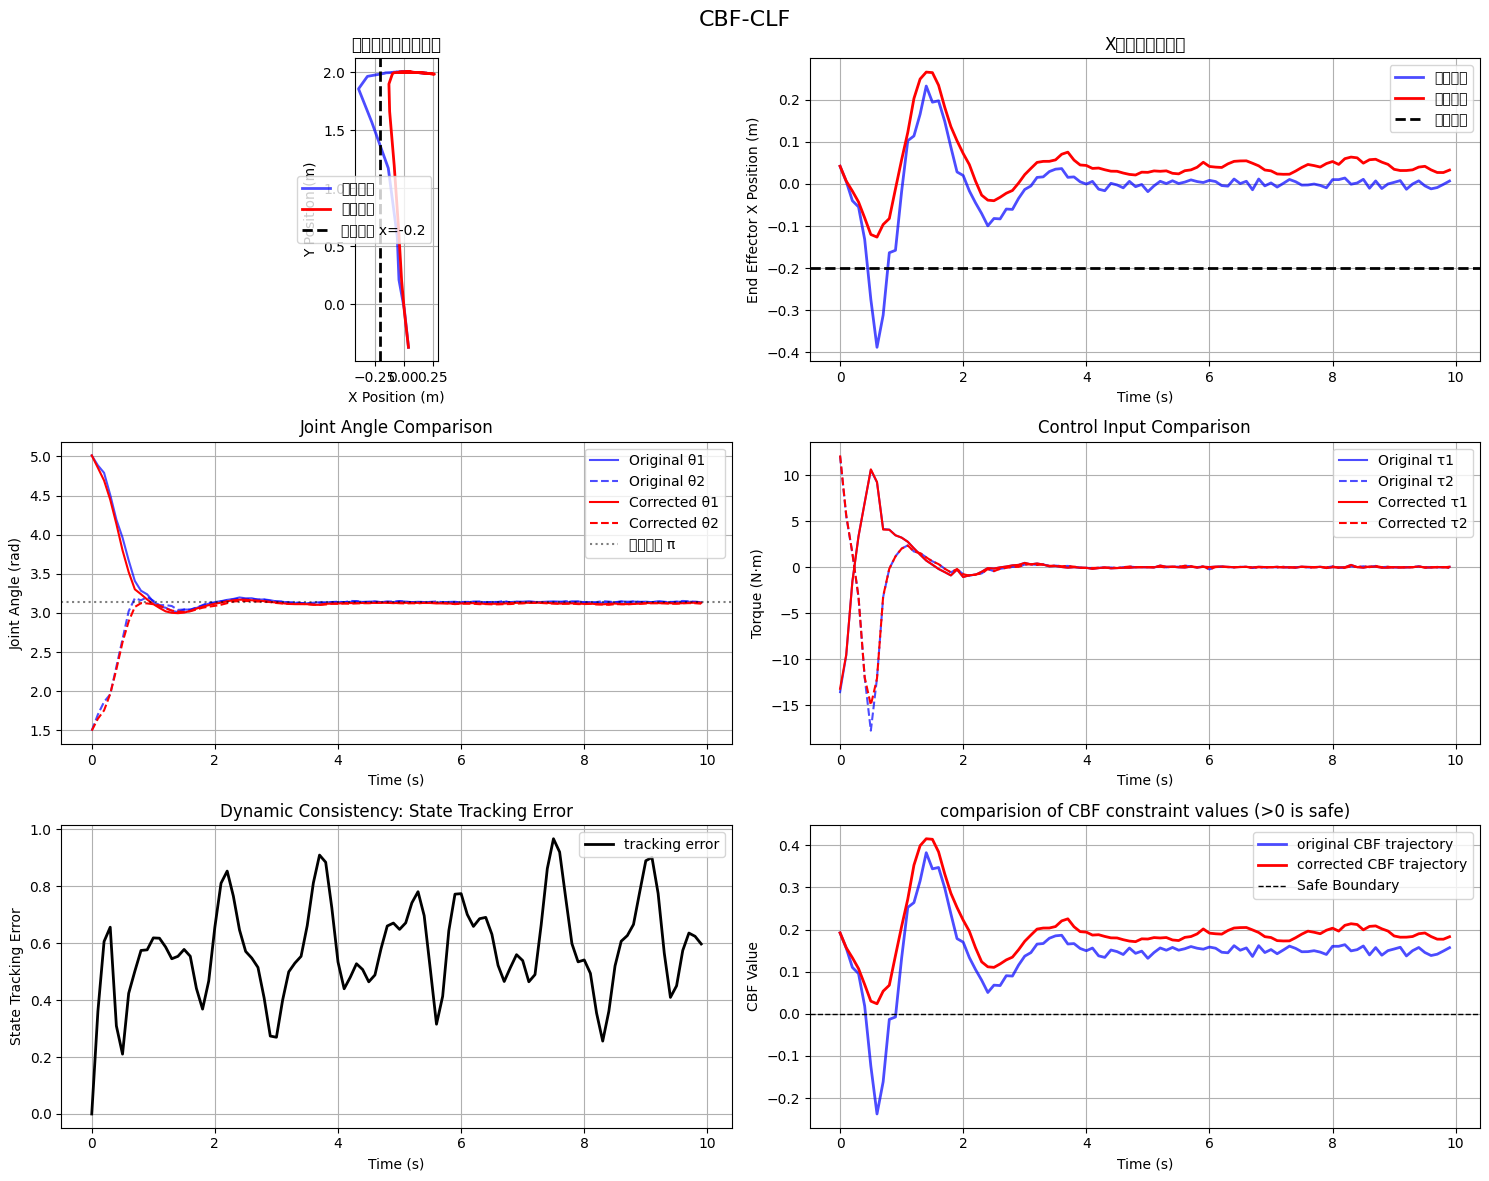

CBF-CLF联合优化完成！


In [23]:
# %%
# CBF-CLF联合优化：同时修正轨迹和控制以避免障碍碰撞并保持动力学一致性

import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import time

class CBF_CLF_JointOptimizer:
    """
    联合CBF-CLF优化器，同时修正状态轨迹和控制序列
    - CBF: 确保末端执行器避开障碍区域
    - CLF: 确保动力学一致性
    """
    
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
    
    def forward_kinematics(self, state):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def cbf_constraint(self, state, x_min, margin=0.05):
        """
        CBF约束：末端执行器x位置必须大于x_min + margin
        返回约束值，>0表示满足约束
        """
        end_pos = self.forward_kinematics(state)
        return end_pos[0] - (x_min + margin)
    
    def optimize_trajectory(self, states_original, controls_original, 
                          x_min=0.2, w_state=1.0, w_ctrl=0.1, w_dynamics=100.0,
                          w_cbf_penalty=1000.0, max_iter=500, verbose=True):
        """
        联合优化状态轨迹和控制序列
        
        参数:
        - states_original: (T, 4) 原始状态轨迹
        - controls_original: (T, 2) 原始控制序列  
        - x_min: float, 障碍位置（末端执行器x坐标的最小值）
        - w_state: float, 状态修正权重
        - w_ctrl: float, 控制修正权重
        - w_dynamics: float, 动力学一致性权重
        - w_cbf_penalty: float, CBF约束惩罚权重
        - max_iter: int, 最大迭代次数
        - verbose: bool, 是否打印优化过程
        
        返回:
        - states_corrected: (T, 4) 修正后的状态轨迹
        - controls_corrected: (T, 2) 修正后的控制序列
        - optimization_result: 优化结果信息
        """
        
        T = len(states_original)
        n_ctrl = T - 1  # 控制序列比状态序列少一步
        
        # 初始猜测：展平为一维向量
        # 顺序：[states[1:T], controls[0:T-1]]  # states[0]保持不变
        x0_states = states_original[1:].flatten()  # (T-1)*4
        x0_controls = controls_original[:n_ctrl].flatten()  # (T-1)*2
        x0 = np.concatenate([x0_states, x0_controls])
        
        # 维度检查
        n_states_var = (T-1) * 4
        n_controls_var = n_ctrl * 2
        total_vars = n_states_var + n_controls_var
        
        if verbose:
            print(f"优化问题维度:")
            print(f"  状态变量: {n_states_var} ({T-1} 步 × 4 维)")
            print(f"  控制变量: {n_controls_var} ({n_ctrl} 步 × 2 维)")
            print(f"  总变量数: {total_vars}")
            print(f"  障碍位置: x_min = {x_min}")
        
        def objective(x):
            """目标函数：状态修正 + 控制修正 + 动力学一致性 + CBF惩罚"""
            
            # 解包变量
            states_var = x[:n_states_var].reshape(T-1, 4)
            controls_var = x[n_states_var:].reshape(n_ctrl, 2)
            
            # 重构完整状态序列（保持初始状态不变）
            states_full = np.vstack([states_original[0:1], states_var])
            controls_full = np.vstack([controls_var, controls_original[-1:]])  # 最后一步控制保持不变
            
            cost = 0.0
            
            # 1. 状态修正正则化（只对修正的状态）
            state_diff = states_var - states_original[1:]
            cost += w_state * np.sum(state_diff**2)
            
            # 2. 控制修正正则化
            ctrl_diff = controls_var - controls_original[:n_ctrl]
            cost += w_ctrl * np.sum(ctrl_diff**2)
            
            # 3. 动力学一致性
            for t in range(n_ctrl):
                x_current = states_full[t]
                u_current = controls_var[t]
                x_next_target = states_full[t+1]
                
                # 用RK4预测下一步状态
                x_next_pred = self.dyn.rk4_step(x_current, u_current, self.dt)
                
                # 动力学残差
                dynamics_error = x_next_pred - x_next_target
                cost += w_dynamics * np.sum(dynamics_error**2)
            
            # 4. CBF惩罚项（软约束）
            for t in range(T):
                cbf_value = self.cbf_constraint(states_full[t], x_min)
                if cbf_value < 0:  # 违反约束时增加惩罚
                    cost += w_cbf_penalty * cbf_value**2
            
            return cost
        
        def constraint_cbf(x):
            """CBF约束：所有时刻末端执行器位置必须满足安全要求"""
            states_var = x[:n_states_var].reshape(T-1, 4)
            states_full = np.vstack([states_original[0:1], states_var])
            
            constraints = []
            for t in range(T):
                cbf_value = self.cbf_constraint(states_full[t], x_min)
                constraints.append(cbf_value)
            
            return np.array(constraints)
        
        # 设置约束
        constraints = [
            {'type': 'ineq', 'fun': constraint_cbf}
        ]
        
        # 设置边界（合理的物理范围）
        bounds = []
        
        # 状态边界：角度[-2π, 2π]，角速度[-20, 20] 
        for _ in range(T-1):
            bounds.extend([(-2*np.pi, 2*np.pi), (-2*np.pi, 2*np.pi), 
                          (-20, 20), (-20, 20)])
        
        # 控制边界：扭矩[-15, 15]
        for _ in range(n_ctrl):
            bounds.extend([(-15, 15), (-15, 15)])
        
        # 开始优化
        if verbose:
            print("\n开始CBF-CLF联合优化...")
            start_time = time.time()
        
        # 使用SLSQP方法进行约束优化
        result = opt.minimize(
            objective, x0, 
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={
                'maxiter': max_iter,
                'ftol': 1e-9,
                'disp': verbose
            }
        )
        
        if verbose:
            end_time = time.time()
            print(f"\n优化完成，耗时: {end_time - start_time:.2f}秒")
            print(f"优化状态: {result.message}")
            print(f"最终目标函数值: {result.fun:.6f}")
            print(f"约束满足情况: {result.success}")
        
        # 解包优化结果
        x_opt = result.x
        states_var_opt = x_opt[:n_states_var].reshape(T-1, 4)
        controls_var_opt = x_opt[n_states_var:].reshape(n_ctrl, 2)
        
        # 重构完整序列
        states_corrected = np.vstack([states_original[0:1], states_var_opt])
        controls_corrected = np.vstack([controls_var_opt, controls_original[-1:]])
        
        # 验证CBF约束
        cbf_violations = 0
        min_cbf_value = float('inf')
        for t in range(T):
            cbf_val = self.cbf_constraint(states_corrected[t], x_min)
            min_cbf_value = min(min_cbf_value, cbf_val)
            if cbf_val < 0:
                cbf_violations += 1
        
        if verbose:
            print(f"\n约束验证:")
            print(f"  CBF约束违反次数: {cbf_violations}/{T}")
            print(f"  最小CBF值: {min_cbf_value:.6f}")
            
        # 返回结果
        optimization_info = {
            'success': result.success,
            'fun': result.fun,
            'message': result.message,
            'cbf_violations': cbf_violations,
            'min_cbf_value': min_cbf_value,
            'optimization_time': end_time - start_time if verbose else None
        }
        
        return states_corrected, controls_corrected, optimization_info


# %%
# 使用示例：对生成的轨迹进行CBF-CLF联合优化

# 初始化优化器
dyn = DoublePendulumDynamics()
optimizer = CBF_CLF_JointOptimizer(dyn, dt=0.1)

# 选择一个生成的轨迹进行优化
traj_idx = 0
original_states = generated_trajectories[traj_idx]['states']
original_controls = generated_trajectories[traj_idx]['controls']

print(f"原始轨迹 {traj_idx}:")
print(f"  状态形状: {original_states.shape}")
print(f"  控制形状: {original_controls.shape}")

# 检查原始轨迹的末端执行器位置
end_positions = []
for t in range(len(original_states)):
    end_pos = optimizer.forward_kinematics(original_states[t])
    end_positions.append(end_pos)
end_positions = np.array(end_positions)

x_min_threshold = -0.2
violations_original = np.sum(end_positions[:, 0] < x_min_threshold)
print(f"  原始轨迹CBF违反次数: {violations_original}/{len(original_states)}")
print(f"  末端执行器x位置范围: [{end_positions[:, 0].min():.3f}, {end_positions[:, 0].max():.3f}]")

# 执行CBF-CLF联合优化
states_corrected, controls_corrected, opt_info = optimizer.optimize_trajectory(
    states_original=original_states,
    controls_original=original_controls,
    x_min=x_min_threshold,
    w_state=1.0,      # 状态修正权重
    w_ctrl=0.1,       # 控制修正权重  
    w_dynamics=100.0, # 动力学一致性权重
    w_cbf_penalty=1000.0,  # CBF惩罚权重
    max_iter=10,
    verbose=True
)

print(f"\n优化结果:")
print(f"  优化成功: {opt_info['success']}")
print(f"  CBF约束违反: {opt_info['cbf_violations']} 次")
print(f"  最小CBF值: {opt_info['min_cbf_value']:.6f}")


# %%
# 验证优化后的轨迹

# 1. 计算优化后的末端执行器轨迹
end_positions_corrected = []
for t in range(len(states_corrected)):
    end_pos = optimizer.forward_kinematics(states_corrected[t])
    end_positions_corrected.append(end_pos)
end_positions_corrected = np.array(end_positions_corrected)

# 2. 仿真验证动力学一致性
simulated_states = [states_corrected[0].copy()]
for t in range(len(controls_corrected) - 1):
    x_next = dyn.rk4_step(simulated_states[-1], controls_corrected[t], 0.1)
    simulated_states.append(x_next)
simulated_states = np.array(simulated_states)

# 3. 计算各种误差指标
state_tracking_error = np.linalg.norm(simulated_states - states_corrected, axis=1)
final_state_error = np.linalg.norm(simulated_states[-1] - np.array([np.pi, np.pi, 0.0, 0.0]))
avg_tracking_error = np.mean(state_tracking_error)

print(f"\n动力学一致性验证:")
print(f"  平均状态跟踪误差: {avg_tracking_error:.6f}")
print(f"  最终状态误差: {final_state_error:.6f}")
print(f"  最终角度: θ1={simulated_states[-1, 0]:.4f}, θ2={simulated_states[-1, 1]:.4f}")

# 4. CBF约束检查
violations_corrected = np.sum(end_positions_corrected[:, 0] < x_min_threshold)
print(f"\n障碍避开效果:")
print(f"  修正前CBF违反: {violations_original}/{len(original_states)}")
print(f"  修正后CBF违反: {violations_corrected}/{len(states_corrected)}")
print(f"  修正后x范围: [{end_positions_corrected[:, 0].min():.3f}, {end_positions_corrected[:, 0].max():.3f}]")


# %%
# 可视化对比结果

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('CBF-CLF', fontsize=16)

time_steps = np.arange(len(original_states)) * 0.1

# 1. 末端执行器轨迹对比
ax = axes[0, 0]
ax.plot(end_positions[:, 0], end_positions[:, 1], 'b-', linewidth=2, alpha=0.7, label='原始轨迹')
ax.plot(end_positions_corrected[:, 0], end_positions_corrected[:, 1], 'r-', linewidth=2, label='修正轨迹')
ax.axvline(x=x_min_threshold, color='k', linestyle='--', linewidth=2, label=f'障碍边界 x={x_min_threshold}')
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('末端执行器轨迹对比')
ax.legend()
ax.grid(True)
ax.set_aspect('equal')

# 2. X位置随时间变化
ax = axes[0, 1]
ax.plot(time_steps, end_positions[:, 0], 'b-', linewidth=2, alpha=0.7, label='原始轨迹')
ax.plot(time_steps, end_positions_corrected[:, 0], 'r-', linewidth=2, label='修正轨迹')
ax.axhline(y=x_min_threshold, color='k', linestyle='--', linewidth=2, label=f'安全边界')
ax.set_xlabel('Time (s)')
ax.set_ylabel('End Effector X Position (m)')
ax.set_title('X位置随时间变化')
ax.legend()
ax.grid(True)

# 3. 关节角度对比
ax = axes[1, 0]
ax.plot(time_steps, original_states[:, 0], 'b-', alpha=0.7, label='Original θ1')
ax.plot(time_steps, original_states[:, 1], 'b--', alpha=0.7, label='Original θ2')
ax.plot(time_steps, states_corrected[:, 0], 'r-', label='Corrected θ1')
ax.plot(time_steps, states_corrected[:, 1], 'r--', label='Corrected θ2')
ax.axhline(y=np.pi, color='k', linestyle=':', alpha=0.5, label='目标角度 π')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Joint Angle (rad)')
ax.set_title('Joint Angle Comparison')
ax.legend()
ax.grid(True)

# 4. 控制输入对比
ax = axes[1, 1]
ax.plot(time_steps, original_controls[:, 0], 'b-', alpha=0.7, label='Original τ1')
ax.plot(time_steps, original_controls[:, 1], 'b--', alpha=0.7, label='Original τ2')
ax.plot(time_steps, controls_corrected[:, 0], 'r-', label='Corrected τ1')
ax.plot(time_steps, controls_corrected[:, 1], 'r--', label='Corrected τ2')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Input Comparison')
ax.legend()
ax.grid(True)

# 5. 状态跟踪误差
ax = axes[2, 0]
ax.plot(time_steps, state_tracking_error, 'k-', linewidth=2, label='tracking error')
ax.set_xlabel('Time (s)')
ax.set_ylabel('State Tracking Error')
ax.set_title('Dynamic Consistency: State Tracking Error')
ax.legend()
ax.grid(True)

# 6. CBF约束值
ax = axes[2, 1]
cbf_values_original = [optimizer.cbf_constraint(original_states[t], x_min_threshold) for t in range(len(original_states))]
cbf_values_corrected = [optimizer.cbf_constraint(states_corrected[t], x_min_threshold) for t in range(len(states_corrected))]


ax.plot(time_steps, cbf_values_original, 'b-', alpha=0.7, linewidth=2, label='original CBF trajectory')
ax.plot(time_steps, cbf_values_corrected, 'r-', linewidth=2, label='corrected CBF trajectory')
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, label='Safe Boundary')

ax.set_xlabel('Time (s)')
ax.set_ylabel('CBF Value')
ax.set_title('comparision of CBF constraint values (>0 is safe)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print("CBF-CLF联合优化完成！")

In [ ]:
# %%
# 批量CBF-CLF联合优化：对70个生成轨迹进行障碍避开和动力学一致性修正

import numpy as np
import time
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

# %%
# 批量优化设置和执行

def batch_cbf_clf_optimization(trajectories, n_trajs=70, x_min=-0.2, 
                              w_state=1.0, w_ctrl=0.1, w_dynamics=100.0, 
                              w_cbf_penalty=1000.0, max_iter=300, verbose_individual=False):
    """
    对多个轨迹进行批量CBF-CLF联合优化
    
    参数:
    - trajectories: 原始轨迹列表
    - n_trajs: 要处理的轨迹数量
    - 其他参数同CBF_CLF_JointOptimizer.optimize_trajectory
    
    返回:
    - cbf_clf_corrected_data: 包含所有修正结果的字典
    """
    
    # 初始化优化器
    dyn = DoublePendulumDynamics()
    optimizer = CBF_CLF_JointOptimizer(dyn, dt=0.1)
    
    # 存储结果
    cbf_clf_corrected_data = {
        'original_states': [],
        'original_controls': [],
        'corrected_states': [],
        'corrected_controls': [],
        'optimization_info': [],
        'cbf_violations_before': [],
        'cbf_violations_after': [],
        'dynamics_consistency_error': [],
        'final_state_error': [],
        'processing_time': []
    }
    
    # 统计变量
    total_success = 0
    total_cbf_violations_before = 0
    total_cbf_violations_after = 0
    total_optimization_time = 0
    
    print(f"开始批量CBF-CLF优化，共处理 {n_trajs} 个轨迹...")
    print(f"优化参数: x_min={x_min}, w_state={w_state}, w_ctrl={w_ctrl}")
    print(f"         w_dynamics={w_dynamics}, w_cbf_penalty={w_cbf_penalty}")
    print("="*70)
    
    # 使用tqdm显示进度条
    for i in tqdm(range(n_trajs), desc="优化进度"):
        traj_start_time = time.time()
        
        # 获取原始轨迹
        original_states = trajectories[i]['states']
        original_controls = trajectories[i]['controls']
        
        # 检查原始轨迹的CBF违反情况
        violations_before = 0
        for t in range(len(original_states)):
            cbf_val = optimizer.cbf_constraint(original_states[t], x_min)
            if cbf_val < 0:
                violations_before += 1
        
        try:
            # 执行CBF-CLF优化
            corrected_states, corrected_controls, opt_info = optimizer.optimize_trajectory(
                states_original=original_states,
                controls_original=original_controls,
                x_min=x_min,
                w_state=w_state,
                w_ctrl=w_ctrl,
                w_dynamics=w_dynamics,
                w_cbf_penalty=w_cbf_penalty,
                max_iter=max_iter,
                verbose=verbose_individual
            )
            
            # 仿真验证动力学一致性
            simulated_states = [corrected_states[0].copy()]
            for t in range(len(corrected_controls) - 1):
                x_next = dyn.rk4_step(simulated_states[-1], corrected_controls[t], 0.1)
                simulated_states.append(x_next)
            simulated_states = np.array(simulated_states)
            
            # 计算动力学一致性误差
            dynamics_error = np.mean(np.linalg.norm(simulated_states - corrected_states, axis=1))
            
            # 计算最终状态误差（距离倒立位置）
            target_state = np.array([np.pi, np.pi, 0.0, 0.0])
            final_error = np.linalg.norm(simulated_states[-1] - target_state)
            
            # 检查修正后的CBF违反情况
            violations_after = opt_info['cbf_violations']
            
            # 存储结果
            cbf_clf_corrected_data['original_states'].append(original_states)
            cbf_clf_corrected_data['original_controls'].append(original_controls)
            cbf_clf_corrected_data['corrected_states'].append(corrected_states)
            cbf_clf_corrected_data['corrected_controls'].append(corrected_controls)
            cbf_clf_corrected_data['optimization_info'].append(opt_info)
            cbf_clf_corrected_data['cbf_violations_before'].append(violations_before)
            cbf_clf_corrected_data['cbf_violations_after'].append(violations_after)
            cbf_clf_corrected_data['dynamics_consistency_error'].append(dynamics_error)
            cbf_clf_corrected_data['final_state_error'].append(final_error)
            
            traj_time = time.time() - traj_start_time
            cbf_clf_corrected_data['processing_time'].append(traj_time)
            
            # 更新统计
            if opt_info['success']:
                total_success += 1
            total_cbf_violations_before += violations_before
            total_cbf_violations_after += violations_after
            total_optimization_time += traj_time
            
            # 每10个轨迹打印一次进度
            if (i + 1) % 10 == 0:
                avg_time = total_optimization_time / (i + 1)
                success_rate = total_success / (i + 1) * 100
                print(f"\n轨迹 {i+1}/{n_trajs} 完成:")
                print(f"  成功率: {success_rate:.1f}% ({total_success}/{i+1})")
                print(f"  平均优化时间: {avg_time:.2f}s")
                print(f"  CBF违反减少: {total_cbf_violations_before} → {total_cbf_violations_after}")
                
        except Exception as e:
            print(f"\n轨迹 {i} 优化失败: {str(e)}")
            # 对失败的轨迹，存储原始数据
            cbf_clf_corrected_data['original_states'].append(original_states)
            cbf_clf_corrected_data['original_controls'].append(original_controls)
            cbf_clf_corrected_data['corrected_states'].append(original_states)  # 使用原始数据
            cbf_clf_corrected_data['corrected_controls'].append(original_controls)
            cbf_clf_corrected_data['optimization_info'].append({'success': False, 'error': str(e)})
            cbf_clf_corrected_data['cbf_violations_before'].append(violations_before)
            cbf_clf_corrected_data['cbf_violations_after'].append(violations_before)  # 没有改善
            cbf_clf_corrected_data['dynamics_consistency_error'].append(float('inf'))
            cbf_clf_corrected_data['final_state_error'].append(float('inf'))
            cbf_clf_corrected_data['processing_time'].append(time.time() - traj_start_time)
    
    # 最终统计
    final_success_rate = total_success / n_trajs * 100
    avg_processing_time = total_optimization_time / n_trajs
    cbf_improvement = total_cbf_violations_before - total_cbf_violations_after
    
    print(f"\n" + "="*70)
    print("批量CBF-CLF优化完成！")
    print(f"总体统计:")
    print(f"  处理轨迹数: {n_trajs}")
    print(f"  优化成功率: {final_success_rate:.1f}% ({total_success}/{n_trajs})")
    print(f"  平均处理时间: {avg_processing_time:.2f}s/轨迹")
    print(f"  总处理时间: {total_optimization_time:.1f}s")
    print(f"  CBF违反总数: {total_cbf_violations_before} → {total_cbf_violations_after}")
    print(f"  CBF约束改善: {cbf_improvement} 个违反被修正")
    print(f"  CBF违反减少率: {cbf_improvement/max(total_cbf_violations_before,1)*100:.1f}%")
    
    # 添加汇总统计到结果中
    cbf_clf_corrected_data['summary'] = {
        'n_trajectories': n_trajs,
        'success_rate': final_success_rate,
        'avg_processing_time': avg_processing_time,
        'total_processing_time': total_optimization_time,
        'cbf_violations_before': total_cbf_violations_before,
        'cbf_violations_after': total_cbf_violations_after,
        'cbf_improvement': cbf_improvement,
        'optimization_parameters': {
            'x_min': x_min,
            'w_state': w_state,
            'w_ctrl': w_ctrl,
            'w_dynamics': w_dynamics,
            'w_cbf_penalty': w_cbf_penalty,
            'max_iter': max_iter
        }
    }
    
    return cbf_clf_corrected_data

# %%
# 执行批量优化

# 设置优化参数
N_TRAJECTORIES = 60
X_MIN_OBSTACLE = -0.22  # 障碍位置

# 检查可用轨迹数量
available_trajs = len(generated_trajectories)
n_trajs_to_process = min(N_TRAJECTORIES, available_trajs)

print(f"可用轨迹数量: {available_trajs}")
print(f"计划处理数量: {n_trajs_to_process}")

# 执行批量优化
cbf_clf_corrected_trajectories = batch_cbf_clf_optimization(
    trajectories=generated_trajectories,
    n_trajs=n_trajs_to_process,
    x_min=X_MIN_OBSTACLE,
    w_state=1.0,          # 状态修正权重
    w_ctrl=0.1,           # 控制修正权重
    w_dynamics=100.0,     # 动力学一致性权重（重要）
    w_cbf_penalty=1000.0, # CBF惩罚权重（重要）
    max_iter=80,         # 每个轨迹最大迭代次数
    verbose_individual=False  # 不打印每个轨迹的详细信息
)

# %%
# 保存结果到文件

# 保存为pickle文件
save_filename = f'cbf_clf_corrected_trajectories_{n_trajs_to_process}trajs.pkl'
with open(save_filename, 'wb') as f:
    pickle.dump(cbf_clf_corrected_trajectories, f)

print(f"\n结果已保存到文件: {save_filename}")

# 也保存为numpy数组格式（便于后续使用）
cbf_clf_states_array = np.array(cbf_clf_corrected_trajectories['corrected_states'])
cbf_clf_controls_array = np.array(cbf_clf_corrected_trajectories['corrected_controls'])

np.save(f'dp_cbf_clf_corrected_states_{n_trajs_to_process}trajs.npy', cbf_clf_states_array)
np.save(f'dp_cbf_clf_corrected_controls_{n_trajs_to_process}trajs.npy', cbf_clf_controls_array)

print(f"数组格式也已保存:")
print(f"  状态数组: cbf_clf_corrected_states_{n_trajs_to_process}trajs.npy")
print(f"  控制数组: cbf_clf_corrected_controls_{n_trajs_to_process}trajs.npy")
print(f"  数组形状: 状态{cbf_clf_states_array.shape}, 控制{cbf_clf_controls_array.shape}")

# %%
# 详细分析和可视化结果

def analyze_cbf_clf_results(data):
    """分析CBF-CLF优化结果"""
    
    n_trajs = len(data['corrected_states'])
    
    print("详细结果分析:")
    print("="*50)
    
    # 1. 优化成功率分析
    successful_optimizations = [info.get('success', False) for info in data['optimization_info']]
    success_count = sum(successful_optimizations)
    success_rate = success_count / n_trajs * 100
    
    print(f"1. 优化成功情况:")
    print(f"   成功: {success_count}/{n_trajs} ({success_rate:.1f}%)")
    
    # 2. CBF约束改善分析
    cbf_before = np.array(data['cbf_violations_before'])
    cbf_after = np.array(data['cbf_violations_after'])
    
    completely_fixed = np.sum(cbf_after == 0)
    improved = np.sum(cbf_after < cbf_before)
    no_change = np.sum(cbf_after == cbf_before)
    worsened = np.sum(cbf_after > cbf_before)
    
    print(f"\n2. CBF约束改善情况:")
    print(f"   完全修复 (0违反): {completely_fixed}/{n_trajs} ({completely_fixed/n_trajs*100:.1f}%)")
    print(f"   有所改善: {improved}/{n_trajs} ({improved/n_trajs*100:.1f}%)")
    print(f"   无变化: {no_change}/{n_trajs} ({no_change/n_trajs*100:.1f}%)")
    print(f"   变差: {worsened}/{n_trajs} ({worsened/n_trajs*100:.1f}%)")
    
    # 3. 动力学一致性分析
    dynamics_errors = np.array(data['dynamics_consistency_error'])
    valid_dynamics_errors = dynamics_errors[dynamics_errors != np.inf]
    
    print(f"\n3. 动力学一致性 (平均状态跟踪误差):")
    print(f"   平均误差: {np.mean(valid_dynamics_errors):.6f}")
    print(f"   中位数误差: {np.median(valid_dynamics_errors):.6f}")
    print(f"   最大误差: {np.max(valid_dynamics_errors):.6f}")
    print(f"   小于0.01的比例: {np.sum(valid_dynamics_errors < 0.01)/len(valid_dynamics_errors)*100:.1f}%")
    
    # 4. 最终状态精度分析
    final_errors = np.array(data['final_state_error'])
    valid_final_errors = final_errors[final_errors != np.inf]
    
    # 倒立成功判定 (角度在π附近0.1弧度内)
    inverted_successfully = np.sum(valid_final_errors < 0.2)  # 约0.1弧度误差
    
    print(f"\n4. 最终倒立精度:")
    print(f"   平均最终误差: {np.mean(valid_final_errors):.4f}")
    print(f"   倒立成功 (<0.2误差): {inverted_successfully}/{len(valid_final_errors)} ({inverted_successfully/len(valid_final_errors)*100:.1f}%)")
    
    # 5. 处理时间分析
    processing_times = np.array(data['processing_time'])
    
    print(f"\n5. 处理时间统计:")
    print(f"   平均时间: {np.mean(processing_times):.2f}s")
    print(f"   中位数时间: {np.median(processing_times):.2f}s")
    print(f"   最长时间: {np.max(processing_times):.2f}s")
    print(f"   总时间: {np.sum(processing_times):.1f}s")
    
    return {
        'success_rate': success_rate,
        'completely_fixed_rate': completely_fixed/n_trajs*100,
        'avg_dynamics_error': np.mean(valid_dynamics_errors),
        'inversion_success_rate': inverted_successfully/len(valid_final_errors)*100,
        'avg_processing_time': np.mean(processing_times)
    }

# 执行详细分析
analysis_results = analyze_cbf_clf_results(cbf_clf_corrected_trajectories)

# %%
# 可视化批量优化结果

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'CBF-CLF批量优化结果分析 ({n_trajs_to_process} 轨迹)', fontsize=16)

# 1. CBF违反情况对比
ax = axes[0, 0]
before = cbf_clf_corrected_trajectories['cbf_violations_before']
after = cbf_clf_corrected_trajectories['cbf_violations_after']
x_pos = np.arange(len(before))

ax.bar(x_pos - 0.2, before, 0.4, label='before optimization', alpha=0.7, color='red')
ax.bar(x_pos + 0.2, after, 0.4, label='after optimization', alpha=0.7, color='green')
ax.set_xlabel('traj index')
ax.set_ylabel('CBF violations')
ax.set_title('CBF Violations Before and After Optimization')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. 动力学一致性误差分布
ax = axes[0, 1]
dynamics_errors = np.array(cbf_clf_corrected_trajectories['dynamics_consistency_error'])
valid_errors = dynamics_errors[dynamics_errors != np.inf]
ax.hist(valid_errors, bins=20, alpha=0.7, color='blue', edgecolor='black')
ax.set_xlabel('dynamics consistency error')
ax.set_ylabel('number of trajectories')
ax.set_title('distribution of dynamics consistency errors')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# 3. 最终状态误差分布
ax = axes[0, 2]
final_errors = np.array(cbf_clf_corrected_trajectories['final_state_error'])
valid_final_errors = final_errors[final_errors != np.inf]
ax.hist(valid_final_errors, bins=20, alpha=0.7, color='purple', edgecolor='black')
ax.axvline(x=0.2, color='red', linestyle='--', label='threshold for success')
ax.set_xlabel('error to inverted position')
ax.set_ylabel('number of trajectories')
ax.set_title('distribution of final state errors')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. 处理时间分布
ax = axes[1, 0]
processing_times = cbf_clf_corrected_trajectories['processing_time']
ax.hist(processing_times, bins=20, alpha=0.7, color='orange', edgecolor='black')
ax.set_xlabel('processing time (s)')
ax.set_ylabel('number of trajectories')
ax.set_title('distribution of processing times')
ax.grid(True, alpha=0.3)

# 5. 成功率饼图
ax = axes[1, 1]
success_info = [info.get('success', False) for info in cbf_clf_corrected_trajectories['optimization_info']]
success_counts = [sum(success_info), len(success_info) - sum(success_info)]
labels = ['success', 'failure']
colors = ['lightgreen', 'lightcoral']
ax.pie(success_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('success rate of optimizations')

# 6. CBF改善情况饼图
ax = axes[1, 2]
cbf_before = np.array(cbf_clf_corrected_trajectories['cbf_violations_before'])
cbf_after = np.array(cbf_clf_corrected_trajectories['cbf_violations_after'])

completely_fixed = np.sum(cbf_after == 0)
improved = np.sum((cbf_after < cbf_before) & (cbf_after > 0))
no_violations = np.sum(cbf_before == 0)
others = n_trajs_to_process - completely_fixed - improved - no_violations

cbf_counts = [completely_fixed, improved, no_violations, others]
cbf_labels = ['fixed', 'improved', 'fine_originally', 'others']
cbf_colors = ['darkgreen', 'lightgreen', 'lightblue', 'gray']
ax.pie(cbf_counts, labels=cbf_labels, colors=cbf_colors, autopct='%1.1f%%', startangle=90)
ax.set_title('situation of CBF violations')

plt.tight_layout()
plt.show()

print(f"\n批量CBF-CLF优化和分析完成！")
print(f"主要变量:")
print(f"  cbf_clf_corrected_trajectories - 完整结果字典")
print(f"  cbf_clf_states_array - 修正后状态数组 {cbf_clf_states_array.shape}")
print(f"  cbf_clf_controls_array - 修正后控制数组 {cbf_clf_controls_array.shape}")

可用轨迹数量: 100
计划处理数量: 70
开始批量CBF-CLF优化，共处理 70 个轨迹...
优化参数: x_min=-0.2, w_state=1.0, w_ctrl=0.1
         w_dynamics=100.0, w_cbf_penalty=1000.0


优化进度:  14%|█▍        | 10/70 [2:26:42<15:47:27, 947.45s/it]


轨迹 10/70 完成:
  成功率: 0.0% (0/10)
  平均优化时间: 880.28s
  CBF违反减少: 67 → 11


优化进度:  29%|██▊       | 20/70 [4:52:33<12:45:55, 919.10s/it]


轨迹 20/70 完成:
  成功率: 0.0% (0/20)
  平均优化时间: 877.66s
  CBF违反减少: 120 → 17


...


轨迹 30/70 完成:
  成功率: 0.0% (0/30)
  平均优化时间: 871.80s
  CBF违反减少: 218 → 28


优化进度:  57%|█████▋    | 40/70 [9:44:49<7:19:35, 879.19s/it]


轨迹 40/70 完成:
  成功率: 0.0% (0/40)
  平均优化时间: 877.23s
  CBF违反减少: 305 → 41


优化进度:  66%|██████▌   | 46/70 [11:20:55<5:55:15, 888.16s/it]


KeyboardInterrupt: 

开始批量仿真 70 个轨迹的末端执行器位置...
  完成 10/70 轨迹仿真
  完成 20/70 轨迹仿真
  完成 30/70 轨迹仿真
  完成 40/70 轨迹仿真
  完成 50/70 轨迹仿真
  完成 60/70 轨迹仿真
  完成 70/70 轨迹仿真
批量仿真完成！
仿真结果:
  轨迹数量: 70
  每个轨迹长度: 101
  末端执行器位置维度: (101, 2)
绘制轨迹 0 的详细分析...


/tmp/ipykernel_747522/1210033310.py:245: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_747522/1210033310.py:245: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_747522/1210033310.py:245: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_747522/1210033310.py:245: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_747522/1210033310.py:245: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_747522/1210033310.py:245: UserWarning: Glyph 24687 (\N{CJK UNIFIED IDEOGRAPH-606F}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_747522/1210033310.py:245: UserW

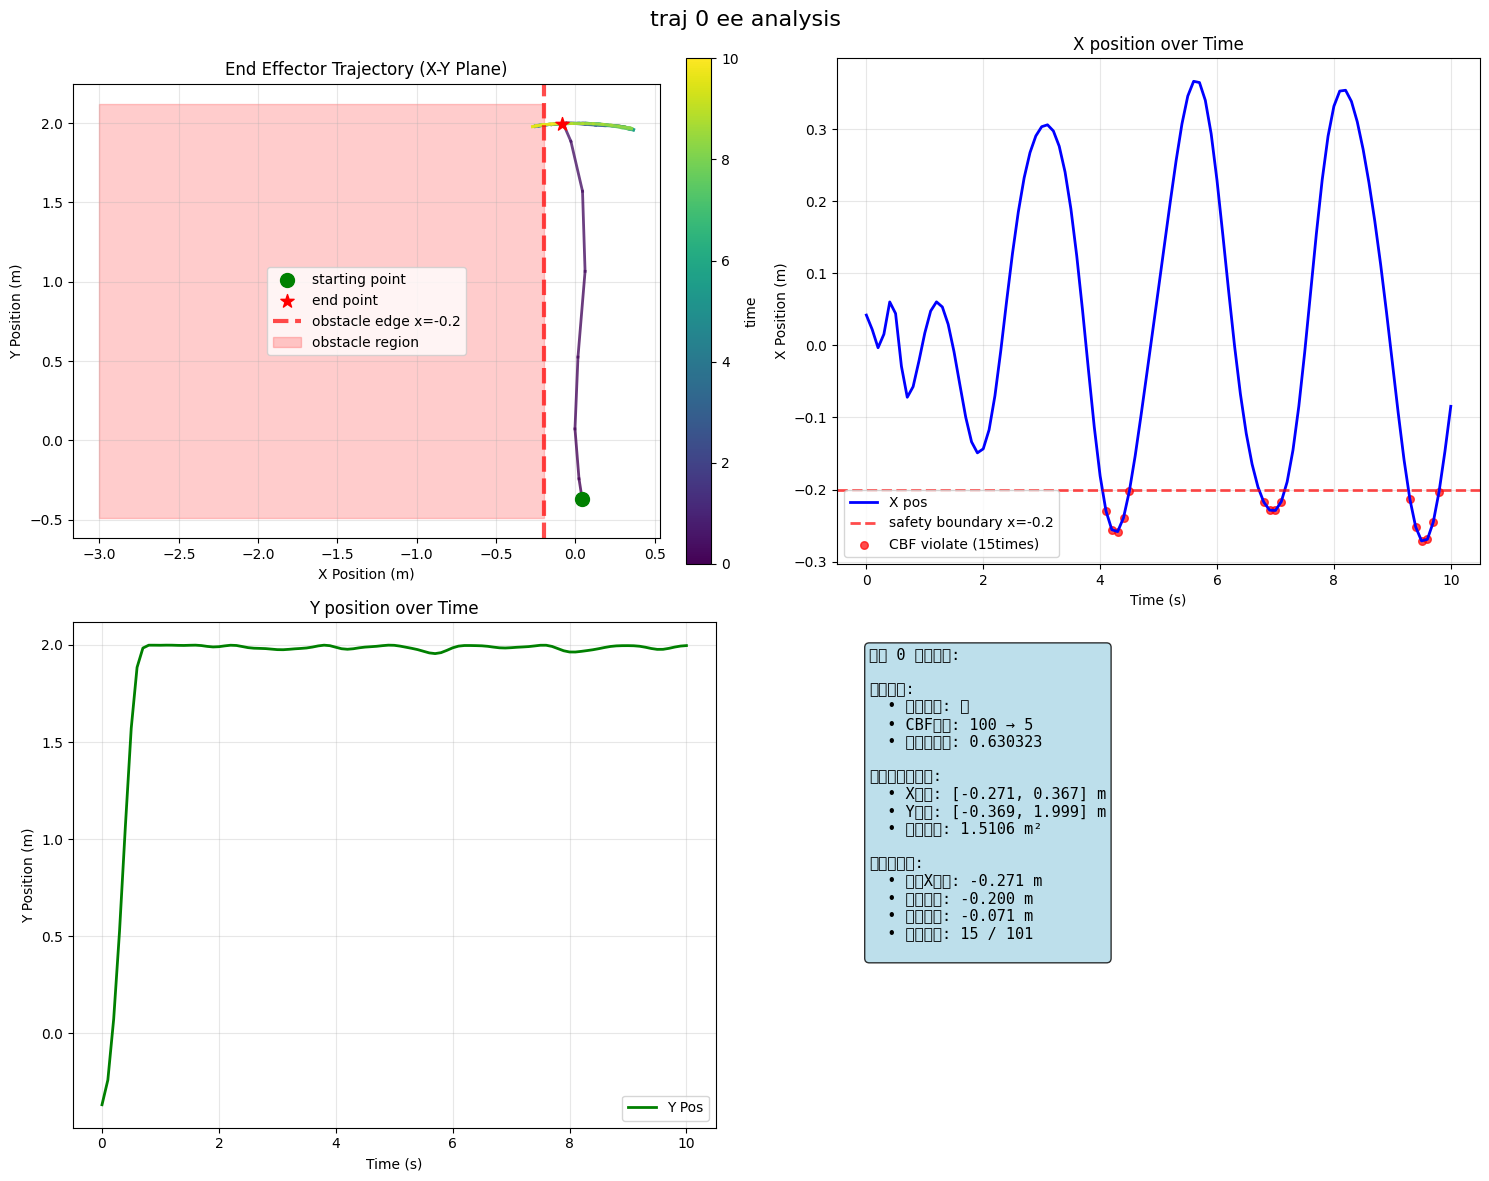

绘制所有 70 个轨迹的对比图...

 statics:
  all trajectory num: 70
  successfully optimized: 0
  num of full CBF satisfied: 17
  average CBF violation number: 2.21
  maxium CBF violation number: 5

 work space covering:
  X range: [-1.988, 1.984] m
  Y range: [-1.607, 2.000] m
  minimum x pos: -1.988 m
  edge to obstacle: -1.788 m


/tmp/ipykernel_747522/1210033310.py:308: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(endeffector_pos[0,0], endeffector_pos[0,1],
/tmp/ipykernel_747522/1210033310.py:312: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(endeffector_pos[-1,0], endeffector_pos[-1,1],


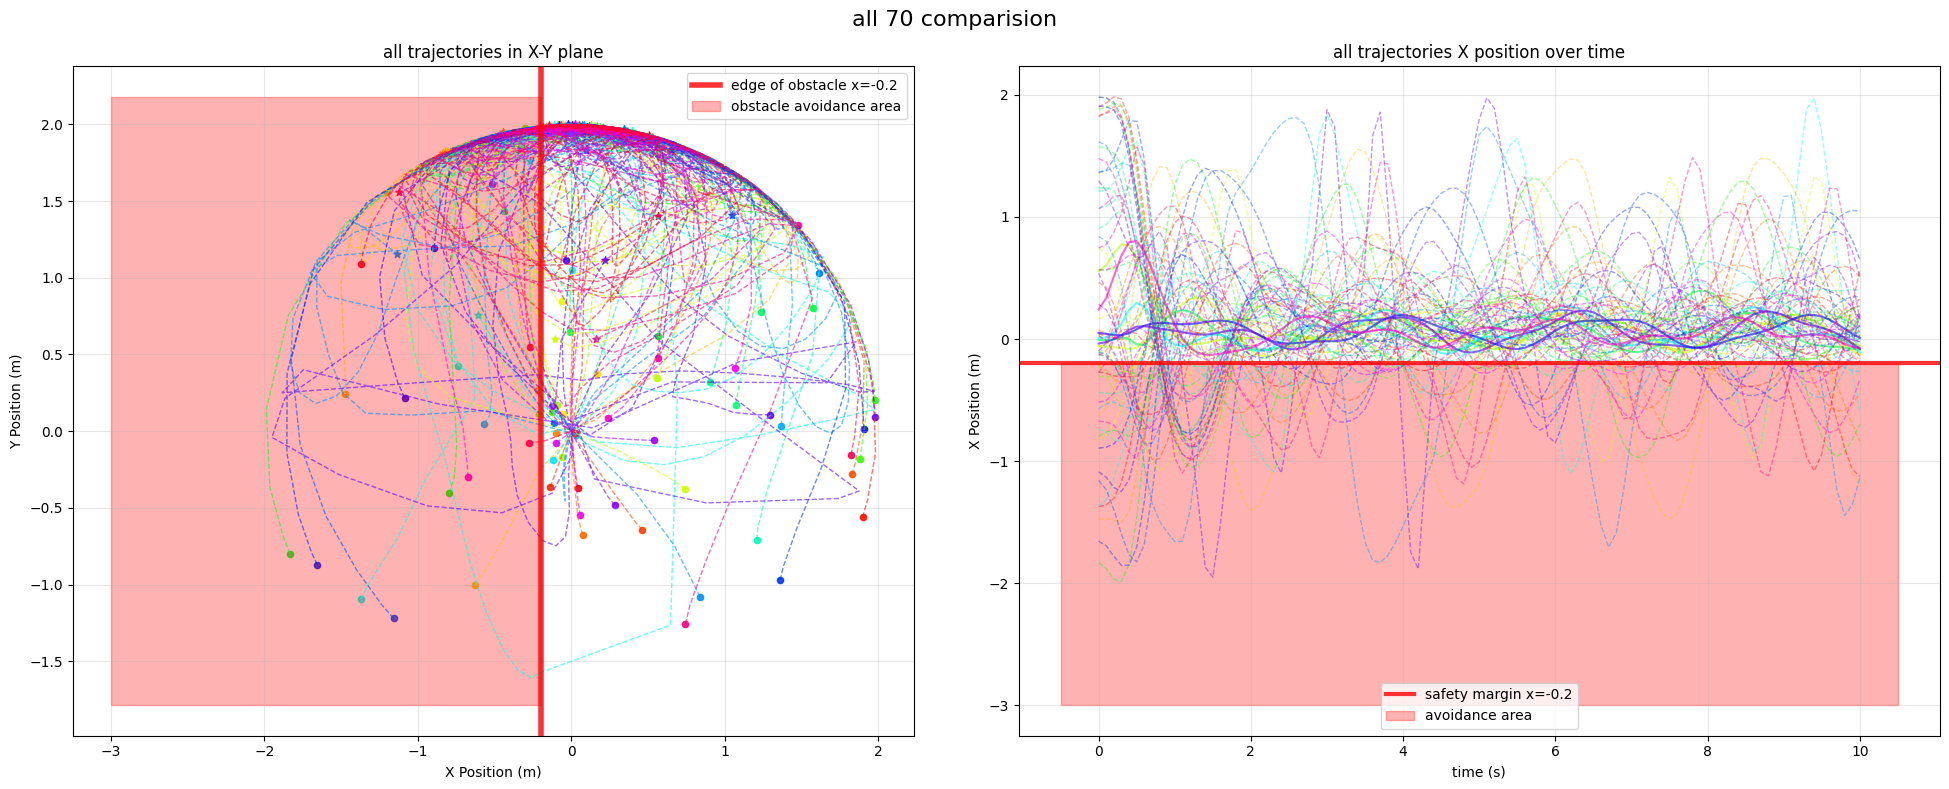


评估完成！
成功轨迹索引: []...
问题轨迹索引: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


In [31]:
# %%
# 末端执行器轨迹评估：前向动力学仿真和可视化

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# %%
# 前向动力学仿真函数

def simulate_endeffector_trajectory(initial_state, controls, dyn, dt=0.1, l1=1.0, l2=1.0):
    """
    使用控制序列进行前向动力学仿真，计算末端执行器轨迹
    
    参数:
    - initial_state: (4,) 初始状态 [θ1, θ2, ω1, ω2]
    - controls: (T, 2) 控制序列
    - dyn: 双摆动力学对象
    - dt: 时间步长
    - l1, l2: 连杆长度
    
    返回:
    - states: (T+1, 4) 仿真状态序列
    - endeffector_positions: (T+1, 2) 末端执行器位置序列 [x, y]
    """
    
    def forward_kinematics(state, l1=l1, l2=l2):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    # 初始化
    states = [initial_state.copy()]
    endeffector_positions = [forward_kinematics(initial_state)]
    
    # 前向仿真
    current_state = initial_state.copy()
    for t in range(len(controls)):
        if t < len(controls):
            control = controls[t]
            # RK4积分一步
            next_state = dyn.rk4_step(current_state, control, dt)
            states.append(next_state)
            endeffector_positions.append(forward_kinematics(next_state))
            current_state = next_state
    
    return np.array(states), np.array(endeffector_positions)

# %%
# 批量仿真所有轨迹的末端执行器位置

def batch_simulate_endeffector_trajectories(corrected_trajectories, dyn):
    """
    批量仿真所有修正后轨迹的末端执行器位置
    
    参数:
    - corrected_trajectories: CBF-CLF修正后的轨迹数据
    - dyn: 双摆动力学对象
    
    返回:
    - endeffector_trajectories: 所有轨迹的末端执行器位置列表
    - simulated_states: 所有轨迹的仿真状态列表
    """
    
    n_trajs = len(corrected_trajectories['corrected_states'])
    endeffector_trajectories = []
    simulated_states = []
    
    print(f"开始批量仿真 {n_trajs} 个轨迹的末端执行器位置...")
    
    for i in range(n_trajs):
        # 获取修正后的数据
        initial_state = corrected_trajectories['corrected_states'][i][0]
        controls = corrected_trajectories['corrected_controls'][i]
        
        # 前向仿真
        states, endeffector_pos = simulate_endeffector_trajectory(
            initial_state, controls, dyn
        )
        
        endeffector_trajectories.append(endeffector_pos)
        simulated_states.append(states)
        
        if (i + 1) % 10 == 0:
            print(f"  完成 {i+1}/{n_trajs} 轨迹仿真")
    
    print("批量仿真完成！")
    return endeffector_trajectories, simulated_states

# %%
# 执行批量仿真

# 初始化动力学模型
dyn = DoublePendulumDynamics()

# 批量仿真所有轨迹
endeffector_trajectories, simulated_states_all = batch_simulate_endeffector_trajectories(
    cbf_clf_corrected_trajectories, dyn
)

print(f"仿真结果:")
print(f"  轨迹数量: {len(endeffector_trajectories)}")
print(f"  每个轨迹长度: {len(endeffector_trajectories[0])}")
print(f"  末端执行器位置维度: {endeffector_trajectories[0].shape}")

# %%
# 绘制单个轨迹的末端执行器轨迹

def plot_single_endeffector_trajectory(trajectory_idx, endeffector_trajectories, 
                                     corrected_trajectories, obstacle_x=-0.2):
    """
    绘制单个轨迹的末端执行器轨迹详细图
    
    参数:
    - trajectory_idx: 轨迹索引 (0-69)
    - endeffector_trajectories: 末端执行器轨迹列表
    - corrected_trajectories: 修正后轨迹数据
    - obstacle_x: 障碍物x坐标
    """
    
    if trajectory_idx >= len(endeffector_trajectories):
        print(f"错误：轨迹索引 {trajectory_idx} 超出范围 (0-{len(endeffector_trajectories)-1})")
        return
    
    # 获取数据
    endeffector_pos = endeffector_trajectories[trajectory_idx]
    time_steps = np.arange(len(endeffector_pos)) * 0.1
    
    # 获取优化信息
    opt_info = corrected_trajectories['optimization_info'][trajectory_idx]
    cbf_before = corrected_trajectories['cbf_violations_before'][trajectory_idx]
    cbf_after = corrected_trajectories['cbf_violations_after'][trajectory_idx]
    dynamics_error = corrected_trajectories['dynamics_consistency_error'][trajectory_idx]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'traj {trajectory_idx} ee analysis', fontsize=16)
    
    # 1. 末端执行器轨迹 (X-Y平面)
    ax = axes[0, 0]
    
    # 绘制轨迹，颜色表示时间
    colors = cm.viridis(np.linspace(0, 1, len(endeffector_pos)))
    for i in range(len(endeffector_pos)-1):
        ax.plot([endeffector_pos[i,0], endeffector_pos[i+1,0]], 
                [endeffector_pos[i,1], endeffector_pos[i+1,1]], 
                color=colors[i], linewidth=2, alpha=0.8)
    
    # 标记起点和终点
    ax.scatter(endeffector_pos[0,0], endeffector_pos[0,1], 
               c='green', s=100, marker='o', label='starting point', zorder=5)
    ax.scatter(endeffector_pos[-1,0], endeffector_pos[-1,1], 
               c='red', s=100, marker='*', label='end point', zorder=5)
    
    # 障碍物边界
    ax.axvline(x=obstacle_x, color='red', linestyle='--', linewidth=3, 
               alpha=0.7, label=f'obstacle edge x={obstacle_x}')
    
    # 添加违反区域阴影
    y_min, y_max = ax.get_ylim()
    ax.fill_betweenx([y_min, y_max], -3, obstacle_x, alpha=0.2, color='red', label='obstacle region')
    
    ax.set_xlabel('X Position (m)')
    ax.set_ylabel('Y Position (m)')
    ax.set_title('End Effector Trajectory (X-Y Plane)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 添加颜色条表示时间
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=Normalize(vmin=0, vmax=time_steps[-1]))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('time')
    
    # 2. X位置随时间变化
    ax = axes[0, 1]
    ax.plot(time_steps, endeffector_pos[:,0], 'b-', linewidth=2, label='X pos')
    ax.axhline(y=obstacle_x, color='red', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'safety boundary x={obstacle_x}')
    
    # 标记违反时刻
    violations = endeffector_pos[:,0] < obstacle_x
    if np.any(violations):
        violation_times = time_steps[violations]
        violation_x = endeffector_pos[violations, 0]
        ax.scatter(violation_times, violation_x, c='red', s=30, alpha=0.7, 
                  label=f'CBF violate ({np.sum(violations)}times)')
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('X Position (m)')
    ax.set_title('X position over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Y位置随时间变化
    ax = axes[1, 0]
    ax.plot(time_steps, endeffector_pos[:,1], 'g-', linewidth=2, label='Y Pos')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Y Position (m)')
    ax.set_title('Y position over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. 统计信息文本
    ax = axes[1, 1]
    ax.axis('off')
    
    # 计算统计信息
    min_x = np.min(endeffector_pos[:,0])
    max_x = np.max(endeffector_pos[:,0])
    min_y = np.min(endeffector_pos[:,1])
    max_y = np.max(endeffector_pos[:,1])
    
    # 计算工作空间覆盖
    workspace_area = (max_x - min_x) * (max_y - min_y)
    
    info_text = f"""轨迹 {trajectory_idx} 统计信息:
    
优化结果:
  • 优化成功: {'是' if opt_info.get('success', False) else '否'}
  • CBF违反: {cbf_before} → {cbf_after}
  • 动力学误差: {dynamics_error:.6f}
  
末端执行器范围:
  • X范围: [{min_x:.3f}, {max_x:.3f}] m
  • Y范围: [{min_y:.3f}, {max_y:.3f}] m
  • 工作空间: {workspace_area:.4f} m²
  
安全性分析:
  • 最小X位置: {min_x:.3f} m
  • 安全边界: {obstacle_x:.3f} m
  • 安全余量: {min_x - obstacle_x:.3f} m
  • 违反次数: {np.sum(violations)} / {len(endeffector_pos)}
    """
    
    ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return fig

# %%
# 绘制所有轨迹的末端执行器轨迹

def plot_all_endeffector_trajectories(endeffector_trajectories, corrected_trajectories, 
                                    obstacle_x=-0.2, alpha=0.6):
    """
    在一个图中绘制所有轨迹的末端执行器轨迹
    
    参数:
    - endeffector_trajectories: 所有轨迹的末端执行器位置
    - corrected_trajectories: 修正后轨迹数据
    - obstacle_x: 障碍物x坐标
    - alpha: 透明度
    """
    
    n_trajs = len(endeffector_trajectories)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'all {n_trajs} comparision', fontsize=16)
    
    # 生成颜色映射
    colors = cm.tab20(np.linspace(0, 1, min(n_trajs, 20)))  # 最多20种颜色
    if n_trajs > 20:
        # 如果轨迹数超过20，使用连续颜色映射
        colors = cm.hsv(np.linspace(0, 1, n_trajs))
    
    # 统计变量
    successful_trajs = []
    failed_trajs = []
    cbf_violation_counts = []
    
    # 1. 所有轨迹在X-Y平面
    ax = ax1
    
    for i, endeffector_pos in enumerate(endeffector_trajectories):
        color = colors[i % len(colors)]
        
        # 检查优化是否成功
        opt_success = corrected_trajectories['optimization_info'][i].get('success', False)
        cbf_violations = corrected_trajectories['cbf_violations_after'][i]
        
        if opt_success and cbf_violations == 0:
            successful_trajs.append(i)
            linestyle = '-'
            linewidth = 1.5
        else:
            failed_trajs.append(i)
            linestyle = '--'
            linewidth = 1.0
        
        cbf_violation_counts.append(cbf_violations)
        
        # 绘制轨迹
        ax.plot(endeffector_pos[:,0], endeffector_pos[:,1], 
                color=color, alpha=alpha, linewidth=linewidth, 
                linestyle=linestyle, label=f'traj {i}' if i < 5 else '')
        
        # 标记起点
        ax.scatter(endeffector_pos[0,0], endeffector_pos[0,1], 
                  c=color, s=20, alpha=alpha*1.5, marker='o')
        
        # 标记终点
        ax.scatter(endeffector_pos[-1,0], endeffector_pos[-1,1], 
                  c=color, s=30, alpha=alpha*1.5, marker='*')
    
    # 障碍物边界
    ax.axvline(x=obstacle_x, color='red', linestyle='-', linewidth=4, 
               alpha=0.8, label=f'edge of obstacle x={obstacle_x}')
    
    # 添加禁止区域阴影
    y_min, y_max = ax.get_ylim()
    ax.fill_betweenx([y_min, y_max], -3, obstacle_x, alpha=0.3, color='red', label='obstacle avoidance area')
    
    ax.set_xlabel('X Position (m)')
    ax.set_ylabel('Y Position (m)')
    ax.set_title('all trajectories in X-Y plane')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 图例只显示前几个轨迹和重要元素
    handles, labels = ax.get_legend_handles_labels()
    important_handles = handles[-2:]  # 障碍边界和禁止区域
    important_labels = labels[-2:]
    ax.legend(important_handles, important_labels, loc='upper right')
    
    # 2. X位置时间历程
    ax = ax2
    
    time_steps = np.arange(len(endeffector_trajectories[0])) * 0.1
    
    for i, endeffector_pos in enumerate(endeffector_trajectories):
        color = colors[i % len(colors)]
        
        # 检查是否有CBF违反
        violations = endeffector_pos[:,0] < obstacle_x
        cbf_violations = np.sum(violations)
        
        if cbf_violations == 0:
            linestyle = '-'
            linewidth = 1.5
            alpha_line = alpha
        else:
            linestyle = '--'
            linewidth = 1.0
            alpha_line = alpha * 0.7
        
        ax.plot(time_steps, endeffector_pos[:,0], 
                color=color, alpha=alpha_line, linewidth=linewidth, 
                linestyle=linestyle)
    
    # 障碍边界
    ax.axhline(y=obstacle_x, color='red', linestyle='-', linewidth=3, 
               alpha=0.8, label=f'safety margin x={obstacle_x}')
    
    # 添加禁止区域阴影
    x_min, x_max = ax.get_xlim()
    ax.fill_between([x_min, x_max], -3, obstacle_x, alpha=0.3, color='red', label='avoidance area')
    
    ax.set_xlabel('time (s)')
    ax.set_ylabel('X Position (m)')
    ax.set_title('all trajectories X position over time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 打印统计信息
    print(f"\n statics:")
    print(f"  all trajectory num: {n_trajs}")
    print(f"  successfully optimized: {len(successful_trajs)}")
    print(f"  num of full CBF satisfied: {sum(1 for c in cbf_violation_counts if c == 0)}")
    print(f"  average CBF violation number: {np.mean(cbf_violation_counts):.2f}")
    print(f"  maxium CBF violation number: {max(cbf_violation_counts)}")
    
    # 工作空间分析
    all_x = np.concatenate([traj[:,0] for traj in endeffector_trajectories])
    all_y = np.concatenate([traj[:,1] for traj in endeffector_trajectories])
    
    print(f"\n work space covering:")
    print(f"  X range: [{np.min(all_x):.3f}, {np.max(all_x):.3f}] m")
    print(f"  Y range: [{np.min(all_y):.3f}, {np.max(all_y):.3f}] m")
    print(f"  minimum x pos: {np.min(all_x):.3f} m")
    print(f"  edge to obstacle: {np.min(all_x) - obstacle_x:.3f} m")
    
    plt.show()
    
    return fig, successful_trajs, failed_trajs

# %%
# 执行可视化

# 1. 绘制单个轨迹详细分析（可以修改索引）
SELECTED_TRAJECTORY_INDEX = 0  # 修改这个索引来查看不同轨迹 (0-69)

print(f"绘制轨迹 {SELECTED_TRAJECTORY_INDEX} 的详细分析...")
fig_single = plot_single_endeffector_trajectory(
    SELECTED_TRAJECTORY_INDEX, 
    endeffector_trajectories, 
    cbf_clf_corrected_trajectories,
    obstacle_x=-0.2
)

# %%
# 2. 绘制所有轨迹对比
print(f"绘制所有 {len(endeffector_trajectories)} 个轨迹的对比图...")
fig_all, successful_trajs, failed_trajs = plot_all_endeffector_trajectories(
    endeffector_trajectories,
    cbf_clf_corrected_trajectories, 
    obstacle_x=-0.2,
    alpha=0.6  # 调整透明度，0.3-0.8之间比较合适
)

print(f"\n评估完成！")
print(f"成功轨迹索引: {successful_trajs[:10]}...")  # 只显示前10个
print(f"问题轨迹索引: {failed_trajs[:10]}...")     # 只显示前10个

In [39]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

class ImprovedDynamicsConsistentCBF_CLF:
    """
    改进的CBF-CLF优化器，重点提升动力学一致性
    
    主要改进：
    1. 更精确的动力学约束建模
    2. 分离控制和状态优化
    3. 迭代优化策略
    4. 自适应权重调整
    """
    
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
        
    def forward_kinematics(self, state):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def cbf_constraint_value(self, state, x_min, margin=0.03):
        """CBF约束值计算"""
        end_pos = self.forward_kinematics(state)
        return end_pos[0] - (x_min + margin)
    
    def dynamics_residual(self, x_current, u, x_next):
        """计算动力学残差"""
        x_pred = self.dyn.rk4_step(x_current, u, self.dt)
        return x_pred - x_next
    
    def dynamics_jacobian_numerical(self, x_current, u, eps=1e-6):
        """数值计算动力学对控制的雅可比矩阵"""
        x_nominal = self.dyn.rk4_step(x_current, u, self.dt)
        J = np.zeros((4, 2))
        
        for i in range(2):
            u_plus = u.copy()
            u_minus = u.copy()
            u_plus[i] += eps
            u_minus[i] -= eps
            
            x_plus = self.dyn.rk4_step(x_current, u_plus, self.dt)
            x_minus = self.dyn.rk4_step(x_current, u_minus, self.dt)
            
            J[:, i] = (x_plus - x_minus) / (2 * eps)
        
        return J
    
    def optimize_controls_only(self, states_target, controls_initial, x_min, 
                              w_ctrl=0.1, w_dynamics=100.0, w_cbf=50.0, max_iter=200):
        """
        第一阶段：仅优化控制，保持状态轨迹不变
        重点确保动力学一致性
        """
        T = len(states_target)
        n_ctrl = T - 1
        
        def objective(U_flat):
            U = U_flat.reshape(n_ctrl, 2)
            cost = 0.0
            
            # 1. 控制修正正则化
            ctrl_diff = U - controls_initial[:n_ctrl]
            cost += w_ctrl * np.sum(ctrl_diff**2)
            
            # 2. 动力学一致性（关键优化）
            dynamics_cost = 0.0
            for t in range(n_ctrl):
                x_current = states_target[t]
                u_current = U[t]
                x_target = states_target[t+1]
                
                # 高精度动力学残差
                residual = self.dynamics_residual(x_current, u_current, x_target)
                dynamics_cost += np.sum(residual**2)
            
            cost += w_dynamics * dynamics_cost
            
            # 3. CBF软约束（通过仿真验证）
            cbf_cost = 0.0
            x_sim = states_target[0].copy()
            for t in range(n_ctrl):
                u = U[t]
                x_sim = self.dyn.rk4_step(x_sim, u, self.dt)
                
                cbf_val = self.cbf_constraint_value(x_sim, x_min)
                if cbf_val < 0:
                    cbf_cost += (-cbf_val)**2  # 二次惩罚
            
            cost += w_cbf * cbf_cost
            
            return cost
        
        # 边界约束
        bounds = [(-20, 20) for _ in range(n_ctrl * 2)]
        
        # 初始猜测
        U0 = controls_initial[:n_ctrl].flatten()
        
        # 优化
        result = minimize(
            objective, U0,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': max_iter, 'ftol': 1e-9}
        )
        
        if result.success:
            U_opt = result.x.reshape(n_ctrl, 2)
            # 补充最后一步控制
            controls_optimized = np.vstack([U_opt, controls_initial[-1:]])
        else:
            controls_optimized = controls_initial
        
        return controls_optimized, result
    
    def optimize_states_and_controls(self, states_initial, controls_optimized, x_min,
                                   w_state=1.0, w_ctrl=0.5, w_dynamics=200.0, w_cbf=100.0,
                                   max_iter=300):
        """
        第二阶段：联合优化状态和控制
        在保持动力学一致性的基础上进一步改善CBF约束
        """
        T = len(states_initial)
        n_ctrl = T - 1
        n_states_var = (T-1) * 4
        n_controls_var = n_ctrl * 2
        
        def objective(x):
            # 解包变量
            states_var = x[:n_states_var].reshape(T-1, 4)
            controls_var = x[n_states_var:].reshape(n_ctrl, 2)
            
            # 重构完整序列
            states_full = np.vstack([states_initial[0:1], states_var])
            
            cost = 0.0
            
            # 1. 状态修正正则化
            state_diff = states_var - states_initial[1:]
            cost += w_state * np.sum(state_diff**2)
            
            # 2. 控制修正正则化
            ctrl_diff = controls_var - controls_optimized[:n_ctrl]
            cost += w_ctrl * np.sum(ctrl_diff**2)
            
            # 3. 动力学一致性（强约束）
            dynamics_cost = 0.0
            for t in range(n_ctrl):
                x_current = states_full[t]
                u_current = controls_var[t]
                x_target = states_full[t+1]
                
                residual = self.dynamics_residual(x_current, u_current, x_target)
                dynamics_cost += np.sum(residual**2)
            
            cost += w_dynamics * dynamics_cost
            
            # 4. CBF约束（直接在状态上）
            cbf_cost = 0.0
            for t in range(T):
                cbf_val = self.cbf_constraint_value(states_full[t], x_min)
                if cbf_val < 0:
                    cbf_cost += (-cbf_val)**2
            
            cost += w_cbf * cbf_cost
            
            return cost
        
        # 边界约束
        bounds = []
        # 状态边界
        for _ in range(T-1):
            bounds.extend([(-3*np.pi, 3*np.pi), (-3*np.pi, 3*np.pi), 
                          (-30, 30), (-30, 30)])
        # 控制边界
        for _ in range(n_ctrl):
            bounds.extend([(-20, 20), (-20, 20)])
        
        # 初始猜测
        x0 = np.concatenate([states_initial[1:].flatten(), 
                            controls_optimized[:n_ctrl].flatten()])
        
        # 优化
        result = minimize(
            objective, x0,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': max_iter, 'ftol': 1e-9}
        )
        
        if result.success:
            states_var_opt = result.x[:n_states_var].reshape(T-1, 4)
            controls_var_opt = result.x[n_states_var:].reshape(n_ctrl, 2)
            
            states_optimized = np.vstack([states_initial[0:1], states_var_opt])
            controls_final = np.vstack([controls_var_opt, controls_optimized[-1:]])
        else:
            states_optimized = states_initial
            controls_final = controls_optimized
        
        return states_optimized, controls_final, result
    
    def optimize_trajectory_enhanced(self, states_original, controls_original, 
                                   x_min=-0.2, verbose=True):
        """
        增强的两阶段轨迹优化
        """
        if verbose:
            print("开始两阶段CBF-CLF优化...")
            print(f"障碍边界: x_min = {x_min}")
        
        # 阶段1：仅优化控制，确保动力学一致性
        if verbose:
            print("\n阶段1: 优化控制输入...")
        
        start_time = time.time()
        controls_stage1, result1 = self.optimize_controls_only(
            states_target=states_original,
            controls_initial=controls_original,
            x_min=x_min,
            w_ctrl=0.1,
            w_dynamics=100.0,
            w_cbf=50.0,
            max_iter=200
        )
        stage1_time = time.time() - start_time
        
        if verbose:
            print(f"  阶段1完成: {stage1_time:.2f}s, 成功: {result1.success}")
        
        # 验证阶段1结果
        simulated_states_stage1 = [states_original[0].copy()]
        for t in range(len(controls_stage1) - 1):
            next_state = self.dyn.rk4_step(simulated_states_stage1[-1], controls_stage1[t], self.dt)
            simulated_states_stage1.append(next_state)
        simulated_states_stage1 = np.array(simulated_states_stage1)
        
        dynamics_error_stage1 = np.mean(np.linalg.norm(simulated_states_stage1 - states_original, axis=1))
        
        # 计算CBF违反（仿真结果）
        cbf_violations_stage1 = 0
        for state in simulated_states_stage1:
            if self.cbf_constraint_value(state, x_min) < 0:
                cbf_violations_stage1 += 1
        
        if verbose:
            print(f"  阶段1动力学误差: {dynamics_error_stage1:.6f}")
            print(f"  阶段1 CBF违反: {cbf_violations_stage1}/{len(simulated_states_stage1)}")
        
        # 阶段2：联合优化状态和控制
        if verbose:
            print("\n阶段2: 联合优化状态和控制...")
        
        start_time = time.time()
        states_final, controls_final, result2 = self.optimize_states_and_controls(
            states_initial=states_original,
            controls_optimized=controls_stage1,
            x_min=x_min,
            w_state=1.0,
            w_ctrl=0.5,
            w_dynamics=200.0,  # 增强动力学权重
            w_cbf=100.0,
            max_iter=300
        )
        stage2_time = time.time() - start_time
        
        if verbose:
            print(f"  阶段2完成: {stage2_time:.2f}s, 成功: {result2.success}")
        
        # 最终验证
        final_simulated_states = [states_final[0].copy()]
        for t in range(len(controls_final) - 1):
            next_state = self.dyn.rk4_step(final_simulated_states[-1], controls_final[t], self.dt)
            final_simulated_states.append(next_state)
        final_simulated_states = np.array(final_simulated_states)
        
        final_dynamics_error = np.mean(np.linalg.norm(final_simulated_states - states_final, axis=1))
        
        # 计算最终CBF违反
        final_cbf_violations = 0
        min_cbf_value = float('inf')
        for state in final_simulated_states:
            cbf_val = self.cbf_constraint_value(state, x_min)
            min_cbf_value = min(min_cbf_value, cbf_val)
            if cbf_val < 0:
                final_cbf_violations += 1
        
        if verbose:
            print(f"\n最终结果:")
            print(f"  动力学误差: {final_dynamics_error:.6f} (改善: {dynamics_error_stage1/final_dynamics_error:.2f}x)")
            print(f"  CBF违反: {final_cbf_violations}/{len(final_simulated_states)}")
            print(f"  最小CBF值: {min_cbf_value:.6f}")
            print(f"  总处理时间: {stage1_time + stage2_time:.2f}s")
        
        # 优化信息
        optimization_info = {
            'success': result1.success and result2.success,
            'stage1_success': result1.success,
            'stage2_success': result2.success,
            'cbf_violations': final_cbf_violations,
            'min_cbf_value': min_cbf_value,
            'dynamics_error': final_dynamics_error,
            'dynamics_improvement': dynamics_error_stage1 / max(final_dynamics_error, 1e-10),
            'stage1_time': stage1_time,
            'stage2_time': stage2_time,
            'total_time': stage1_time + stage2_time
        }
        
        return states_final, controls_final, optimization_info

def test_enhanced_cbf_clf_solver(n_trajectories=15, x_min=-0.2):
    """
    测试增强的CBF-CLF求解器
    """
    print(f"测试增强CBF-CLF求解器（两阶段优化），共{n_trajectories}个轨迹...")
    print("="*70)
    
    # 初始化
    dyn = DoublePendulumDynamics()
    enhanced_optimizer = ImprovedDynamicsConsistentCBF_CLF(dyn)
    
    # 存储结果
    test_results = {
        'trajectory_indices': [],
        'original_states': [],
        'original_controls': [],
        'optimized_states': [],
        'optimized_controls': [],
        'optimization_info': [],
        'original_ee_positions': [],
        'optimized_ee_positions': [],
        'original_simulated_states': [],
        'optimized_simulated_states': [],
        'original_simulated_ee_positions': [],
        'optimized_simulated_ee_positions': [],
        'cbf_violations_before': [],
        'cbf_violations_after': [],
        'dynamics_errors_before': [],
        'dynamics_errors_after': [],
        'processing_times': []
    }
    
    successful_optimizations = 0
    total_dynamics_improvement = 0
    
    for traj_idx in range(n_trajectories):
        print(f"\n处理轨迹 {traj_idx}:")
        print("-" * 50)
        
        # 获取原始数据
        original_states = generated_trajectories[traj_idx]['states']
        original_controls = generated_trajectories[traj_idx]['controls']
        
        # 计算原始末端执行器位置
        original_ee_positions = []
        for state in original_states:
            ee_pos = enhanced_optimizer.forward_kinematics(state)
            original_ee_positions.append(ee_pos)
        original_ee_positions = np.array(original_ee_positions)
        
        # 原始控制仿真
        original_simulated_states = [original_states[0].copy()]
        for t in range(len(original_controls) - 1):
            next_state = dyn.rk4_step(original_simulated_states[-1], original_controls[t], 0.1)
            original_simulated_states.append(next_state)
        original_simulated_states = np.array(original_simulated_states)
        
        # 原始仿真末端执行器位置
        original_simulated_ee_positions = []
        for state in original_simulated_states:
            ee_pos = enhanced_optimizer.forward_kinematics(state)
            original_simulated_ee_positions.append(ee_pos)
        original_simulated_ee_positions = np.array(original_simulated_ee_positions)
        
        # 计算原始动力学误差
        original_dynamics_error = np.mean(np.linalg.norm(original_simulated_states - original_states, axis=1))
        original_cbf_violations = np.sum(original_ee_positions[:, 0] < x_min)
        
        print(f"原始轨迹: CBF违反 {original_cbf_violations}/{len(original_states)}, "
              f"动力学误差 {original_dynamics_error:.6f}")
        
        try:
            # 执行增强优化
            optimized_states, optimized_controls, opt_info = enhanced_optimizer.optimize_trajectory_enhanced(
                states_original=original_states,
                controls_original=original_controls,
                x_min=x_min,
                verbose=False  # 简化输出
            )
            
            # 计算优化后末端执行器位置
            optimized_ee_positions = []
            for state in optimized_states:
                ee_pos = enhanced_optimizer.forward_kinematics(state)
                optimized_ee_positions.append(ee_pos)
            optimized_ee_positions = np.array(optimized_ee_positions)
            
            # 优化后控制仿真
            optimized_simulated_states = [optimized_states[0].copy()]
            for t in range(len(optimized_controls) - 1):
                next_state = dyn.rk4_step(optimized_simulated_states[-1], optimized_controls[t], 0.1)
                optimized_simulated_states.append(next_state)
            optimized_simulated_states = np.array(optimized_simulated_states)
            
            # 优化后仿真末端执行器位置
            optimized_simulated_ee_positions = []
            for state in optimized_simulated_states:
                ee_pos = enhanced_optimizer.forward_kinematics(state)
                optimized_simulated_ee_positions.append(ee_pos)
            optimized_simulated_ee_positions = np.array(optimized_simulated_ee_positions)
            
            # 统计结果
            optimized_dynamics_error = opt_info['dynamics_error']
            optimized_cbf_violations = opt_info['cbf_violations']
            dynamics_improvement = opt_info['dynamics_improvement']
            
            if opt_info['success']:
                successful_optimizations += 1
                total_dynamics_improvement += dynamics_improvement
            
            print(f"优化结果: 成功 {opt_info['success']}, "
                  f"CBF违反 {original_cbf_violations}→{optimized_cbf_violations}, "
                  f"动力学改善 {dynamics_improvement:.2f}x")
            
            # 存储结果
            test_results['trajectory_indices'].append(traj_idx)
            test_results['original_states'].append(original_states)
            test_results['original_controls'].append(original_controls)
            test_results['optimized_states'].append(optimized_states)
            test_results['optimized_controls'].append(optimized_controls)
            test_results['optimization_info'].append(opt_info)
            test_results['original_ee_positions'].append(original_ee_positions)
            test_results['optimized_ee_positions'].append(optimized_ee_positions)
            test_results['original_simulated_states'].append(original_simulated_states)
            test_results['optimized_simulated_states'].append(optimized_simulated_states)
            test_results['original_simulated_ee_positions'].append(original_simulated_ee_positions)
            test_results['optimized_simulated_ee_positions'].append(optimized_simulated_ee_positions)
            test_results['cbf_violations_before'].append(original_cbf_violations)
            test_results['cbf_violations_after'].append(optimized_cbf_violations)
            test_results['dynamics_errors_before'].append(original_dynamics_error)
            test_results['dynamics_errors_after'].append(optimized_dynamics_error)
            test_results['processing_times'].append(opt_info['total_time'])
            
        except Exception as e:
            print(f"优化失败: {str(e)}")
            # 存储原始数据作为失败情况
            test_results['trajectory_indices'].append(traj_idx)
            test_results['original_states'].append(original_states)
            test_results['original_controls'].append(original_controls)
            test_results['optimized_states'].append(original_states)
            test_results['optimized_controls'].append(original_controls)
            test_results['optimization_info'].append({'success': False, 'error': str(e)})
            test_results['original_ee_positions'].append(original_ee_positions)
            test_results['optimized_ee_positions'].append(original_ee_positions)
            test_results['original_simulated_states'].append(original_simulated_states)
            test_results['optimized_simulated_states'].append(original_simulated_states)
            test_results['original_simulated_ee_positions'].append(original_simulated_ee_positions)
            test_results['optimized_simulated_ee_positions'].append(original_simulated_ee_positions)
            test_results['cbf_violations_before'].append(original_cbf_violations)
            test_results['cbf_violations_after'].append(original_cbf_violations)
            test_results['dynamics_errors_before'].append(original_dynamics_error)
            test_results['dynamics_errors_after'].append(original_dynamics_error)
            test_results['processing_times'].append(0)
    
    # 汇总统计
    success_rate = successful_optimizations / n_trajectories * 100
    avg_cbf_before = np.mean(test_results['cbf_violations_before'])
    avg_cbf_after = np.mean(test_results['cbf_violations_after'])
    avg_dynamics_before = np.mean(test_results['dynamics_errors_before'])
    avg_dynamics_after = np.mean(test_results['dynamics_errors_after'])
    avg_dynamics_improvement = total_dynamics_improvement / max(successful_optimizations, 1)
    avg_processing_time = np.mean(test_results['processing_times'])
    
    print(f"\n" + "="*70)
    print("增强CBF-CLF求解器测试汇总:")
    print(f"  成功率: {success_rate:.1f}% ({successful_optimizations}/{n_trajectories})")
    print(f"  CBF违反改善: {avg_cbf_before:.1f} → {avg_cbf_after:.1f}")
    print(f"  动力学误差改善: {avg_dynamics_before:.6f} → {avg_dynamics_after:.6f}")
    print(f"  平均动力学改善倍数: {avg_dynamics_improvement:.2f}x")
    print(f"  平均处理时间: {avg_processing_time:.2f}s")
    print("="*70)
    
    return test_results

In [16]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

class ImprovedCBF_CLF_Optimizer:
    """
    改进的CBF-CLF联合优化器
    主要改进：
    1. 移除硬约束，只使用软约束
    2. 渐进式CBF约束
    3. 改进的求解器和多起点优化
    4. 平衡的权重设计
    """
    
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
        
    def forward_kinematics(self, state):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def progressive_cbf_value(self, state, x_min, t, T, base_margin=0.03):
        """
        渐进式CBF约束值
        早期允许更大违反，后期更严格
        """
        end_pos = self.forward_kinematics(state)
        
        # 时间因子：0(开始) -> 1(结束)
        time_factor = min(t / (T * 0.8), 1.0)  # 前80%时间渐进，后20%固定
        
        # 适应性边距：开始时较大，结束时较小
        adaptive_margin = base_margin + 0.05 * (1 - time_factor)
        
        return end_pos[0] - (x_min + adaptive_margin)
    
    def compute_endeffector_velocity(self, state):
        """计算末端执行器速度（近似）"""
        θ1, θ2, ω1, ω2 = state
        
        # 雅可比矩阵
        J11 = self.l1 * np.cos(θ1) + self.l2 * np.cos(θ2)
        J12 = self.l2 * np.cos(θ2)
        J21 = self.l1 * np.sin(θ1) + self.l2 * np.sin(θ2)
        J22 = self.l2 * np.sin(θ2)
        
        J = np.array([[J11, J12], [J21, J22]])
        ω = np.array([ω1, ω2])
        
        return J @ ω
    
    def improved_objective(self, x, states_original, controls_original, x_min, 
                          w_state, w_ctrl, w_dynamics, w_cbf):
        """
        改进的目标函数：只使用软约束，权重平衡
        """
        T = len(states_original)
        n_ctrl = T - 1
        n_states_var = (T-1) * 4
        
        # 解包变量
        states_var = x[:n_states_var].reshape(T-1, 4)
        controls_var = x[n_states_var:].reshape(n_ctrl, 2)
        
        # 重构完整序列
        states_full = np.vstack([states_original[0:1], states_var])
        controls_full = np.vstack([controls_var, controls_original[-1:]])
        
        cost = 0.0
        
        # 1. 状态修正正则化（L2）
        state_diff = states_var - states_original[1:]
        cost += w_state * np.sum(state_diff**2)
        
        # 2. 控制修正正则化（L2）
        ctrl_diff = controls_var - controls_original[:n_ctrl]
        cost += w_ctrl * np.sum(ctrl_diff**2)
        
        # 3. 动力学一致性（L2）
        dynamics_cost = 0.0
        for t in range(n_ctrl):
            x_current = states_full[t]
            u_current = controls_var[t]
            x_next_target = states_full[t+1]
            
            # RK4预测
            x_next_pred = self.dyn.rk4_step(x_current, u_current, self.dt)
            
            # 动力学残差
            dynamics_error = x_next_pred - x_next_target
            dynamics_cost += np.sum(dynamics_error**2)
        
        cost += w_dynamics * dynamics_cost
        
        # 4. CBF软约束（指数惩罚）
        cbf_cost = 0.0
        for t in range(T):
            cbf_val = self.progressive_cbf_value(states_full[t], x_min, t, T)
            
            if cbf_val < 0:
                # 指数惩罚：违反越严重，惩罚越重
                cbf_cost += np.exp(-cbf_val * 20)  # 调整倍数控制惩罚强度
            else:
                # 轻微奖励满足约束
                cbf_cost -= 0.01 * cbf_val
        
        cost += w_cbf * cbf_cost
        
        # 5. 速度惩罚（避免过大速度）
        velocity_cost = 0.0
        for t in range(T):
            vel = self.compute_endeffector_velocity(states_full[t])
            if np.linalg.norm(vel) > 10:  # 速度限制
                velocity_cost += (np.linalg.norm(vel) - 10)**2
        
        cost += 0.1 * velocity_cost
        
        return cost
    
    def generate_smart_initial_guess(self, states_original, controls_original, x_min):
        """
        生成智能初始猜测
        """
        T = len(states_original)
        n_ctrl = T - 1
        
        # 检查原始轨迹违反情况
        violations = []
        for t in range(T):
            end_pos = self.forward_kinematics(states_original[t])
            if end_pos[0] < x_min:
                violations.append(t)
        
        if len(violations) == 0:
            # 原始轨迹已满足约束，轻微扰动
            states_guess = states_original[1:] + np.random.normal(0, 0.01, (T-1, 4))
            controls_guess = controls_original[:n_ctrl] + np.random.normal(0, 0.1, (n_ctrl, 2))
        else:
            # 原始轨迹违反约束，需要更大调整
            states_guess = states_original[1:].copy()
            controls_guess = controls_original[:n_ctrl].copy()
            
            # 对违反时刻的状态进行调整
            for t in violations:
                if t > 0:  # 不调整初始状态
                    # 增大第一关节角度，使末端执行器向右移动
                    states_guess[t-1, 0] += np.random.uniform(0.1, 0.3)
                    # 增大控制输入
                    if t-1 < n_ctrl:
                        controls_guess[t-1, 0] += np.random.uniform(1, 3)
        
        return np.concatenate([states_guess.flatten(), controls_guess.flatten()])
    
    def optimize_trajectory_improved(self, states_original, controls_original, 
                                   x_min=-1.2, max_iter=300, n_restarts=3, verbose=True):
        """
        改进的轨迹优化方法
        """
        T = len(states_original)
        n_ctrl = T - 1
        n_states_var = (T-1) * 4
        n_controls_var = n_ctrl * 2
        
        # 平衡的权重设计
        w_state = 1.0          # 状态修正
        w_ctrl = 0.5           # 控制修正  
        w_dynamics = 50.0      # 动力学一致性（降低）
        w_cbf = 200.0          # CBF约束（降低）
        
        if verbose:
            print(f"改进优化参数:")
            print(f"  权重: state={w_state}, ctrl={w_ctrl}, dynamics={w_dynamics}, cbf={w_cbf}")
            print(f"  障碍位置: x_min={x_min}")
            print(f"  重启次数: {n_restarts}")
        
        # 设置变量边界（放宽）
        bounds = []
        # 状态边界：角度[-3π, 3π]，角速度[-30, 30]
        for _ in range(T-1):
            bounds.extend([(-3*np.pi, 3*np.pi), (-3*np.pi, 3*np.pi), 
                          (-30, 30), (-30, 30)])
        # 控制边界：扭矩[-20, 20]
        for _ in range(n_ctrl):
            bounds.extend([(-20, 20), (-20, 20)])
        
        best_result = None
        best_cost = float('inf')
        
        if verbose:
            print(f"开始多起点优化...")
        
        for restart in range(n_restarts):
            if verbose:
                print(f"  重启 {restart+1}/{n_restarts}")
            
            # 生成初始猜测
            if restart == 0:
                # 第一次使用智能猜测
                x0 = self.generate_smart_initial_guess(states_original, controls_original, x_min)
            else:
                # 后续使用随机扰动
                x0_smart = self.generate_smart_initial_guess(states_original, controls_original, x_min)
                noise_scale = 0.1 * (restart + 1)  # 逐渐增大扰动
                x0 = x0_smart + np.random.normal(0, noise_scale, len(x0_smart))
            
            # 边界检查
            x0 = np.clip(x0, [b[0] for b in bounds], [b[1] for b in bounds])
            
            # 目标函数
            def objective(x):
                return self.improved_objective(x, states_original, controls_original, 
                                             x_min, w_state, w_ctrl, w_dynamics, w_cbf)
            
            try:
                # 使用trust-constr求解器
                result = minimize(
                    objective, x0,
                    method='trust-constr',
                    bounds=bounds,
                    options={
                        'maxiter': max_iter,
                        'gtol': 1e-6,
                        'xtol': 1e-8,
                        'verbose': 0
                    }
                )
                
                if result.fun < best_cost:
                    best_cost = result.fun
                    best_result = result
                    if verbose:
                        print(f"    新最优解: cost={best_cost:.6f}")
                
            except Exception as e:
                if verbose:
                    print(f"    优化失败: {str(e)}")
                continue
        
        if best_result is None:
            if verbose:
                print("所有重启都失败，返回原始轨迹")
            return states_original, controls_original, {'success': False, 'message': 'All restarts failed'}
        
        # 解包最优结果
        x_opt = best_result.x
        states_var_opt = x_opt[:n_states_var].reshape(T-1, 4)
        controls_var_opt = x_opt[n_states_var:].reshape(n_ctrl, 2)
        
        states_corrected = np.vstack([states_original[0:1], states_var_opt])
        controls_corrected = np.vstack([controls_var_opt, controls_original[-1:]])
        
        # 验证结果
        cbf_violations = 0
        min_cbf_value = float('inf')
        for t in range(T):
            cbf_val = self.progressive_cbf_value(states_corrected[t], x_min, t, T)
            min_cbf_value = min(min_cbf_value, cbf_val)
            if cbf_val < 0:
                cbf_violations += 1
        
        optimization_info = {
            'success': best_result.success,
            'fun': best_result.fun,
            'message': best_result.message,
            'cbf_violations': cbf_violations,
            'min_cbf_value': min_cbf_value,
            'n_restarts_used': n_restarts
        }
        
        if verbose:
            print(f"优化完成:")
            print(f"  成功: {optimization_info['success']}")
            print(f"  CBF违反: {cbf_violations}/{T}")
            print(f"  最小CBF值: {min_cbf_value:.6f}")
        
        return states_corrected, controls_corrected, optimization_info

# 使用示例
# def test_improved_optimizer():
#     """测试改进的优化器"""
#     # 假设已有的数据
#     dyn = DoublePendulumDynamics()
#     optimizer = ImprovedCBF_CLF_Optimizer(dyn)
    
#     # 选择一个轨迹测试
#     traj_idx = 0
#     original_states = generated_trajectories[traj_idx]['states']
#     original_controls = generated_trajectories[traj_idx]['controls']
    
#     print("测试改进的CBF-CLF优化器...")
    
#     # 执行优化
#     states_corrected, controls_corrected, opt_info = optimizer.optimize_trajectory_improved(
#         states_original=original_states,
#         controls_original=original_controls,
#         x_min=-0.2,
#         max_iter=100,
#         n_restarts=3,
#         verbose=True
#     )
    
#     return states_corrected, controls_corrected, opt_info

import time
from scipy.optimize import minimize
import pickle
from datetime import datetime

def test_improved_optimizer():
    """测试改进的优化器 - 批量处理40个轨迹"""
    # 假设已有的数据
    dyn = DoublePendulumDynamics()
    optimizer = ImprovedCBF_CLF_Optimizer(dyn)
    
    print("开始批量处理40个轨迹的CBF-CLF优化...")
    
    # 存储所有结果
    batch_results = {
        'corrected_trajectories': [],
        'optimization_info': [],
        'processing_time': [],
        'total_trajectories': 40,
        'optimization_params': {
            'x_min': -1.2,
            'max_iter': 100,
            'n_restarts': 3
        },
        'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S")
    }
    
    successful_corrections = 0
    total_start_time = time.time()
    
    # 批量处理轨迹 0-39
    for traj_idx in range(40):
        print(f"\n处理轨迹 {traj_idx+1}/40 (索引: {traj_idx})")
        
        try:
            original_states = generated_trajectories[traj_idx]['states']
            original_controls = generated_trajectories[traj_idx]['controls']
            
            # 记录单个轨迹处理时间
            single_start_time = time.time()
            
            # 执行优化
            states_corrected, controls_corrected, opt_info = optimizer.optimize_trajectory_improved(
                states_original=original_states,
                controls_original=original_controls,
                x_min=-1.2,
                max_iter=100,
                n_restarts=3,
                verbose=False  # 批量处理时关闭详细输出
            )
            
            single_end_time = time.time()
            processing_time = single_end_time - single_start_time
            
            # 存储结果
            trajectory_result = {
                'original_index': traj_idx,
                'states_original': original_states,
                'controls_original': original_controls,
                'states_corrected': states_corrected,
                'controls_corrected': controls_corrected,
                'processing_time': processing_time
            }
            
            batch_results['corrected_trajectories'].append(trajectory_result)
            batch_results['optimization_info'].append(opt_info)
            batch_results['processing_time'].append(processing_time)
            
            if opt_info['success']:
                successful_corrections += 1
            
            # 简要进度报告
            print(f"  完成时间: {processing_time:.2f}秒")
            print(f"  优化成功: {opt_info['success']}")
            print(f"  CBF违反: {opt_info['cbf_violations']}")
            
        except Exception as e:
            print(f"  轨迹 {traj_idx} 处理失败: {str(e)}")
            # 记录失败信息
            trajectory_result = {
                'original_index': traj_idx,
                'error': str(e),
                'processing_time': 0
            }
            batch_results['corrected_trajectories'].append(trajectory_result)
            batch_results['optimization_info'].append({'success': False, 'error': str(e)})
            batch_results['processing_time'].append(0)
    
    total_end_time = time.time()
    total_processing_time = total_end_time - total_start_time
    
    # 添加汇总信息
    batch_results['summary'] = {
        'total_processing_time': total_processing_time,
        'successful_corrections': successful_corrections,
        'success_rate': successful_corrections / 40,
        'average_time_per_trajectory': np.mean(batch_results['processing_time'])
    }
    
    print(f"\n=== 批量处理完成 ===")
    print(f"总处理时间: {total_processing_time:.2f}秒")
    print(f"成功优化: {successful_corrections}/40 ({successful_corrections/40*100:.1f}%)")
    print(f"平均每轨迹时间: {np.mean(batch_results['processing_time']):.2f}秒")
    
    # 保存结果文件
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"relaxed_cbf_clf_corrected_trajectories_for_paper_{timestamp}.pkl"
    
    with open(filename, 'wb') as f:
        pickle.dump(batch_results, f)
    
    print(f"结果已保存到: {filename}")
    
    return batch_results

# 主执行代码
if __name__ == "__main__":
    print("开始批量CBF-CLF轨迹优化...")
    
    # 运行批量优化
    batch_results = test_improved_optimizer()
    
    # 可选：显示一些统计信息
    print("\n=== 详细统计 ===")
    processing_times = batch_results['processing_time']
    print(f"处理时间统计:")
    print(f"  最小: {min(processing_times):.2f}秒")
    print(f"  最大: {max(processing_times):.2f}秒")
    print(f"  中位数: {np.median(processing_times):.2f}秒")
    
    # CBF违反统计
    cbf_violations = [info.get('cbf_violations', 0) for info in batch_results['optimization_info'] if 'cbf_violations' in info]
    if cbf_violations:
        print(f"CBF违反统计:")
        print(f"  平均违反数: {np.mean(cbf_violations):.1f}")
        print(f"  最大违反数: {max(cbf_violations)}")
        print(f"  完全满足约束的轨迹: {cbf_violations.count(0)}/40")


开始批量CBF-CLF轨迹优化...
开始批量处理40个轨迹的CBF-CLF优化...

处理轨迹 1/40 (索引: 0)
  轨迹 0 处理失败: name 'generated_trajectories' is not defined

处理轨迹 2/40 (索引: 1)
  轨迹 1 处理失败: name 'generated_trajectories' is not defined

处理轨迹 3/40 (索引: 2)
  轨迹 2 处理失败: name 'generated_trajectories' is not defined

处理轨迹 4/40 (索引: 3)
  轨迹 3 处理失败: name 'generated_trajectories' is not defined

处理轨迹 5/40 (索引: 4)
  轨迹 4 处理失败: name 'generated_trajectories' is not defined

处理轨迹 6/40 (索引: 5)
  轨迹 5 处理失败: name 'generated_trajectories' is not defined

处理轨迹 7/40 (索引: 6)
  轨迹 6 处理失败: name 'generated_trajectories' is not defined

处理轨迹 8/40 (索引: 7)
  轨迹 7 处理失败: name 'generated_trajectories' is not defined

处理轨迹 9/40 (索引: 8)
  轨迹 8 处理失败: name 'generated_trajectories' is not defined

处理轨迹 10/40 (索引: 9)
  轨迹 9 处理失败: name 'generated_trajectories' is not defined

处理轨迹 11/40 (索引: 10)
  轨迹 10 处理失败: name 'generated_trajectories' is not defined

处理轨迹 12/40 (索引: 11)
  轨迹 11 处理失败: name 'generated_trajectories' is not defined

处理轨迹 13/40 (索引: 12)
  轨迹

Total trajectories with no CBF violations: 0
Non-violating trajectory indices: []
Selected trajectory indices for visualization: []


IndexError: list index out of range

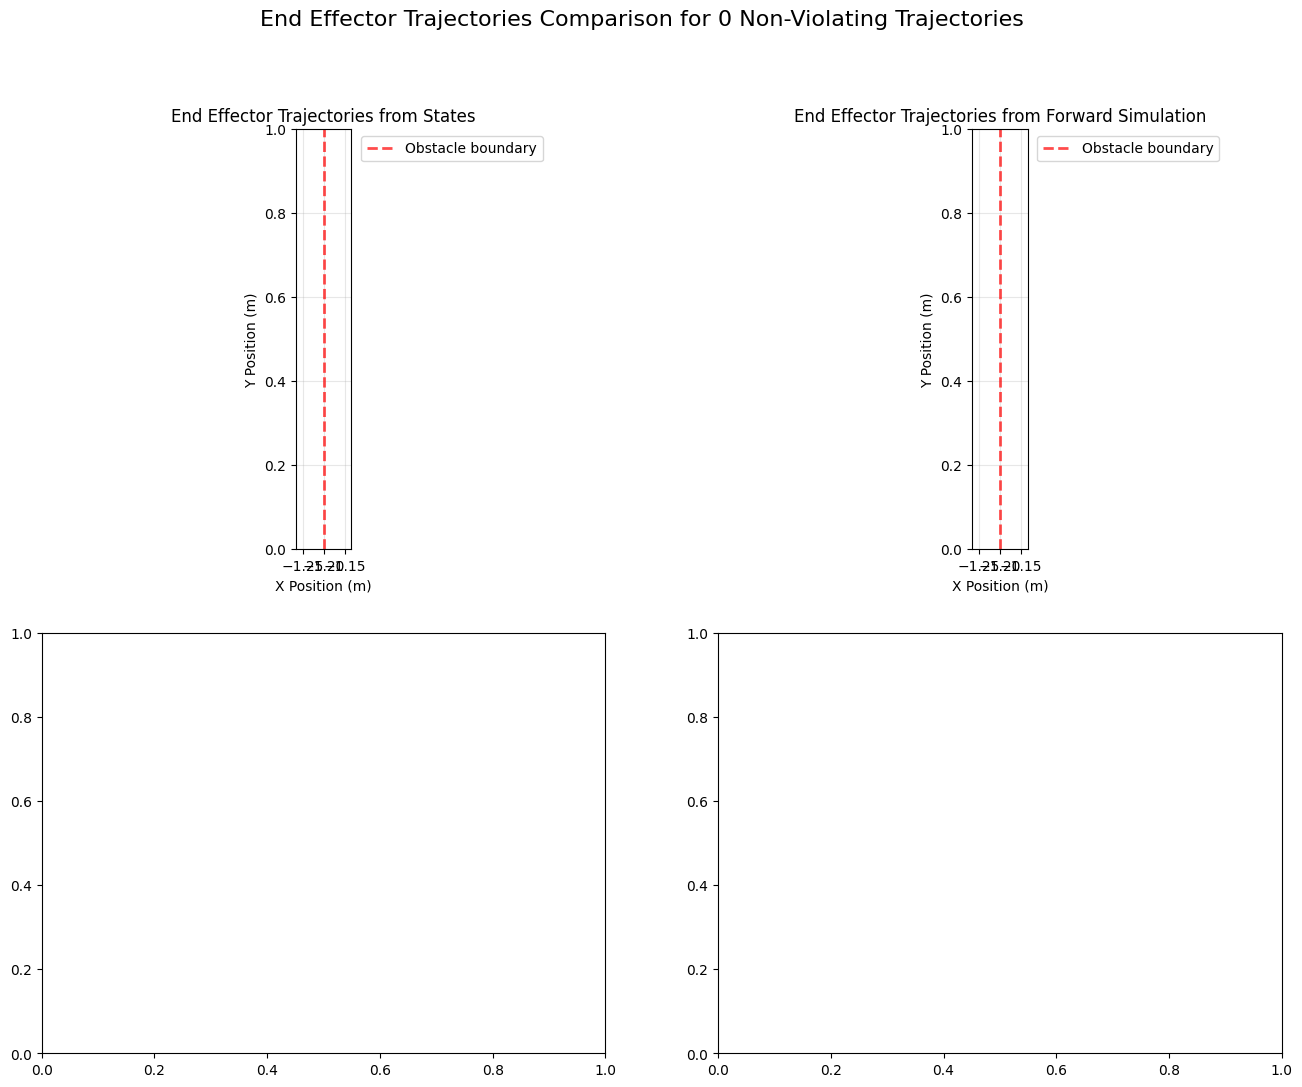

In [17]:
# Extract trajectories with no CBF violations and visualize 15 random ones
import numpy as np
import matplotlib.pyplot as plt
import random

# Extract non-violating trajectories (CBF violations = 0)
non_violating_indices = []
non_violating_trajectories = []

for i, opt_info in enumerate(batch_results['optimization_info']):
    if 'cbf_violations' in opt_info and opt_info['cbf_violations'] == 0:
        non_violating_indices.append(i)
        non_violating_trajectories.append(batch_results['corrected_trajectories'][i])

print(f"Total trajectories with no CBF violations: {len(non_violating_trajectories)}")
print(f"Non-violating trajectory indices: {non_violating_indices}")

# Randomly select 15 trajectories (or all if less than 15)
n_trajectories_to_plot = min(15, len(non_violating_trajectories))
if len(non_violating_trajectories) >= 15:
    selected_indices = random.sample(range(len(non_violating_trajectories)), 15)
else:
    selected_indices = list(range(len(non_violating_trajectories)))

selected_trajectory_indices = [non_violating_indices[i] for i in selected_indices]
print(f"Selected trajectory indices for visualization: {selected_trajectory_indices}")

# Initialize dynamics for forward simulation
dyn = DoublePendulumDynamics()

def forward_kinematics(state, l1=1.0, l2=1.0):
    """Calculate end effector position from state"""
    θ1, θ2 = state[0], state[1]
    x1 = l1 * np.sin(θ1)
    y1 = -l1 * np.cos(θ1)
    x2 = x1 + l2 * np.sin(θ2)
    y2 = y1 - l2 * np.cos(θ2)
    return np.array([x2, y2])

# Calculate end effector trajectories for selected trajectories
trajectory_data = []

for idx in selected_indices:
    traj = non_violating_trajectories[idx]
    original_idx = selected_trajectory_indices[selected_indices.index(idx)]
    
    states_corrected = traj['states_corrected']
    controls_corrected = traj['controls_corrected']
    
    # Method 1: Direct calculation from states
    ee_positions_from_states = []
    for state in states_corrected:
        ee_pos = forward_kinematics(state)
        ee_positions_from_states.append(ee_pos)
    ee_positions_from_states = np.array(ee_positions_from_states)
    
    # Method 2: Forward dynamics simulation from controls
    simulated_states = [states_corrected[0].copy()]  # Start from same initial state
    for t in range(len(controls_corrected) - 1):
        next_state = dyn.rk4_step(simulated_states[-1], controls_corrected[t], 0.1)
        simulated_states.append(next_state)
    simulated_states = np.array(simulated_states)
    
    ee_positions_from_simulation = []
    for state in simulated_states:
        ee_pos = forward_kinematics(state)
        ee_positions_from_simulation.append(ee_pos)
    ee_positions_from_simulation = np.array(ee_positions_from_simulation)
    
    trajectory_data.append({
        'original_index': original_idx,
        'ee_from_states': ee_positions_from_states,
        'ee_from_simulation': ee_positions_from_simulation,
        'states_corrected': states_corrected,
        'simulated_states': simulated_states
    })

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'End Effector Trajectories Comparison for {n_trajectories_to_plot} Non-Violating Trajectories', fontsize=16)

# Color map for different trajectories
colors = plt.cm.tab20(np.linspace(0, 1, n_trajectories_to_plot))

# Plot 1: End effector trajectories from states (X-Y plane)
ax = axes[0, 0]
for i, data in enumerate(trajectory_data):
    ee_pos = data['ee_from_states']
    ax.plot(ee_pos[:, 0], ee_pos[:, 1], color=colors[i], linewidth=2, alpha=0.8,
            label=f'Traj {data["original_index"]}' if i < 10 else '')
    ax.scatter(ee_pos[0, 0], ee_pos[0, 1], color=colors[i], s=50, marker='o', alpha=0.8)
    ax.scatter(ee_pos[-1, 0], ee_pos[-1, 1], color=colors[i], s=50, marker='*', alpha=0.8)

ax.axvline(x=-1.2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Obstacle boundary')
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('End Effector Trajectories from States')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Plot 2: End effector trajectories from forward simulation (X-Y plane)
ax = axes[0, 1]
for i, data in enumerate(trajectory_data):
    ee_pos = data['ee_from_simulation']
    ax.plot(ee_pos[:, 0], ee_pos[:, 1], color=colors[i], linewidth=2, alpha=0.8,
            label=f'Traj {data["original_index"]}' if i < 10 else '')
    ax.scatter(ee_pos[0, 0], ee_pos[0, 1], color=colors[i], s=50, marker='o', alpha=0.8)
    ax.scatter(ee_pos[-1, 0], ee_pos[-1, 1], color=colors[i], s=50, marker='*', alpha=0.8)

ax.axvline(x=-1.2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Obstacle boundary')
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('End Effector Trajectories from Forward Simulation')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Plot 3: X position over time comparison
ax = axes[1, 0]
time_steps = np.arange(len(trajectory_data[0]['ee_from_states'])) * 0.1
for i, data in enumerate(trajectory_data):
    ax.plot(time_steps, data['ee_from_states'][:, 0], color=colors[i], 
            linewidth=2, alpha=0.8, linestyle='-', label=f'States {data["original_index"]}' if i < 5 else '')
    ax.plot(time_steps, data['ee_from_simulation'][:, 0], color=colors[i], 
            linewidth=1, alpha=0.6, linestyle='--', label=f'Sim {data["original_index"]}' if i < 5 else '')

ax.axhline(y=-1.2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Safety boundary')
ax.set_xlabel('Time (s)')
ax.set_ylabel('X Position (m)')
ax.set_title('X Position Over Time: States vs Simulation')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Trajectory error analysis
ax = axes[1, 1]
trajectory_errors = []
trajectory_labels = []

for i, data in enumerate(trajectory_data):
    # Calculate position error between methods
    pos_error = np.linalg.norm(data['ee_from_states'] - data['ee_from_simulation'], axis=1)
    trajectory_errors.append(pos_error)
    trajectory_labels.append(f'Traj {data["original_index"]}')
    
    ax.plot(time_steps, pos_error, color=colors[i], linewidth=2, alpha=0.8,
            label=f'Traj {data["original_index"]}' if i < 10 else '')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Position Error (m)')
ax.set_title('End Effector Position Error: |States - Simulation|')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nTrajectory Analysis Results:")
print(f"Visualized trajectories: {len(trajectory_data)}")
print(f"Original trajectory indices: {[data['original_index'] for data in trajectory_data]}")

print(f"\nPosition Error Statistics:")
for i, data in enumerate(trajectory_data):
    pos_error = np.linalg.norm(data['ee_from_states'] - data['ee_from_simulation'], axis=1)
    print(f"Trajectory {data['original_index']}: "
          f"Max error = {np.max(pos_error):.6f}m, "
          f"Mean error = {np.mean(pos_error):.6f}m, "
          f"RMS error = {np.sqrt(np.mean(pos_error**2)):.6f}m")

# Calculate overall statistics
all_errors = []
for data in trajectory_data:
    pos_error = np.linalg.norm(data['ee_from_states'] - data['ee_from_simulation'], axis=1)
    all_errors.extend(pos_error)

print(f"\nOverall Statistics:")
print(f"Overall max error: {np.max(all_errors):.6f}m")
print(f"Overall mean error: {np.mean(all_errors):.6f}m")
print(f"Overall RMS error: {np.sqrt(np.mean(np.array(all_errors)**2)):.6f}m")

# Check for CBF violations in both methods
print(f"\nCBF Violation Check (x < -1.2):")
for i, data in enumerate(trajectory_data):
    violations_states = np.sum(data['ee_from_states'][:, 0] < -1.2)
    violations_sim = np.sum(data['ee_from_simulation'][:, 0] < -1.2)
    print(f"Trajectory {data['original_index']}: "
          f"States method = {violations_states} violations, "
          f"Simulation method = {violations_sim} violations")

In [1]:
# %%
# Sample 17 trajectories from Flow Matching model and plot end-effector trajectories
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchdiffeq
import random
import matplotlib as mpl
mpl.rc('text', usetex=True)
mpl.rc('text.latex', preamble=r'\usepackage{amsmath,amsfonts}')
mpl.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
mpl.rcParams.update({'font.size': 16})


# %%
# 1. Load checkpoint and recreate model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = 'mpc_pendulum_fm_best.pt'

print("Loading Flow Matching checkpoint...")
try:
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    print(f"Loaded checkpoint from epoch {ckpt['epoch']} with loss {ckpt['loss']:.6f}")
    
    # Restore scalers
    state_scaler = ckpt['state_scaler']
    control_scaler = ckpt['control_scaler']
    
    # Recreate model architecture (using transformer as in the original script)
    MODEL_TYPE = "transformer"
    
    if MODEL_TYPE == "unet":
        model = EfficientTemporalUNet(in_channels=6, base_channels=32)
    elif MODEL_TYPE == "mlp":
        model = TemporalMLP(in_channels=6, hidden_dim=256, num_layers=6)
    elif MODEL_TYPE == "transformer":
        model = SimpleFlowTransformer(in_channels=6, hidden_dim=128, num_heads=4, num_layers=4)
    
    # Wrap in fmtorch compatible model
    flow_model = MPCFlowModel(model).to(device)
    flow_model.load_state_dict(ckpt['model_state_dict'])
    flow_model.eval()
    
    print(f"Model loaded successfully ({MODEL_TYPE})")
    
except Exception as e:
    print(f"Error loading checkpoint: {e}")
    print("Cannot proceed without valid checkpoint")
    flow_model = None

# %%
# 2. Sample 17 trajectories using ODE solver
if flow_model is not None:
    print("Sampling 17 trajectories from Flow Matching model...")
    
    # Define ODE function for torchdiffeq
    def ode_func(t, x_flat):
        batch_size = 1
        x = x_flat.view(batch_size, 6, 100)
        t_tensor = torch.ones(batch_size, device=x.device) * t
        
        with torch.set_grad_enabled(False):
            v = flow_model(x, t_tensor)
        
        return v.view(-1)
    
    # Sample 17 trajectories
    fm_sampled_trajectories = []
    
    with torch.no_grad():
        for i in range(17):
            print(f"  Sampling trajectory {i+1}/17...", end=' ')
            
            # Random noise initialization
            x0_noise = torch.randn((1, 6, 100), device=device)
            
            # Time span for ODE integration
            t_span = torch.linspace(0, 1, 2, device=device)
            
            # Solve ODE using torchdiffeq
            traj = torchdiffeq.odeint(
                ode_func,
                x0_noise.view(-1),
                t_span,
                method='dopri5',
                atol=1e-5,
                rtol=1e-5
            )
            
            # Get final state and reshape
            x_final = traj[-1].view(6, 100).cpu().numpy()  # (6, 100)
            
            # Split and denormalize
            states_norm = x_final[:4, :].T    # (100, 4)
            controls_norm = x_final[4:, :].T   # (100, 2)
            
            states = state_scaler.denormalize(states_norm)
            controls = control_scaler.denormalize(controls_norm)
            
            fm_sampled_trajectories.append({
                'states': states,
                'controls': controls
            })
            
            print("✓")
    
    print(f"Successfully sampled {len(fm_sampled_trajectories)} trajectories")

else:
    print("Cannot sample trajectories without valid flow model")
    fm_sampled_trajectories = []

# %%
# 3. Calculate end-effector trajectories for sampled trajectories
if len(fm_sampled_trajectories) > 0:
    print("Calculating end-effector trajectories...")
    
    # Initialize dynamics for forward simulation
    dyn = DoublePendulumDynamics()
    
    def forward_kinematics(state, l1=1.0, l2=1.0):
        """Calculate end effector position from state"""
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    # Calculate end effector trajectories for each sampled trajectory
    fm_trajectory_data = []
    
    for i, traj in enumerate(fm_sampled_trajectories):
        states = traj['states']
        controls = traj['controls']
        
        # Method 1: Direct calculation from states
        ee_positions_from_states = []
        for state in states:
            ee_pos = forward_kinematics(state)
            ee_positions_from_states.append(ee_pos)
        ee_positions_from_states = np.array(ee_positions_from_states)
        
        # Method 2: Forward dynamics simulation from controls
        simulated_states = [states[0].copy()]  # Start from same initial state
        for t in range(len(controls) - 1):
            next_state = dyn.rk4_step(simulated_states[-1], controls[t], 0.1)
            simulated_states.append(next_state)
        simulated_states = np.array(simulated_states)
        
        ee_positions_from_simulation = []
        for state in simulated_states:
            ee_pos = forward_kinematics(state)
            ee_positions_from_simulation.append(ee_pos)
        ee_positions_from_simulation = np.array(ee_positions_from_simulation)
        
        fm_trajectory_data.append({
            'trajectory_index': i,
            'ee_from_states': ee_positions_from_states,
            'ee_from_simulation': ee_positions_from_simulation,
            'states_original': states,
            'simulated_states': simulated_states,
            'controls': controls
        })
    
    print(f"Calculated end-effector trajectories for {len(fm_trajectory_data)} trajectories")

# %%
# 4. Create visualization - matching robust annealing plot style
if len(fm_trajectory_data) > 0:
    print("Creating visualization...")
    
    # Create two separate single plots to match the robust annealing style
    
    # Plot 1: End effector trajectories from states (X-Y plane)
    fig1, ax1 = plt.subplots(1, 1, figsize=(12, 10))
    
    # 颜色映射 - matching the viridis colormap from robust annealing
    colors = plt.cm.tab20(np.linspace(0, 1, len(fm_trajectory_data)))
    
    # 绘制所有轨迹 - no labels, no markers to match the style
    for i, data in enumerate(fm_trajectory_data):
        ee_pos = data['ee_from_states']
        ax1.plot(ee_pos[:, 0], ee_pos[:, 1], 
                color=colors[i], linewidth=2, alpha=0.7)
    
    # 添加障碍物和约束 - same as robust annealing script
    x_min = -1.0
    ax1.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8, label='Barrier')
    ax1.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red', label='Forbidden Zone')
    
    # 设置图形属性 - matching the robust annealing style exactly
    ax1.set_xlabel('X Position (m)', fontsize=14)
    ax1.set_ylabel('Y Position (m)', fontsize=14)
    ax1.legend(fontsize=12, loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    ax1.set_xlim(-2.2, 2.2)
    ax1.set_ylim(-2.5, 2.5)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 2: End effector trajectories from forward simulation (X-Y plane)
    fig2, ax2 = plt.subplots(1, 1, figsize=(12, 10))
    
    # 绘制所有轨迹 - same style as states plot
    for i, data in enumerate(fm_trajectory_data):
        ee_pos = data['ee_from_simulation']
        ax2.plot(ee_pos[:, 0], ee_pos[:, 1], 
                color=colors[i], linewidth=2, alpha=0.7)
    
    # 添加障碍物和约束 - same as robust annealing script
    ax2.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8, label='Barrier')
    ax2.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red', label='Forbidden Zone')
    
    # 设置图形属性 - exact same as states plot
    ax2.set_xlabel('X Position (m)', fontsize=14)
    ax2.set_ylabel('Y Position (m)', fontsize=14)
    ax2.legend(fontsize=12, loc='upper right')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    ax2.set_xlim(-2.2, 2.2)
    ax2.set_ylim(-2.5, 2.5)
    
    plt.tight_layout()
    plt.show()
    
    # %%
    # 5. Print simplified statistics
    print(f"\nFlow Matching Trajectory Analysis Results:")
    print(f"Number of sampled trajectories: {len(fm_trajectory_data)}")
    
    # Calculate overall position error between states and simulation
    all_errors = []
    for data in fm_trajectory_data:
        pos_error = np.linalg.norm(data['ee_from_states'] - data['ee_from_simulation'], axis=1)
        all_errors.extend(pos_error)
    
    print(f"\nDynamics Consistency (States vs Simulation):")
    print(f"Overall mean error: {np.mean(all_errors):.6f}m")
    print(f"Overall max error: {np.max(all_errors):.6f}m")
    print(f"Overall RMS error: {np.sqrt(np.mean(np.array(all_errors)**2)):.6f}m")
    
    # Calculate final state errors (distance to inverted position)
    target_state = np.array([np.pi, np.pi, 0.0, 0.0])
    fm_success = 0
    sim_success = 0
    
    for data in fm_trajectory_data:
        final_state_fm = data['states_original'][-1]
        final_state_sim = data['simulated_states'][-1]
        
        error_fm = np.linalg.norm(final_state_fm - target_state)
        error_sim = np.linalg.norm(final_state_sim - target_state)
        
        if error_fm < 0.2:
            fm_success += 1
        if error_sim < 0.2:
            sim_success += 1
    
    print(f"\nInversion Success Rate (error < 0.2):")
    print(f"FM states method: {fm_success}/{len(fm_trajectory_data)} ({fm_success/len(fm_trajectory_data)*100:.1f}%)")
    print(f"Simulation method: {sim_success}/{len(fm_trajectory_data)} ({sim_success/len(fm_trajectory_data)*100:.1f}%)")
    
    print(f"\nFlow Matching trajectory sampling and analysis completed!")

    # %%
    # 6. Additional visualization - Project violating points to safe region
    print("Creating additional visualization with projected safe trajectories...")
    
    # Create projected trajectories for states-based end effector positions
    projected_trajectory_data = []
    
    for data in fm_trajectory_data:
        ee_from_states = data['ee_from_states'].copy()
        ee_from_simulation = data['ee_from_simulation'].copy()  # Keep unchanged
        
        # Project violating points (x < -1.0) to closest safe region (x = -1.0)
        ee_projected = ee_from_states.copy()
        violating_mask = ee_projected[:, 0] < x_min
        ee_projected[violating_mask, 0] = x_min  # Project x to barrier position, keep y unchanged
        
        projected_trajectory_data.append({
            'trajectory_index': data['trajectory_index'],
            'ee_projected_states': ee_projected,
            'ee_from_simulation': ee_from_simulation,
            'violation_count': np.sum(violating_mask)
        })
    
    # Plot 3: Projected states vs original simulation trajectories
    fig3, ax3 = plt.subplots(1, 1, figsize=(12, 10))
    ax3.plot(0, 0, marker='o', markersize=8, color='black')
    ax3.set_xlabel(r'$x$', fontsize=20)

    ax3.set_ylabel(r'$y$', fontsize=20)
    # Plot projected states trajectories
    for i, data in enumerate(projected_trajectory_data):
        ee_pos = data['ee_projected_states']
        ax3.plot(ee_pos[:, 0], ee_pos[:, 1], 
                color=colors[i], linewidth=2, alpha=0.7)
    
    # 添加障碍物和约束
    ax3.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8, label='Barrier')
    ax3.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red', label='Forbidden Zone')
    
    # 设置图形属性
    # ax3.set_xlabel('X Position (m)', fontsize=14)
    # ax3.set_ylabel('Y Position (m)', fontsize=14)
    #ax3.legend(fontsize=12, loc='upper right')
    ax3.grid(True, alpha=0.3)
    ax3.set_aspect('equal')
    ax3.set_xlim(-2.2, 2.2)
    ax3.set_ylim(-2.5, 2.5)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 4: Original simulation trajectories (unchanged)
    fig4, ax4 = plt.subplots(1, 1, figsize=(12, 10))
    
    # Plot original simulation trajectories
    for i, data in enumerate(projected_trajectory_data):
        ee_pos = data['ee_from_simulation']
        ax4.plot(ee_pos[:, 0], ee_pos[:, 1], 
                color=colors[i], linewidth=2, alpha=0.7)
    
    # 添加障碍物和约束
    ax4.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8, label='Barrier')
    ax4.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red', label='Forbidden Zone')
    
    # 设置图形属性
    # ax4.set_xlabel('X Position (m)', fontsize=14)
    # ax4.set_ylabel('Y Position (m)', fontsize=14)
    ax4.set_xlabel(r'$x$', fontsize=20)
    #ax.set_ylabel('Y Position (m)', fontsize=14)
    ax4.set_ylabel(r'$y$', fontsize=20)
    ax4.plot(0, 0, marker='o', markersize=8, color='black')
    
    #ax4.legend(fontsize=12, loc='upper right')
    ax4.grid(True, alpha=0.3)
    ax4.set_aspect('equal')
    ax4.set_xlim(-2.2, 2.2)
    ax4.set_ylim(-2.5, 2.5)
    
    plt.tight_layout()
    plt.show()
    
    # Print violation statistics
    total_violations = sum(data['violation_count'] for data in projected_trajectory_data)
    trajectories_with_violations = sum(1 for data in projected_trajectory_data if data['violation_count'] > 0)
    
    print(f"\nBarrier Violation Analysis:")
    print(f"Total violation points across all trajectories: {total_violations}")
    print(f"Trajectories with violations: {trajectories_with_violations}/{len(projected_trajectory_data)}")
    if trajectories_with_violations > 0:
        avg_violations_per_violating_traj = total_violations / trajectories_with_violations
        print(f"Average violations per violating trajectory: {avg_violations_per_violating_traj:.1f}")
    
    print(f"\nProjected trajectory visualization completed!")

else:
    print("No trajectories to analyze - please check checkpoint loading and sampling process")

Loading Flow Matching checkpoint...
Error loading checkpoint: Can't get attribute 'Scaler' on <module '__main__'>
Cannot proceed without valid checkpoint
Cannot sample trajectories without valid flow model


NameError: name 'fm_trajectory_data' is not defined

Loading Flow Matching checkpoint...
Loaded checkpoint from epoch 889 with loss 0.019273
Model loaded successfully (transformer)
Sampling 17 trajectories from Flow Matching model...
  Sampling trajectory 1/17... ✓
  Sampling trajectory 2/17... ✓
  Sampling trajectory 3/17... ✓
  Sampling trajectory 4/17... ✓
  Sampling trajectory 5/17... ✓
  Sampling trajectory 6/17... ✓
  Sampling trajectory 7/17... ✓
  Sampling trajectory 8/17... ✓
  Sampling trajectory 9/17... ✓
  Sampling trajectory 10/17... ✓
  Sampling trajectory 11/17... ✓
  Sampling trajectory 12/17... ✓
  Sampling trajectory 13/17... ✓
  Sampling trajectory 14/17... ✓
  Sampling trajectory 15/17... ✓
  Sampling trajectory 16/17... ✓
  Sampling trajectory 17/17... ✓
Successfully sampled 17 trajectories
Calculating end-effector trajectories...
Calculated end-effector trajectories for 17 trajectories
Creating visualization...


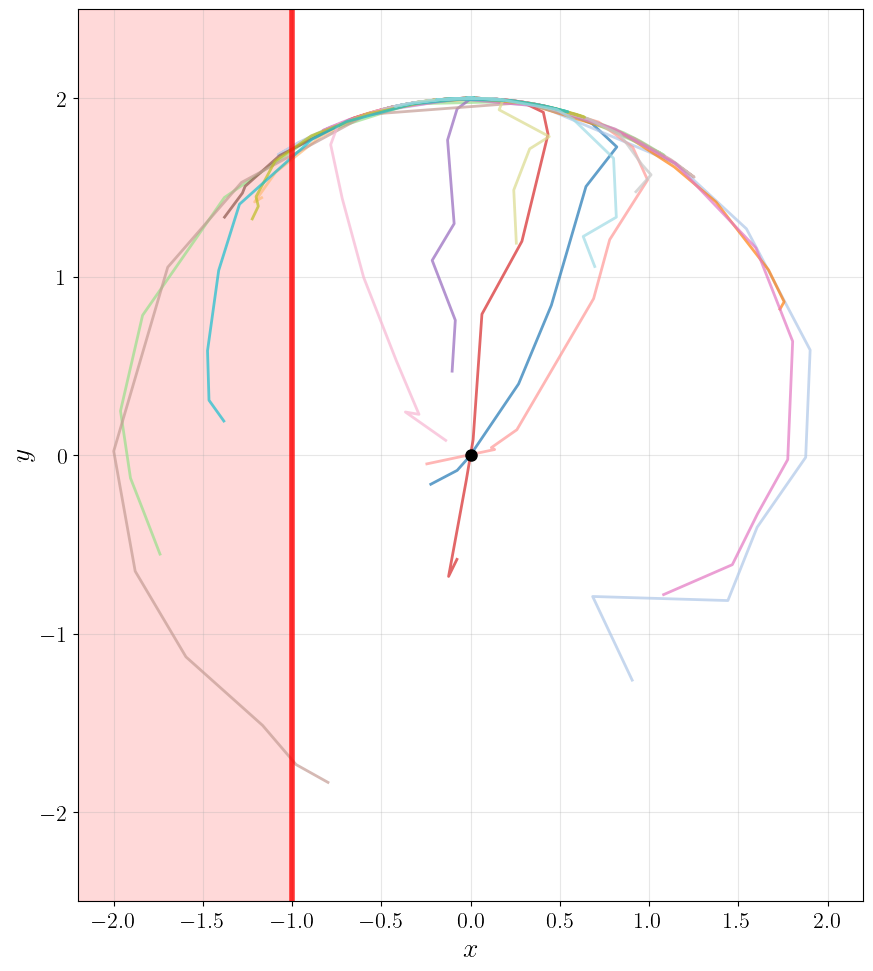

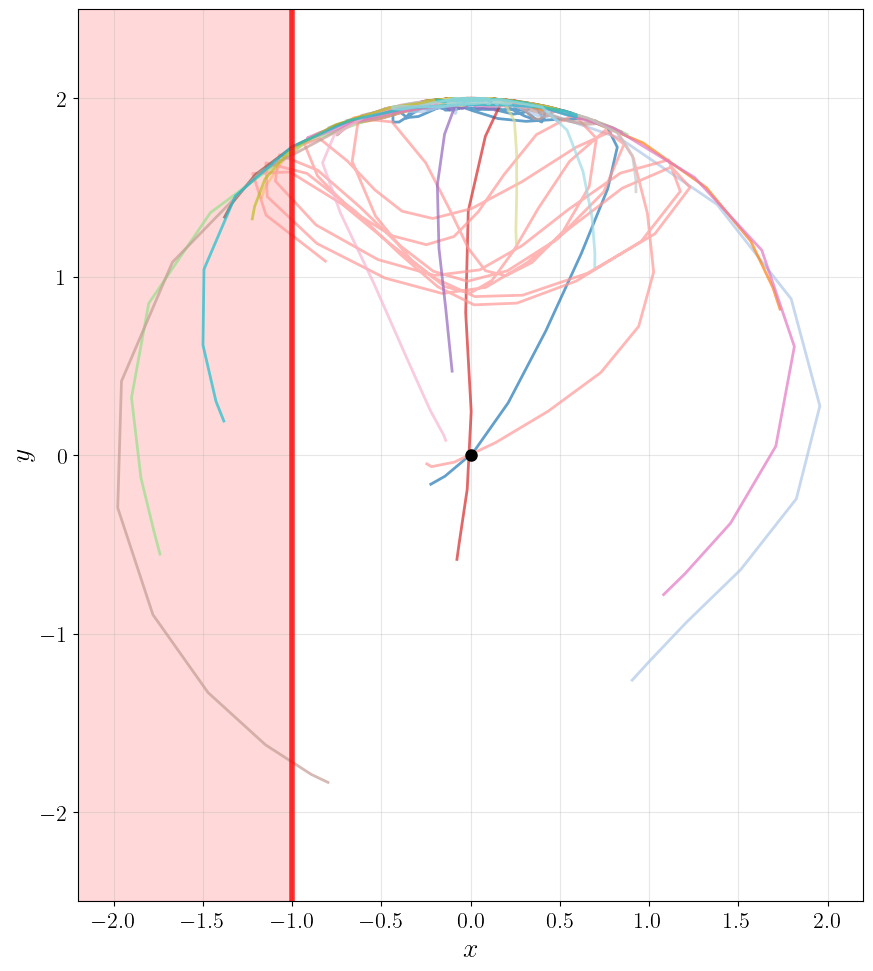


Flow Matching Trajectory Analysis Results:
Number of sampled trajectories: 17

Dynamics Consistency (States vs Simulation):
Overall mean error: 0.184796m
Overall max error: 1.333175m
Overall RMS error: 0.294697m

Inversion Success Rate (error < 0.2):
FM states method: 17/17 (100.0%)
Simulation method: 0/17 (0.0%)

Flow Matching trajectory sampling and analysis completed!


In [20]:
# %%
# Sample 17 trajectories from Flow Matching model and plot end-effector trajectories
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchdiffeq
import random
import matplotlib as mpl
mpl.rc('text', usetex=True)
mpl.rc('text.latex', preamble=r'\usepackage{amsmath,amsfonts}')
mpl.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
mpl.rcParams.update({'font.size': 16})

# %%
# 1. Load checkpoint and recreate model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = 'mpc_pendulum_fm_best.pt'

print("Loading Flow Matching checkpoint...")
try:
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    print(f"Loaded checkpoint from epoch {ckpt['epoch']} with loss {ckpt['loss']:.6f}")
    
    # Restore scalers
    state_scaler = ckpt['state_scaler']
    control_scaler = ckpt['control_scaler']
    
    # Recreate model architecture (using transformer as in the original script)
    MODEL_TYPE = "transformer"
    
    if MODEL_TYPE == "unet":
        model = EfficientTemporalUNet(in_channels=6, base_channels=32)
    elif MODEL_TYPE == "mlp":
        model = TemporalMLP(in_channels=6, hidden_dim=256, num_layers=6)
    elif MODEL_TYPE == "transformer":
        model = SimpleFlowTransformer(in_channels=6, hidden_dim=128, num_heads=4, num_layers=4)
    
    # Wrap in fmtorch compatible model
    flow_model = MPCFlowModel(model).to(device)
    flow_model.load_state_dict(ckpt['model_state_dict'])
    flow_model.eval()
    
    print(f"Model loaded successfully ({MODEL_TYPE})")
    
except Exception as e:
    print(f"Error loading checkpoint: {e}")
    print("Cannot proceed without valid checkpoint")
    flow_model = None

# %%
# 2. Sample 17 trajectories using ODE solver
if flow_model is not None:
    print("Sampling 17 trajectories from Flow Matching model...")
    
    # Define ODE function for torchdiffeq
    def ode_func(t, x_flat):
        batch_size = 1
        x = x_flat.view(batch_size, 6, 100)
        t_tensor = torch.ones(batch_size, device=x.device) * t
        
        with torch.set_grad_enabled(False):
            v = flow_model(x, t_tensor)
        
        return v.view(-1)
    
    # Sample 17 trajectories
    fm_sampled_trajectories = []
    
    with torch.no_grad():
        for i in range(17):
            print(f"  Sampling trajectory {i+1}/17...", end=' ')
            
            # Random noise initialization
            x0_noise = torch.randn((1, 6, 100), device=device)
            
            # Time span for ODE integration
            t_span = torch.linspace(0, 1, 2, device=device)
            
            # Solve ODE using torchdiffeq
            traj = torchdiffeq.odeint(
                ode_func,
                x0_noise.view(-1),
                t_span,
                method='dopri5',
                atol=1e-5,
                rtol=1e-5
            )
            
            # Get final state and reshape
            x_final = traj[-1].view(6, 100).cpu().numpy()  # (6, 100)
            
            # Split and denormalize
            states_norm = x_final[:4, :].T    # (100, 4)
            controls_norm = x_final[4:, :].T   # (100, 2)
            
            states = state_scaler.denormalize(states_norm)
            controls = control_scaler.denormalize(controls_norm)
            
            fm_sampled_trajectories.append({
                'states': states,
                'controls': controls
            })
            
            print("✓")
    
    print(f"Successfully sampled {len(fm_sampled_trajectories)} trajectories")

else:
    print("Cannot sample trajectories without valid flow model")
    fm_sampled_trajectories = []

# %%
# 3. Calculate end-effector trajectories for sampled trajectories
if len(fm_sampled_trajectories) > 0:
    print("Calculating end-effector trajectories...")
    
    # Initialize dynamics for forward simulation
    dyn = DoublePendulumDynamics()
    
    def forward_kinematics(state, l1=1.0, l2=1.0):
        """Calculate end effector position from state"""
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    # Calculate end effector trajectories for each sampled trajectory
    fm_trajectory_data = []
    
    for i, traj in enumerate(fm_sampled_trajectories):
        states = traj['states']
        controls = traj['controls']
        
        # Method 1: Direct calculation from states
        ee_positions_from_states = []
        for state in states:
            ee_pos = forward_kinematics(state)
            ee_positions_from_states.append(ee_pos)
        ee_positions_from_states = np.array(ee_positions_from_states)
        
        # Method 2: Forward dynamics simulation from controls
        simulated_states = [states[0].copy()]  # Start from same initial state
        for t in range(len(controls) - 1):
            next_state = dyn.rk4_step(simulated_states[-1], controls[t], 0.1)
            simulated_states.append(next_state)
        simulated_states = np.array(simulated_states)
        
        ee_positions_from_simulation = []
        for state in simulated_states:
            ee_pos = forward_kinematics(state)
            ee_positions_from_simulation.append(ee_pos)
        ee_positions_from_simulation = np.array(ee_positions_from_simulation)
        
        fm_trajectory_data.append({
            'trajectory_index': i,
            'ee_from_states': ee_positions_from_states,
            'ee_from_simulation': ee_positions_from_simulation,
            'states_original': states,
            'simulated_states': simulated_states,
            'controls': controls
        })
    
    print(f"Calculated end-effector trajectories for {len(fm_trajectory_data)} trajectories")

# %%
# 4. Create visualization - matching robust annealing plot style
if len(fm_trajectory_data) > 0:
    print("Creating visualization...")
    
    # Create two separate single plots to match the robust annealing style
    
    # Plot 1: End effector trajectories from states (X-Y plane)
    fig1, ax1 = plt.subplots(1, 1, figsize=(12, 10))
    
    # 颜色映射 - matching the viridis colormap from robust annealing
    colors = plt.cm.tab20(np.linspace(0, 1, len(fm_trajectory_data)))
    
    # 绘制所有轨迹 - no labels, no markers to match the style
    for i, data in enumerate(fm_trajectory_data):
        ee_pos = data['ee_from_states']
        ax1.plot(ee_pos[:, 0], ee_pos[:, 1], 
                color=colors[i], linewidth=2, alpha=0.7)
    
    # 添加障碍物和约束 - same as robust annealing script
    x_min = -1.0
    ax1.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8, label='Barrier')
    ax1.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red', label='Forbidden Zone')
    ax1.plot(0, 0, marker='o', markersize=8, color='black')
    # 设置图形属性 - matching the robust annealing style exactly
    # ax1.set_xlabel('X Position (m)', fontsize=14)
    # ax1.set_ylabel('Y Position (m)', fontsize=14)
    ax1.set_xlabel(r'$x$', fontsize=20)
    ax1.set_ylabel(r'$y$', fontsize=20)
    #ax1.legend(fontsize=12, loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    ax1.set_xlim(-2.2, 2.2)
    ax1.set_ylim(-2.5, 2.5)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 2: End effector trajectories from forward simulation (X-Y plane)
    fig2, ax2 = plt.subplots(1, 1, figsize=(12, 10))
    
    # 绘制所有轨迹 - same style as states plot
    for i, data in enumerate(fm_trajectory_data):
        ee_pos = data['ee_from_simulation']
        ax2.plot(ee_pos[:, 0], ee_pos[:, 1], 
                color=colors[i], linewidth=2, alpha=0.7)
    
    # 添加障碍物和约束 - same as robust annealing script
    ax2.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8, label='Barrier')
    ax2.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red', label='Forbidden Zone')
    
    # 设置图形属性 - exact same as states plot
    #ax2.set_xlabel('X Position (m)', fontsize=14)
    #ax2.set_ylabel('Y Position (m)', fontsize=14)
    ax2.set_xlabel(r'$x$', fontsize=20)
    ax2.set_ylabel(r'$y$', fontsize=20)
    #ax2.legend(fontsize=12, loc='upper right')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    ax2.set_xlim(-2.2, 2.2)
    ax2.set_ylim(-2.5, 2.5)
    ax2.plot(0, 0, marker='o', markersize=8, color='black')
    plt.tight_layout()
    plt.show()
    
    # %%
    # 5. Print simplified statistics
    print(f"\nFlow Matching Trajectory Analysis Results:")
    print(f"Number of sampled trajectories: {len(fm_trajectory_data)}")
    
    # Calculate overall position error between states and simulation
    all_errors = []
    for data in fm_trajectory_data:
        pos_error = np.linalg.norm(data['ee_from_states'] - data['ee_from_simulation'], axis=1)
        all_errors.extend(pos_error)
    
    print(f"\nDynamics Consistency (States vs Simulation):")
    print(f"Overall mean error: {np.mean(all_errors):.6f}m")
    print(f"Overall max error: {np.max(all_errors):.6f}m")
    print(f"Overall RMS error: {np.sqrt(np.mean(np.array(all_errors)**2)):.6f}m")
    
    # Calculate final state errors (distance to inverted position)
    target_state = np.array([np.pi, np.pi, 0.0, 0.0])
    fm_success = 0
    sim_success = 0
    
    for data in fm_trajectory_data:
        final_state_fm = data['states_original'][-1]
        final_state_sim = data['simulated_states'][-1]
        
        error_fm = np.linalg.norm(final_state_fm - target_state)
        error_sim = np.linalg.norm(final_state_sim - target_state)
        
        if error_fm < 0.2:
            fm_success += 1
        if error_sim < 0.2:
            sim_success += 1
    
    print(f"\nInversion Success Rate (error < 0.2):")
    print(f"FM states method: {fm_success}/{len(fm_trajectory_data)} ({fm_success/len(fm_trajectory_data)*100:.1f}%)")
    print(f"Simulation method: {sim_success}/{len(fm_trajectory_data)} ({sim_success/len(fm_trajectory_data)*100:.1f}%)")
    
    print(f"\nFlow Matching trajectory sampling and analysis completed!")

else:
    print("No trajectories to analyze - please check checkpoint loading and sampling process")

In [14]:
import torch
import numpy as np
import torchdiffeq
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from datetime import datetime

class EndEffectorRMSEEvaluator:
    """
    Comprehensive evaluator for end effector RMSE comparison between
    Flow Matching (FM) and FM with CBF correction
    """
    
    def __init__(self, flow_model, state_scaler, control_scaler, dynamics, device='cpu'):
        self.flow_model = flow_model
        self.state_scaler = state_scaler
        self.control_scaler = control_scaler
        self.dyn = dynamics
        self.device = device
        
    def forward_kinematics(self, state, l1=1.0, l2=1.0):
        """Calculate end effector position from joint state"""
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def ode_func(self, t, x_flat):
        """ODE function for Flow Matching trajectory generation"""
        batch_size = 1
        x = x_flat.view(batch_size, 6, 100)
        t_tensor = torch.ones(batch_size, device=x.device) * t
        
        with torch.set_grad_enabled(False):
            v = self.flow_model(x, t_tensor)
        
        return v.view(-1)
    
    def sample_fm_trajectory(self):
        """Sample a single trajectory from Flow Matching model"""
        with torch.no_grad():
            # Random noise initialization
            x0_noise = torch.randn((1, 6, 100), device=self.device)
            
            # Time span for ODE integration
            t_span = torch.linspace(0, 1, 2, device=self.device)
            
            # Solve ODE using torchdiffeq
            traj = torchdiffeq.odeint(
                self.ode_func,
                x0_noise.view(-1),
                t_span,
                method='dopri5',
                atol=1e-5,
                rtol=1e-5
            )
            
            # Get final state and reshape
            x_final = traj[-1].view(6, 100).cpu().numpy()  # (6, 100)
            
            # Split and denormalize
            states_norm = x_final[:4, :].T    # (100, 4)
            controls_norm = x_final[4:, :].T   # (100, 2)
            
            states = self.state_scaler.denormalize(states_norm)
            controls = self.control_scaler.denormalize(controls_norm)
            
            return states, controls
    
    def compute_trajectory_rmse(self, states, controls):
        """
        Compute end effector RMSE between states and simulated states
        
        Returns:
        - ee_rmse: End effector RMSE
        - ee_positions_states: End effector positions from states
        - ee_positions_sim: End effector positions from simulation
        - simulated_states: Simulated states
        """
        # Method 1: End effector positions from given states
        ee_positions_states = []
        for state in states:
            ee_pos = self.forward_kinematics(state)
            ee_positions_states.append(ee_pos)
        ee_positions_states = np.array(ee_positions_states)
        
        # Method 2: Forward dynamics simulation from controls
        simulated_states = [states[0].copy()]  # Start from same initial state
        for t in range(len(controls) - 1):
            next_state = self.dyn.rk4_step(simulated_states[-1], controls[t], 0.1)
            simulated_states.append(next_state)
        simulated_states = np.array(simulated_states)
        
        # End effector positions from simulated states
        ee_positions_sim = []
        for state in simulated_states:
            ee_pos = self.forward_kinematics(state)
            ee_positions_sim.append(ee_pos)
        ee_positions_sim = np.array(ee_positions_sim)
        
        # Compute RMSE
        ee_errors = np.linalg.norm(ee_positions_states - ee_positions_sim, axis=1)
        ee_rmse = np.sqrt(np.mean(ee_errors**2))
        
        return ee_rmse, ee_positions_states, ee_positions_sim, simulated_states
    
    def evaluate_fm_trajectories(self, n_trajectories=1000, verbose=True):
        """Evaluate RMSE for pure Flow Matching trajectories"""
        
        if verbose:
            print(f"Evaluating {n_trajectories} Flow Matching trajectories...")
        
        results = {
            'trajectory_rmses': [],
            'trajectory_data': [],
            'n_trajectories': n_trajectories,
            'method': 'Flow Matching',
            'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S")
        }
        
        successful_trajectories = 0
        
        # Use tqdm for progress bar
        for i in tqdm(range(n_trajectories), desc="Sampling FM trajectories"):
            try:
                # Sample trajectory
                states, controls = self.sample_fm_trajectory()
                
                # Compute RMSE
                ee_rmse, ee_states, ee_sim, sim_states = self.compute_trajectory_rmse(states, controls)
                
                # Store results
                results['trajectory_rmses'].append(ee_rmse)
                results['trajectory_data'].append({
                    'trajectory_id': i,
                    'states': states,
                    'controls': controls,
                    'simulated_states': sim_states,
                    'ee_positions_states': ee_states,
                    'ee_positions_sim': ee_sim,
                    'ee_rmse': ee_rmse
                })
                
                successful_trajectories += 1
                
            except Exception as e:
                if verbose and i < 10:  # Only print first few errors
                    print(f"Error sampling trajectory {i}: {str(e)}")
                continue
        
        # Compute statistics
        rmses = np.array(results['trajectory_rmses'])
        
        results['statistics'] = {
            'successful_trajectories': successful_trajectories,
            'success_rate': successful_trajectories / n_trajectories,
            'mean_rmse': np.mean(rmses),
            'std_rmse': np.std(rmses),
            'median_rmse': np.median(rmses),
            'min_rmse': np.min(rmses),
            'max_rmse': np.max(rmses),
            'percentile_95': np.percentile(rmses, 95),
            'percentile_99': np.percentile(rmses, 99)
        }
        
        if verbose:
            self.print_statistics(results['statistics'], "Flow Matching")
        
        return results
    
    def evaluate_cbf_trajectories(self, cbf_trajectory_data, verbose=True):
        """Evaluate RMSE for CBF-corrected trajectories"""
        
        if verbose:
            print(f"Evaluating {len(cbf_trajectory_data)} CBF-corrected trajectories...")
        
        results = {
            'trajectory_rmses': [],
            'trajectory_data': [],
            'n_trajectories': len(cbf_trajectory_data),
            'method': 'Flow Matching + CBF',
            'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S")
        }
        
        successful_trajectories = 0
        
        # Use tqdm for progress bar
        for i, traj_data in enumerate(tqdm(cbf_trajectory_data, desc="Evaluating CBF trajectories")):
            try:
                # Extract corrected states and controls
                if 'states_corrected' in traj_data and 'controls_corrected' in traj_data:
                    states = traj_data['states_corrected']
                    controls = traj_data['controls_corrected']
                elif 'corrected_states' in traj_data and 'corrected_controls' in traj_data:
                    states = traj_data['corrected_states']
                    controls = traj_data['corrected_controls']
                else:
                    if verbose and i < 10:
                        print(f"Trajectory {i}: Unable to find corrected states/controls")
                    continue
                
                # Compute RMSE
                ee_rmse, ee_states, ee_sim, sim_states = self.compute_trajectory_rmse(states, controls)
                
                # Store results
                results['trajectory_rmses'].append(ee_rmse)
                results['trajectory_data'].append({
                    'trajectory_id': i,
                    'states': states,
                    'controls': controls,
                    'simulated_states': sim_states,
                    'ee_positions_states': ee_states,
                    'ee_positions_sim': ee_sim,
                    'ee_rmse': ee_rmse
                })
                
                successful_trajectories += 1
                
            except Exception as e:
                if verbose and i < 10:  # Only print first few errors
                    print(f"Error evaluating CBF trajectory {i}: {str(e)}")
                continue
        
        # Compute statistics
        rmses = np.array(results['trajectory_rmses'])
        
        results['statistics'] = {
            'successful_trajectories': successful_trajectories,
            'success_rate': successful_trajectories / len(cbf_trajectory_data),
            'mean_rmse': np.mean(rmses),
            'std_rmse': np.std(rmses),
            'median_rmse': np.median(rmses),
            'min_rmse': np.min(rmses),
            'max_rmse': np.max(rmses),
            'percentile_95': np.percentile(rmses, 95),
            'percentile_99': np.percentile(rmses, 99)
        }
        
        if verbose:
            self.print_statistics(results['statistics'], "Flow Matching + CBF")
        
        return results
    
    def print_statistics(self, stats, method_name):
        """Print evaluation statistics"""
        print(f"\n{method_name} Results:")
        print("=" * 50)
        print(f"Successful trajectories: {stats['successful_trajectories']}")
        print(f"Success rate: {stats['success_rate']:.3f}")
        print(f"Mean RMSE: {stats['mean_rmse']:.6f}")
        print(f"Std RMSE: {stats['std_rmse']:.6f}")
        print(f"Median RMSE: {stats['median_rmse']:.6f}")
        print(f"Min RMSE: {stats['min_rmse']:.6f}")
        print(f"Max RMSE: {stats['max_rmse']:.6f}")
        print(f"95th percentile: {stats['percentile_95']:.6f}")
        print(f"99th percentile: {stats['percentile_99']:.6f}")
    
    def compare_methods(self, fm_results, cbf_results):
        """Compare FM and CBF results"""
        print(f"\n" + "="*60)
        print("COMPARISON: Flow Matching vs Flow Matching + CBF")
        print("="*60)
        
        fm_stats = fm_results['statistics']
        cbf_stats = cbf_results['statistics']
        
        # RMSE comparison
        print(f"\nRMSE Comparison:")
        print(f"{'Metric':<20} {'FM':<15} {'FM+CBF':<15} {'Improvement':<15}")
        print("-" * 65)
        
        mean_improvement = (fm_stats['mean_rmse'] - cbf_stats['mean_rmse']) / fm_stats['mean_rmse'] * 100
        median_improvement = (fm_stats['median_rmse'] - cbf_stats['median_rmse']) / fm_stats['median_rmse'] * 100
        
        print(f"{'Mean RMSE':<20} {fm_stats['mean_rmse']:<15.6f} {cbf_stats['mean_rmse']:<15.6f} {mean_improvement:<15.2f}%")
        print(f"{'Median RMSE':<20} {fm_stats['median_rmse']:<15.6f} {cbf_stats['median_rmse']:<15.6f} {median_improvement:<15.2f}%")
        print(f"{'Std RMSE':<20} {fm_stats['std_rmse']:<15.6f} {cbf_stats['std_rmse']:<15.6f}")
        print(f"{'Max RMSE':<20} {fm_stats['max_rmse']:<15.6f} {cbf_stats['max_rmse']:<15.6f}")
        print(f"{'95th percentile':<20} {fm_stats['percentile_95']:<15.6f} {cbf_stats['percentile_95']:<15.6f}")
        
        # Statistical significance test (Wilcoxon rank-sum test)
        from scipy.stats import ranksums
        try:
            fm_rmses = np.array(fm_results['trajectory_rmses'])
            cbf_rmses = np.array(cbf_results['trajectory_rmses'])
            
            statistic, p_value = ranksums(fm_rmses, cbf_rmses)
            print(f"\nStatistical Test (Wilcoxon rank-sum):")
            print(f"Statistic: {statistic:.4f}")
            print(f"P-value: {p_value:.2e}")
            print(f"Significant improvement: {'Yes' if p_value < 0.05 else 'No'}")
            
        except Exception as e:
            print(f"Statistical test failed: {e}")
    
    def visualize_results(self, fm_results, cbf_results):
        """Create visualization comparing FM and CBF results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('End Effector RMSE Comparison: FM vs FM+CBF', fontsize=16)
        
        fm_rmses = np.array(fm_results['trajectory_rmses'])
        cbf_rmses = np.array(cbf_results['trajectory_rmses'])
        
        # Plot 1: RMSE histograms
        ax = axes[0, 0]
        bins = np.logspace(np.log10(min(fm_rmses.min(), cbf_rmses.min())), 
                          np.log10(max(fm_rmses.max(), cbf_rmses.max())), 50)
        ax.hist(fm_rmses, bins=bins, alpha=0.7, label='FM', density=True)
        ax.hist(cbf_rmses, bins=bins, alpha=0.7, label='FM+CBF', density=True)
        ax.set_xscale('log')
        ax.set_xlabel('End Effector RMSE')
        ax.set_ylabel('Density')
        ax.set_title('RMSE Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 2: Box plot
        ax = axes[0, 1]
        ax.boxplot([fm_rmses, cbf_rmses], labels=['FM', 'FM+CBF'])
        ax.set_yscale('log')
        ax.set_ylabel('End Effector RMSE')
        ax.set_title('RMSE Box Plot')
        ax.grid(True, alpha=0.3)
        
        # Plot 3: Cumulative distribution
        ax = axes[1, 0]
        fm_sorted = np.sort(fm_rmses)
        cbf_sorted = np.sort(cbf_rmses)
        fm_cdf = np.arange(1, len(fm_sorted) + 1) / len(fm_sorted)
        cbf_cdf = np.arange(1, len(cbf_sorted) + 1) / len(cbf_sorted)
        
        ax.plot(fm_sorted, fm_cdf, label='FM', linewidth=2)
        ax.plot(cbf_sorted, cbf_cdf, label='FM+CBF', linewidth=2)
        ax.set_xscale('log')
        ax.set_xlabel('End Effector RMSE')
        ax.set_ylabel('Cumulative Probability')
        ax.set_title('Cumulative Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 4: Summary statistics
        ax = axes[1, 1]
        ax.axis('off')
        
        # Create summary table
        summary_text = f"""Summary Statistics:

FM (n={len(fm_rmses)}):
  Mean:    {fm_results['statistics']['mean_rmse']:.6f}
  Median:  {fm_results['statistics']['median_rmse']:.6f}
  Std:     {fm_results['statistics']['std_rmse']:.6f}
  95th:    {fm_results['statistics']['percentile_95']:.6f}

FM+CBF (n={len(cbf_rmses)}):
  Mean:    {cbf_results['statistics']['mean_rmse']:.6f}
  Median:  {cbf_results['statistics']['median_rmse']:.6f}
  Std:     {cbf_results['statistics']['std_rmse']:.6f}
  95th:    {cbf_results['statistics']['percentile_95']:.6f}

Improvement:
  Mean:    {(fm_results['statistics']['mean_rmse'] - cbf_results['statistics']['mean_rmse']) / fm_results['statistics']['mean_rmse'] * 100:.2f}%
  Median:  {(fm_results['statistics']['median_rmse'] - cbf_results['statistics']['median_rmse']) / fm_results['statistics']['median_rmse'] * 100:.2f}%
"""
        
        ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        return fig


def run_comprehensive_evaluation():
    """
    Main function to run comprehensive RMSE evaluation
    """
    print("Starting Comprehensive End Effector RMSE Evaluation")
    print("=" * 60)
    
    # Check if required components are available
    try:
        # Load Flow Matching model
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        checkpoint_path = 'mpc_pendulum_fm_best.pt'
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        
        state_scaler = ckpt['state_scaler']
        control_scaler = ckpt['control_scaler']
        
        # Recreate model
        model = SimpleFlowTransformer(in_channels=6, hidden_dim=128, num_heads=4, num_layers=4)
        flow_model = MPCFlowModel(model).to(device)
        flow_model.load_state_dict(ckpt['model_state_dict'])
        flow_model.eval()
        
        print(f"✓ Flow Matching model loaded successfully")
        
    except Exception as e:
        print(f"✗ Failed to load Flow Matching model: {e}")
        return None
    
    # Initialize dynamics
    dyn = DoublePendulumDynamics()
    print(f"✓ Dynamics initialized")
    
    # Initialize evaluator
    evaluator = EndEffectorRMSEEvaluator(flow_model, state_scaler, control_scaler, dyn, device)
    print(f"✓ Evaluator initialized")
    
    # Evaluate Flow Matching trajectories
    print(f"\nStep 1: Evaluating 1000 Flow Matching trajectories...")
    fm_results = evaluator.evaluate_fm_trajectories(n_trajectories=1000, verbose=True)
    
    # Evaluate CBF trajectories (if available)
    print(f"\nStep 2: Evaluating CBF-corrected trajectories...")
    try:
        # Try to load CBF results from previous runs
        # You may need to adjust this based on your saved files
        if 'cbf_clf_corrected_trajectories' in globals():
            cbf_data = cbf_clf_corrected_trajectories['corrected_trajectories']
        elif 'batch_results' in globals():
            cbf_data = batch_results['corrected_trajectories']
        else:
            # Try to load from file
            import os
            cbf_files = [f for f in os.listdir('.') if f.startswith('relaxed_cbf_clf_corrected_trajectories')]
            if cbf_files:
                with open(cbf_files[0], 'rb') as f:
                    batch_results = pickle.load(f)
                cbf_data = batch_results['corrected_trajectories']
            else:
                print("✗ No CBF trajectory data found")
                cbf_data = []
        
        if len(cbf_data) > 0:
            cbf_results = evaluator.evaluate_cbf_trajectories(cbf_data, verbose=True)
            print(f"✓ CBF trajectories evaluated: {len(cbf_data)} trajectories")
        else:
            print("✗ No CBF trajectory data available")
            cbf_results = None
            
    except Exception as e:
        print(f"✗ Failed to evaluate CBF trajectories: {e}")
        cbf_results = None
    
    # Compare results
    if cbf_results is not None:
        print(f"\nStep 3: Comparing methods...")
        evaluator.compare_methods(fm_results, cbf_results)
        
        print(f"\nStep 4: Creating visualizations...")
        fig = evaluator.visualize_results(fm_results, cbf_results)
        
        # Save results
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Save detailed results
        evaluation_results = {
            'fm_results': fm_results,
            'cbf_results': cbf_results,
            'evaluation_timestamp': timestamp,
            'evaluation_parameters': {
                'n_fm_trajectories': 1000,
                'n_cbf_trajectories': len(cbf_data),
                'device': str(device)
            }
        }
        
        with open(f'rmse_evaluation_results_{timestamp}.pkl', 'wb') as f:
            pickle.dump(evaluation_results, f)
        
        print(f"\n✓ Results saved to: rmse_evaluation_results_{timestamp}.pkl")
        
    else:
        print(f"\nOnly Flow Matching evaluation completed.")
        print(f"To compare with CBF, ensure CBF trajectory data is available.")
    
    print(f"\nEvaluation completed!")
    
    return fm_results, cbf_results


# Run the evaluation
if __name__ == "__main__":
    fm_results, cbf_results = run_comprehensive_evaluation()

Starting Comprehensive End Effector RMSE Evaluation
✓ Flow Matching model loaded successfully
✓ Dynamics initialized
✓ Evaluator initialized

Step 1: Evaluating 1000 Flow Matching trajectories...
Evaluating 1000 Flow Matching trajectories...


Sampling FM trajectories:  51%|█████     | 512/1000 [09:57<09:27,  1.16s/it]/tmp/ipykernel_1569974/45725096.py:26: RuntimeWarning: overflow encountered in scalar multiply
  C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
/tmp/ipykernel_1569974/45725096.py:26: RuntimeWarning: overflow encountered in scalar power
  C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
/tmp/ipykernel_1569974/45725096.py:27: RuntimeWarning: overflow encountered in scalar power
  C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
/tmp/ipykernel_1569974/45725096.py:26: RuntimeWarning: invalid value encountered in scalar add
  C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
/tmp/ipykernel_1569974/45725096.py:23: RuntimeWarning: invalid value encountered in cos
  M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
/tmp/ipykernel_1569974/45725096.py:26: RuntimeWarning: invalid value encountered in sin
  C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)


Flow Matching Results:
Successful trajectories: 1000
Success rate: 1.000
Mean RMSE: nan
Std RMSE: nan
Median RMSE: nan
Min RMSE: nan
Max RMSE: nan
95th percentile: nan
99th percentile: nan

Step 2: Evaluating CBF-corrected trajectories...
Evaluating 40 CBF-corrected trajectories...


Evaluating CBF trajectories: 100%|██████████| 40/40 [00:00<00:00, 798915.05it/s]

Trajectory 0: Unable to find corrected states/controls
Trajectory 1: Unable to find corrected states/controls
Trajectory 2: Unable to find corrected states/controls
Trajectory 3: Unable to find corrected states/controls
Trajectory 4: Unable to find corrected states/controls
Trajectory 5: Unable to find corrected states/controls
Trajectory 6: Unable to find corrected states/controls
Trajectory 7: Unable to find corrected states/controls
Trajectory 8: Unable to find corrected states/controls
Trajectory 9: Unable to find corrected states/controls
✗ Failed to evaluate CBF trajectories: zero-size array to reduction operation minimum which has no identity

Only Flow Matching evaluation completed.
To compare with CBF, ensure CBF trajectory data is available.

Evaluation completed!


Starting batch RMSE evaluation...
BATCH END EFFECTOR RMSE EVALUATION

Step 1: Evaluating Flow Matching trajectories...
Evaluating RMSE for 50 Flow Matching trajectories...
Sampling new Flow Matching trajectories...


Sampling and evaluating FM trajectories: 100%|██████████| 50/50 [00:58<00:00,  1.16s/it]
/tmp/ipykernel_1569974/3395281312.py:348: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)



Step 2: Evaluating CBF trajectories...
Evaluating RMSE for CBF trajectories...
Found CBF files: ['cbf_clf_corrected_trajectories_70trajs.pkl', 'relaxed_cbf_clf_corrected_trajectories_for_paper_20250531_153124.pkl', 'relaxed_cbf_clf_corrected_trajectories_for_paper_20250528_213434.pkl']...
✗ No CBF trajectory data found

RESULTS SUMMARY

Flow Matching RMSE Statistics:
----------------------------------------
Number of trajectories: 50
Mean RMSE: 0.255156
Std RMSE: 0.368899
Median RMSE: 0.149925
Min RMSE: 0.047865
Max RMSE: 2.168974
25th percentile: 0.101057
75th percentile: 0.224770
95th percentile: 0.753352

No CBF data available for comparison

Step 3: Creating visualization...


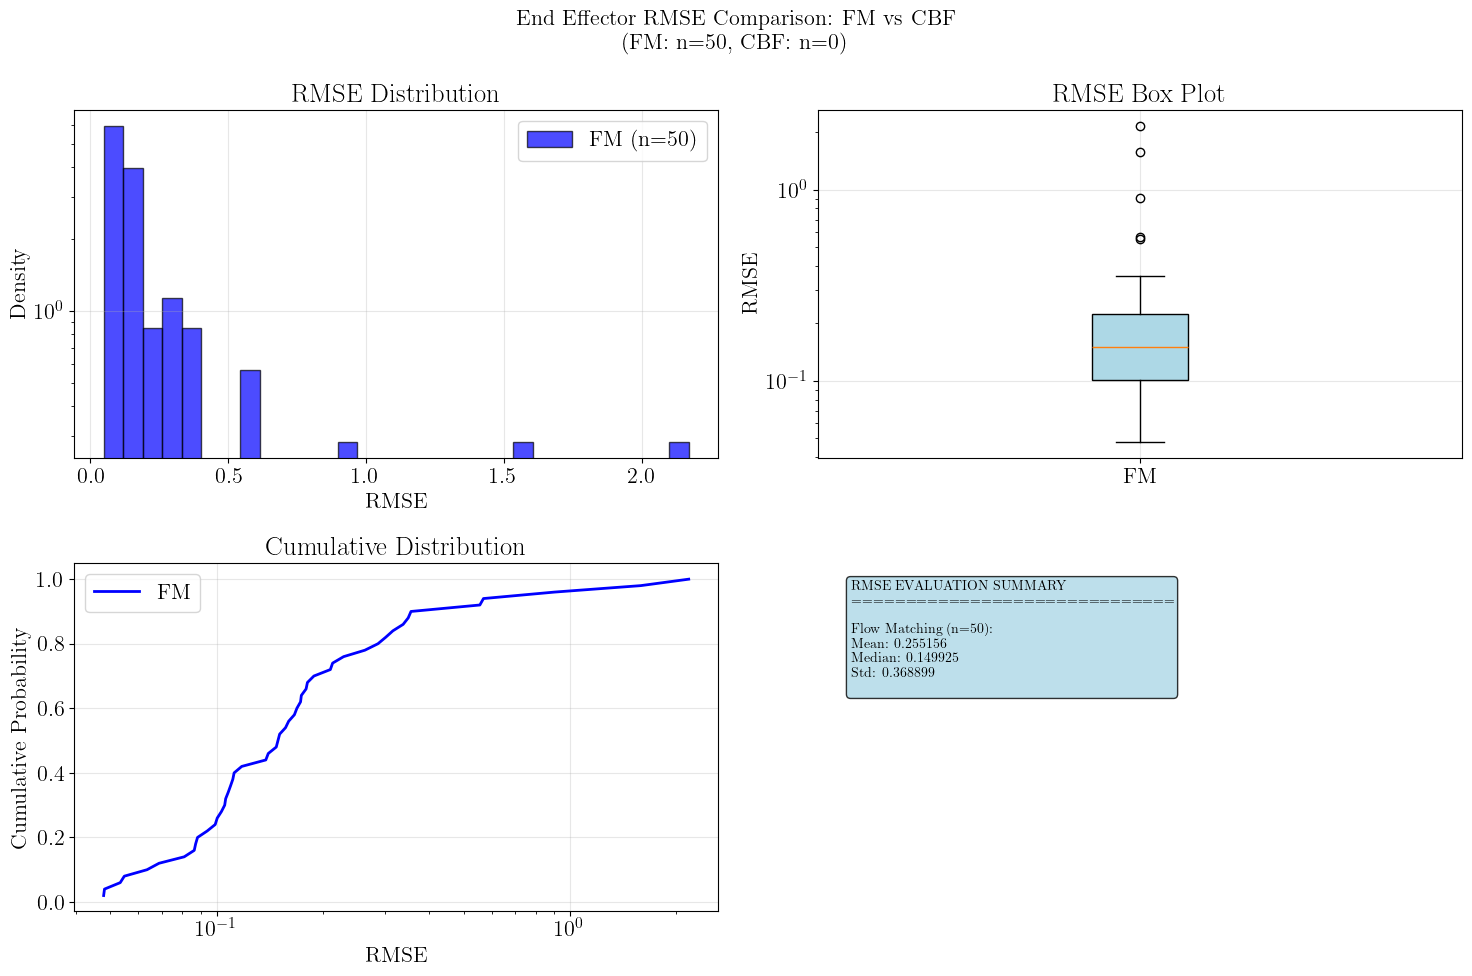


Evaluation completed in 61.52 seconds
FM trajectories evaluated: 50/50

✓ Batch evaluation completed!
Final Results:
  FM RMSE: 0.255156 ± 0.368899


In [26]:
import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

def compute_single_rmse(states, controls, dyn, verbose=False):
    """
    Compute RMSE for a single trajectory (extracted from working debug function)
    """
    def forward_kinematics(state, l1=1.0, l2=1.0):
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    # Check for invalid values
    if (np.any(np.isnan(states)) or np.any(np.isinf(states)) or 
        np.any(np.isnan(controls)) or np.any(np.isinf(controls))):
        if verbose:
            print("Invalid values in trajectory data")
        return None
    
    try:
        # Compute end effector positions from states
        ee_from_states = np.array([forward_kinematics(state) for state in states])
        
        # Forward simulation
        simulated_states = [states[0].copy()]
        for t in range(len(controls) - 1):
            current_state = simulated_states[-1]
            current_control = controls[t]
            
            # Check for extreme values
            if (np.any(np.abs(current_state) > 1e6) or 
                np.any(np.abs(current_control) > 1e6)):
                if verbose:
                    print(f"Extreme values at step {t}")
                return None
                
            next_state = dyn.rk4_step(current_state, current_control, 0.1)
            
            # Check simulation result
            if np.any(np.isnan(next_state)) or np.any(np.isinf(next_state)):
                if verbose:
                    print(f"Simulation failed at step {t}")
                return None
            
            simulated_states.append(next_state)
        
        simulated_states = np.array(simulated_states)
        
        # Compute end effector positions from simulation
        ee_from_simulation = np.array([forward_kinematics(state) for state in simulated_states])
        
        # Compute RMSE
        ee_errors = np.linalg.norm(ee_from_states - ee_from_simulation, axis=1)
        
        if np.any(np.isnan(ee_errors)) or np.any(np.isinf(ee_errors)):
            if verbose:
                print("Invalid error values")
            return None
            
        rmse = np.sqrt(np.mean(ee_errors**2))
        
        return {
            'rmse': rmse,
            'ee_errors': ee_errors,
            'max_error': np.max(ee_errors),
            'mean_error': np.mean(ee_errors),
            'ee_from_states': ee_from_states,
            'ee_from_simulation': ee_from_simulation
        }
        
    except Exception as e:
        if verbose:
            print(f"Error in RMSE computation: {e}")
        return None

def evaluate_fm_batch_rmse(n_trajectories=50):
    """
    Evaluate RMSE for batch of Flow Matching trajectories
    """
    print(f"Evaluating RMSE for {n_trajectories} Flow Matching trajectories...")
    print("=" * 60)
    
    # Initialize
    dyn = DoublePendulumDynamics()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Results storage
    fm_rmses = []
    fm_details = []
    
    # Check if we have existing generated trajectories
    if 'generated_trajectories' in globals() and len(generated_trajectories) >= n_trajectories:
        print(f"Using existing generated trajectories...")
        
        for i in tqdm(range(n_trajectories), desc="Evaluating existing FM trajectories"):
            states = generated_trajectories[i]['states']
            controls = generated_trajectories[i]['controls']
            
            result = compute_single_rmse(states, controls, dyn, verbose=(i < 3))
            if result is not None:
                fm_rmses.append(result['rmse'])
                fm_details.append(result)
            else:
                if i < 5:
                    print(f"Failed to compute RMSE for trajectory {i}")
                    
    else:
        print(f"Sampling new Flow Matching trajectories...")
        
        # ODE function for FM sampling
        def ode_func(t, x_flat):
            batch_size = 1
            x = x_flat.view(batch_size, 6, 100)
            t_tensor = torch.ones(batch_size, device=x.device) * t
            with torch.set_grad_enabled(False):
                v = flow_model(x, t_tensor)
            return v.view(-1)
        
        for i in tqdm(range(n_trajectories), desc="Sampling and evaluating FM trajectories"):
            try:
                with torch.no_grad():
                    # Sample trajectory
                    x0_noise = torch.randn((1, 6, 100), device=device)
                    t_span = torch.linspace(0, 1, 2, device=device)
                    
                    traj = torchdiffeq.odeint(
                        ode_func, x0_noise.view(-1), t_span,
                        method='dopri5', atol=1e-5, rtol=1e-5
                    )
                    
                    x_final = traj[-1].view(6, 100).cpu().numpy()
                    states_norm = x_final[:4, :].T
                    controls_norm = x_final[4:, :].T
                    
                    states = state_scaler.denormalize(states_norm)
                    controls = control_scaler.denormalize(controls_norm)
                    
                    # Compute RMSE
                    result = compute_single_rmse(states, controls, dyn, verbose=(i < 3))
                    if result is not None:
                        fm_rmses.append(result['rmse'])
                        fm_details.append(result)
                    else:
                        if i < 5:
                            print(f"Failed to compute RMSE for sampled trajectory {i}")
                        
            except Exception as e:
                if i < 5:
                    print(f"Failed to sample trajectory {i}: {e}")
                continue
    
    return np.array(fm_rmses), fm_details

def evaluate_cbf_batch_rmse():
    """
    Evaluate RMSE for CBF-corrected trajectories (if available)
    """
    print(f"Evaluating RMSE for CBF trajectories...")
    print("=" * 60)
    
    # Initialize
    dyn = DoublePendulumDynamics()
    
    # Results storage
    cbf_rmses = []
    cbf_details = []
    
    # Check for CBF data with robust error handling
    cbf_data = None
    
    # Method 1: Check cbf_clf_corrected_trajectories
    if 'cbf_clf_corrected_trajectories' in globals():
        try:
            if cbf_clf_corrected_trajectories is not None and 'corrected_trajectories' in cbf_clf_corrected_trajectories:
                cbf_data = cbf_clf_corrected_trajectories['corrected_trajectories']
                print(f"✓ Found cbf_clf_corrected_trajectories with {len(cbf_data)} trajectories")
        except Exception as e:
            print(f"✗ Error accessing cbf_clf_corrected_trajectories: {e}")
    
    # Method 2: Check batch_results (if first method failed)
    if cbf_data is None and 'batch_results' in globals():
        try:
            if (batch_results is not None and 
                isinstance(batch_results, dict) and 
                'corrected_trajectories' in batch_results):
                cbf_data = batch_results['corrected_trajectories']
                print(f"✓ Found batch_results with {len(cbf_data)} trajectories")
        except Exception as e:
            print(f"✗ Error accessing batch_results: {e}")
    
    # Method 3: Try to load from file
    if cbf_data is None:
        try:
            import os
            import pickle
            
            # Look for CBF result files
            cbf_files = [f for f in os.listdir('.') if 'cbf' in f.lower() and f.endswith('.pkl')]
            if cbf_files:
                print(f"Found CBF files: {cbf_files[:3]}...")  # Show first 3
                with open(cbf_files[0], 'rb') as f:
                    loaded_data = pickle.load(f)
                    if 'corrected_trajectories' in loaded_data:
                        cbf_data = loaded_data['corrected_trajectories']
                        print(f"✓ Loaded CBF data from {cbf_files[0]} with {len(cbf_data)} trajectories")
        except Exception as e:
            print(f"✗ Error loading CBF data from file: {e}")
    
    # Final check
    if cbf_data is None:
        print("✗ No CBF trajectory data found")
        return np.array([]), []
    
    if len(cbf_data) == 0:
        print("✗ CBF data is empty")
        return np.array([]), []
    
    successful_cbf = 0
    
    for i, traj_data in enumerate(tqdm(cbf_data, desc="Evaluating CBF trajectories")):
        try:
            states = None
            controls = None
            
            # Handle different CBF data structures
            if isinstance(traj_data, dict):
                # Method 1: Direct keys
                if 'states_corrected' in traj_data and 'controls_corrected' in traj_data:
                    states = traj_data['states_corrected']
                    controls = traj_data['controls_corrected']
                # Method 2: Alternative keys
                elif 'corrected_states' in traj_data and 'corrected_controls' in traj_data:
                    states = traj_data['corrected_states']
                    controls = traj_data['corrected_controls']
                # Method 3: Check if it has the 'original_index' key (indicates specific structure)
                elif 'original_index' in traj_data:
                    # This might be the relaxed_cbf_clf structure
                    continue  # Skip for now, or handle differently
                else:
                    if i < 3:  # Print structure for debugging
                        print(f"Trajectory {i} keys: {list(traj_data.keys())}")
                    continue
            else:
                if i < 3:
                    print(f"Trajectory {i} is not a dict: {type(traj_data)}")
                continue
            
            # Validate data
            if states is None or controls is None:
                continue
                
            if not isinstance(states, np.ndarray) or not isinstance(controls, np.ndarray):
                # Try to convert to numpy arrays
                try:
                    states = np.array(states)
                    controls = np.array(controls)
                except:
                    continue
            
            # Check shapes
            if states.shape[1] != 4 or controls.shape[1] != 2:
                if i < 3:
                    print(f"Trajectory {i} has wrong shapes: states {states.shape}, controls {controls.shape}")
                continue
            
            # Compute RMSE
            result = compute_single_rmse(states, controls, dyn, verbose=(i < 3))
            if result is not None:
                cbf_rmses.append(result['rmse'])
                cbf_details.append(result)
                successful_cbf += 1
            else:
                if i < 5:
                    print(f"Failed to compute RMSE for CBF trajectory {i}")
                
        except Exception as e:
            if i < 5:
                print(f"Error processing CBF trajectory {i}: {e}")
            continue
    
    print(f"Successfully processed {successful_cbf}/{len(cbf_data)} CBF trajectories")
    return np.array(cbf_rmses), cbf_details

def print_rmse_statistics(rmses, method_name):
    """Print detailed statistics for RMSE values"""
    if len(rmses) == 0:
        print(f"{method_name}: No valid trajectories")
        return
        
    print(f"\n{method_name} RMSE Statistics:")
    print("-" * 40)
    print(f"Number of trajectories: {len(rmses)}")
    print(f"Mean RMSE: {np.mean(rmses):.6f}")
    print(f"Std RMSE: {np.std(rmses):.6f}")
    print(f"Median RMSE: {np.median(rmses):.6f}")
    print(f"Min RMSE: {np.min(rmses):.6f}")
    print(f"Max RMSE: {np.max(rmses):.6f}")
    print(f"25th percentile: {np.percentile(rmses, 25):.6f}")
    print(f"75th percentile: {np.percentile(rmses, 75):.6f}")
    print(f"95th percentile: {np.percentile(rmses, 95):.6f}")

def create_comparison_visualization(fm_rmses, cbf_rmses):
    """Create visualization comparing FM and CBF RMSE results"""
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'End Effector RMSE Comparison: FM vs CBF\n'
                 f'(FM: n={len(fm_rmses)}, CBF: n={len(cbf_rmses)})', fontsize=16)
    
    # Plot 1: Histograms
    ax = axes[0, 0]
    
    # FM histogram
    ax.hist(fm_rmses, bins=30, alpha=0.7, label=f'FM (n={len(fm_rmses)})', 
            density=True, color='blue', edgecolor='black')
    
    # CBF histogram (if available)
    if len(cbf_rmses) > 0:
        ax.hist(cbf_rmses, bins=30, alpha=0.7, label=f'CBF (n={len(cbf_rmses)})', 
                density=True, color='red', edgecolor='black')
    
    ax.set_xlabel('RMSE')
    ax.set_ylabel('Density')
    ax.set_title('RMSE Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Plot 2: Box plot
    ax = axes[0, 1]
    
    data_to_plot = [fm_rmses]
    labels = ['FM']
    colors = ['lightblue']
    
    if len(cbf_rmses) > 0:
        data_to_plot.append(cbf_rmses)
        labels.append('CBF')
        colors.append('lightcoral')
    
    box_plot = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE Box Plot')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Plot 3: Cumulative distribution
    ax = axes[1, 0]
    
    # FM CDF
    fm_sorted = np.sort(fm_rmses)
    fm_cdf = np.arange(1, len(fm_sorted) + 1) / len(fm_sorted)
    ax.plot(fm_sorted, fm_cdf, 'b-', linewidth=2, label='FM')
    
    # CBF CDF (if available)
    if len(cbf_rmses) > 0:
        cbf_sorted = np.sort(cbf_rmses)
        cbf_cdf = np.arange(1, len(cbf_sorted) + 1) / len(cbf_sorted)
        ax.plot(cbf_sorted, cbf_cdf, 'r-', linewidth=2, label='CBF')
    
    ax.set_xlabel('RMSE')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title('Cumulative Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    
    # Plot 4: Summary table
    ax = axes[1, 1]
    ax.axis('off')
    
    # Create summary text
    summary_lines = []
    summary_lines.append("RMSE EVALUATION SUMMARY")
    summary_lines.append("=" * 30)
    summary_lines.append("")
    
    # FM statistics
    summary_lines.append(f"Flow Matching (n={len(fm_rmses)}):")
    summary_lines.append(f"  Mean:    {np.mean(fm_rmses):.6f}")
    summary_lines.append(f"  Median:  {np.median(fm_rmses):.6f}")
    summary_lines.append(f"  Std:     {np.std(fm_rmses):.6f}")
    summary_lines.append("")
    
    # CBF statistics (if available)
    if len(cbf_rmses) > 0:
        summary_lines.append(f"FM + CBF (n={len(cbf_rmses)}):")
        summary_lines.append(f"  Mean:    {np.mean(cbf_rmses):.6f}")
        summary_lines.append(f"  Median:  {np.median(cbf_rmses):.6f}")
        summary_lines.append(f"  Std:     {np.std(cbf_rmses):.6f}")
        summary_lines.append("")
        
        # Improvement calculation
        mean_improvement = (np.mean(fm_rmses) - np.mean(cbf_rmses)) / np.mean(fm_rmses) * 100
        median_improvement = (np.median(fm_rmses) - np.median(cbf_rmses)) / np.median(fm_rmses) * 100
        
        summary_lines.append("Improvement with CBF:")
        summary_lines.append(f"  Mean:    {mean_improvement:+.2f}%")
        summary_lines.append(f"  Median:  {median_improvement:+.2f}%")
        
        # Statistical test
        try:
            from scipy.stats import ranksums
            stat, p_val = ranksums(fm_rmses, cbf_rmses)
            summary_lines.append("")
            summary_lines.append(f"Statistical Test:")
            summary_lines.append(f"  p-value: {p_val:.2e}")
            summary_lines.append(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")
        except:
            pass
    
    summary_text = '\n'.join(summary_lines)
    
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return fig

def run_batch_rmse_evaluation(n_fm_trajectories=50):
    """
    Main function to run batch RMSE evaluation
    """
    print("BATCH END EFFECTOR RMSE EVALUATION")
    print("=" * 80)
    
    start_time = time.time()
    
    # Evaluate FM trajectories
    print(f"\nStep 1: Evaluating Flow Matching trajectories...")
    fm_rmses, fm_details = evaluate_fm_batch_rmse(n_fm_trajectories)
    
    # Evaluate CBF trajectories
    print(f"\nStep 2: Evaluating CBF trajectories...")
    cbf_rmses, cbf_details = evaluate_cbf_batch_rmse()
    
    # Print statistics
    print(f"\n" + "="*80)
    print("RESULTS SUMMARY")
    print("="*80)
    
    print_rmse_statistics(fm_rmses, "Flow Matching")
    if len(cbf_rmses) > 0:
        print_rmse_statistics(cbf_rmses, "Flow Matching + CBF")
        
        # Comparison
        print(f"\nCOMPARISON:")
        print("-" * 40)
        fm_mean = np.mean(fm_rmses)
        cbf_mean = np.mean(cbf_rmses)
        improvement = (fm_mean - cbf_mean) / fm_mean * 100
        
        print(f"Mean RMSE improvement: {improvement:+.2f}%")
        
        if improvement > 0:
            print(f"✓ CBF improves dynamics consistency")
        else:
            print(f"✗ CBF does not improve dynamics consistency")
    
    else:
        print(f"\nNo CBF data available for comparison")
    
    # Create visualization
    print(f"\nStep 3: Creating visualization...")
    fig = create_comparison_visualization(fm_rmses, cbf_rmses)
    
    # Final summary
    total_time = time.time() - start_time
    print(f"\nEvaluation completed in {total_time:.2f} seconds")
    print(f"FM trajectories evaluated: {len(fm_rmses)}/{n_fm_trajectories}")
    if len(cbf_rmses) > 0:
        print(f"CBF trajectories evaluated: {len(cbf_rmses)}")
    
    # Return results
    results = {
        'fm_rmses': fm_rmses,
        'cbf_rmses': cbf_rmses,
        'fm_details': fm_details,
        'cbf_details': cbf_details,
        'n_fm_requested': n_fm_trajectories,
        'evaluation_time': total_time
    }
    
    return results

# Run the batch evaluation
print("Starting batch RMSE evaluation...")
batch_results = run_batch_rmse_evaluation(n_fm_trajectories=50)

print(f"\n✓ Batch evaluation completed!")
print(f"Final Results:")
print(f"  FM RMSE: {np.mean(batch_results['fm_rmses']):.6f} ± {np.std(batch_results['fm_rmses']):.6f}")
if len(batch_results['cbf_rmses']) > 0:
    print(f"  CBF RMSE: {np.mean(batch_results['cbf_rmses']):.6f} ± {np.std(batch_results['cbf_rmses']):.6f}")

Starting CBF state projection RMSE evaluation...
CBF STATE PROJECTION RMSE EVALUATION

Step 1: Generating CBF projected trajectories...
Generating 50 CBF state-projected trajectories...
Sampling new trajectories for CBF projection...


Sampling and projecting trajectories: 100%|██████████| 50/50 [00:57<00:00,  1.16s/it]


Generated 50 CBF projected trajectories
Total violations in original trajectories: 76
Trajectories with violations: 17/50

Step 2: Evaluating CBF projected RMSE...
Evaluating CBF projected RMSE for 50 trajectories...


Computing CBF projected RMSE: 100%|██████████| 50/50 [00:00<00:00, 206.85it/s]
/tmp/ipykernel_1569974/3243482565.py:341: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot([fm_rmses, cbf_rmse_values],


Successfully computed RMSE for 50/50 trajectories

Step 3: Getting original FM RMSE for comparison...
✓ Using existing FM RMSE results: 50 trajectories

Step 4: Comparing methods...

CBF STATE PROJECTION RMSE COMPARISON

Method Comparison:
Method                    N        Mean RMSE    Std RMSE     Median RMSE 
----------------------------------------------------------------------
Original FM               50       0.255156     0.368899     0.149925    
CBF State Projected       50       0.526052     0.616321     0.221709    

Improvement Analysis:
Mean RMSE change: -106.17%
✗ CBF state projection degrades dynamics consistency

Statistical Test (Wilcoxon rank-sum):
P-value: 1.74e-02
Statistically significant difference: Yes

Step 5: Creating visualization...


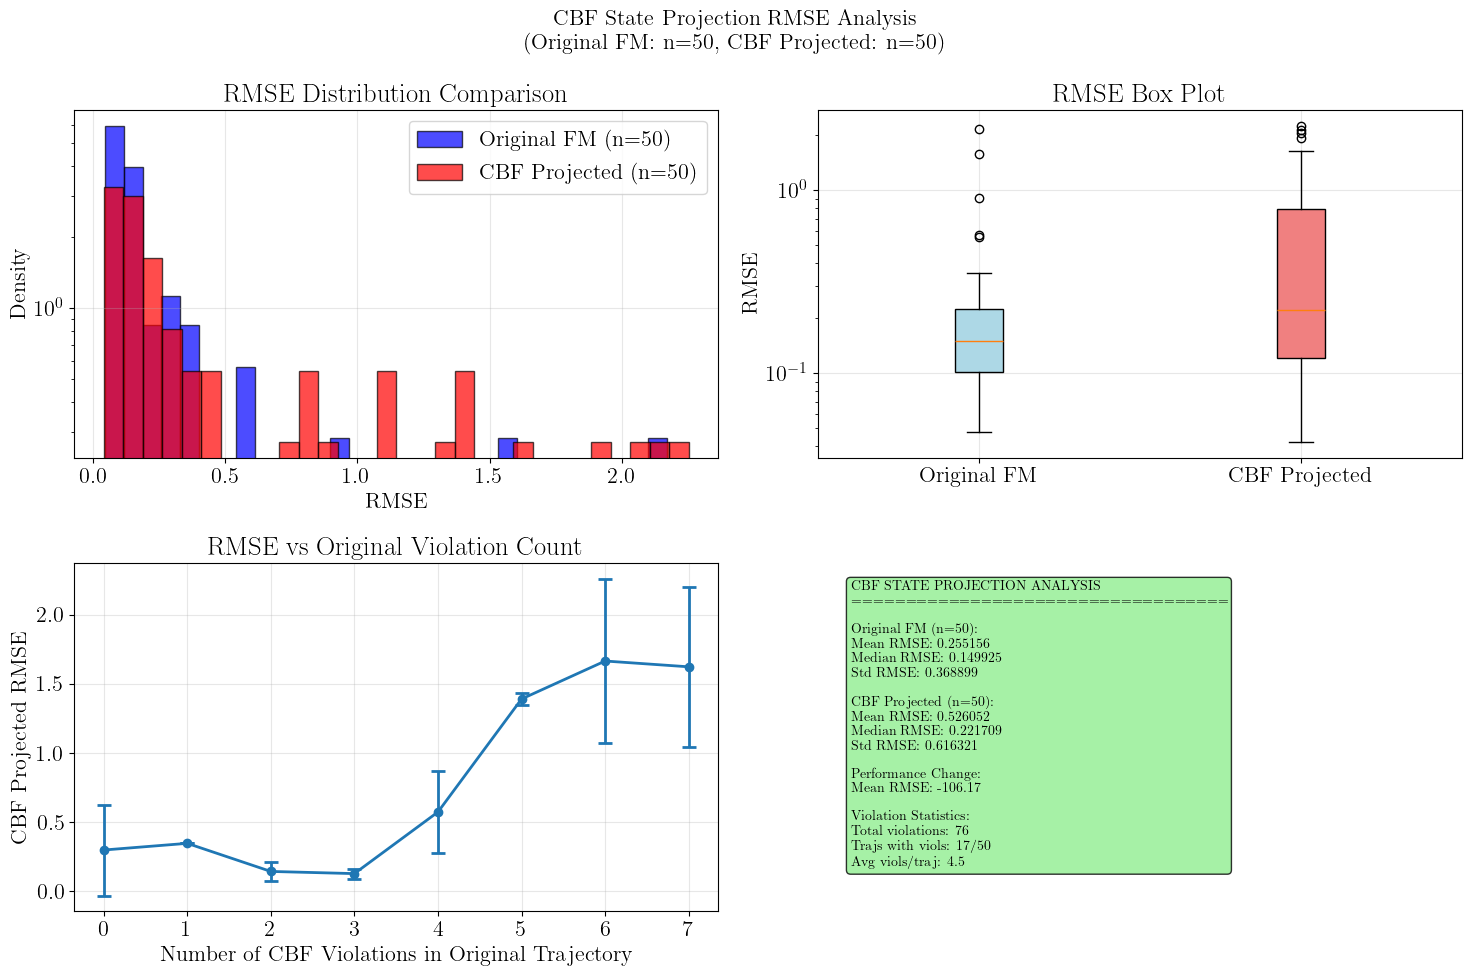


CBF projection evaluation completed in 62.45 seconds
CBF projected trajectories: 50
Final CBF projected RMSE: 0.526052 ± 0.616321

✓ CBF projection evaluation completed!
Results summary:
  Original FM RMSE: 0.255156 ± 0.368899
  CBF Projected RMSE: 0.526052 ± 0.616321


In [28]:
import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

class CBFStateProjector:
    """
    Class to project states to satisfy CBF constraints
    """
    def __init__(self, x_min=-1.0, l1=1.0, l2=1.0):
        self.x_min = x_min
        self.l1 = l1
        self.l2 = l2
    
    def forward_kinematics(self, state):
        """Calculate end effector position"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def cbf_constraint_value(self, state):
        """CBF constraint value (>0 means safe)"""
        ee_pos = self.forward_kinematics(state)
        return ee_pos[0] - self.x_min
    
    def project_state_simple(self, state):
        """
        Simple state projection: if CBF is violated, adjust θ1 to make end effector at boundary
        """
        projected_state = state.copy()
        
        # Check if constraint is violated
        if self.cbf_constraint_value(state) >= 0:
            return projected_state  # Already safe
        
        # Find θ1 that places end effector at x = x_min
        θ2 = state[1]
        
        # Target: x2 = x_min
        # x2 = l1*sin(θ1) + l2*sin(θ2) = x_min
        # θ1 = arcsin((x_min - l2*sin(θ2)) / l1)
        
        target_sin_θ1 = (self.x_min - self.l2 * np.sin(θ2)) / self.l1
        
        # Check if solution exists
        if np.abs(target_sin_θ1) <= 1.0:
            # Choose the solution closest to original θ1
            θ1_option1 = np.arcsin(target_sin_θ1)
            θ1_option2 = np.pi - np.arcsin(target_sin_θ1)
            
            if np.abs(θ1_option1 - state[0]) < np.abs(θ1_option2 - state[0]):
                projected_state[0] = θ1_option1
            else:
                projected_state[0] = θ1_option2
        else:
            # No exact solution, project to closest safe state
            # Clamp sin(θ1) to valid range and choose best θ2
            if target_sin_θ1 > 1.0:
                projected_state[0] = np.pi / 2  # sin(θ1) = 1
            else:
                projected_state[0] = -np.pi / 2  # sin(θ1) = -1
        
        return projected_state
    
    def project_trajectory(self, states):
        """Project entire trajectory to satisfy CBF constraints"""
        projected_states = []
        violation_count = 0
        
        for state in states:
            projected_state = self.project_state_simple(state)
            projected_states.append(projected_state)
            
            # Count violations in original trajectory
            if self.cbf_constraint_value(state) < 0:
                violation_count += 1
        
        return np.array(projected_states), violation_count

def generate_cbf_projected_trajectories(n_trajectories=50, x_min=-1.0):
    """
    Generate CBF state-projected trajectories from Flow Matching
    """
    print(f"Generating {n_trajectories} CBF state-projected trajectories...")
    print("=" * 60)
    
    # Initialize
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    projector = CBFStateProjector(x_min=x_min)
    
    # Storage
    cbf_projected_data = []
    
    # Check if we can use existing generated trajectories
    if 'generated_trajectories' in globals() and len(generated_trajectories) >= n_trajectories:
        print(f"Using existing generated trajectories for CBF projection...")
        
        for i in tqdm(range(n_trajectories), desc="Projecting existing trajectories"):
            try:
                original_states = generated_trajectories[i]['states']
                original_controls = generated_trajectories[i]['controls']
                
                # Project states to satisfy CBF
                projected_states, violation_count = projector.project_trajectory(original_states)
                
                cbf_projected_data.append({
                    'trajectory_id': i,
                    'original_states': original_states,
                    'original_controls': original_controls,
                    'projected_states': projected_states,
                    'violation_count': violation_count
                })
                
            except Exception as e:
                print(f"Error projecting trajectory {i}: {e}")
                continue
                
    else:
        print(f"Sampling new trajectories for CBF projection...")
        
        # ODE function for FM sampling
        def ode_func(t, x_flat):
            batch_size = 1
            x = x_flat.view(batch_size, 6, 100)
            t_tensor = torch.ones(batch_size, device=x.device) * t
            with torch.set_grad_enabled(False):
                v = flow_model(x, t_tensor)
            return v.view(-1)
        
        for i in tqdm(range(n_trajectories), desc="Sampling and projecting trajectories"):
            try:
                with torch.no_grad():
                    # Sample trajectory
                    x0_noise = torch.randn((1, 6, 100), device=device)
                    t_span = torch.linspace(0, 1, 2, device=device)
                    
                    traj = torchdiffeq.odeint(
                        ode_func, x0_noise.view(-1), t_span,
                        method='dopri5', atol=1e-5, rtol=1e-5
                    )
                    
                    x_final = traj[-1].view(6, 100).cpu().numpy()
                    states_norm = x_final[:4, :].T
                    controls_norm = x_final[4:, :].T
                    
                    original_states = state_scaler.denormalize(states_norm)
                    original_controls = control_scaler.denormalize(controls_norm)
                    
                    # Project states to satisfy CBF
                    projected_states, violation_count = projector.project_trajectory(original_states)
                    
                    cbf_projected_data.append({
                        'trajectory_id': i,
                        'original_states': original_states,
                        'original_controls': original_controls,
                        'projected_states': projected_states,
                        'violation_count': violation_count
                    })
                    
            except Exception as e:
                print(f"Error sampling and projecting trajectory {i}: {e}")
                continue
    
    print(f"Generated {len(cbf_projected_data)} CBF projected trajectories")
    
    # Statistics
    total_violations = sum(data['violation_count'] for data in cbf_projected_data)
    trajectories_with_violations = sum(1 for data in cbf_projected_data if data['violation_count'] > 0)
    
    print(f"Total violations in original trajectories: {total_violations}")
    print(f"Trajectories with violations: {trajectories_with_violations}/{len(cbf_projected_data)}")
    
    return cbf_projected_data

def evaluate_cbf_projected_rmse(cbf_projected_data):
    """
    Evaluate RMSE between CBF projected states and control-simulated states
    """
    print(f"Evaluating CBF projected RMSE for {len(cbf_projected_data)} trajectories...")
    print("=" * 60)
    
    # Initialize
    dyn = DoublePendulumDynamics()
    
    def forward_kinematics(state, l1=1.0, l2=1.0):
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    # Storage
    rmse_results = []
    
    for i, data in enumerate(tqdm(cbf_projected_data, desc="Computing CBF projected RMSE")):
        try:
            projected_states = data['projected_states']
            original_controls = data['original_controls']
            
            # Method 1: End effector positions from CBF projected states
            ee_from_projected = np.array([forward_kinematics(state) for state in projected_states])
            
            # Method 2: Forward simulation using original controls (no corrections)
            simulated_states = [projected_states[0].copy()]  # Start from projected initial state
            
            for t in range(len(original_controls) - 1):
                current_state = simulated_states[-1]
                current_control = original_controls[t]
                
                # Check for extreme values
                if (np.any(np.abs(current_state) > 1e6) or 
                    np.any(np.abs(current_control) > 1e6)):
                    if i < 3:
                        print(f"Extreme values in trajectory {i} at step {t}")
                    break
                    
                next_state = dyn.rk4_step(current_state, current_control, 0.1)
                
                # Check simulation result
                if np.any(np.isnan(next_state)) or np.any(np.isinf(next_state)):
                    if i < 3:
                        print(f"Simulation failed for trajectory {i} at step {t}")
                    break
                
                simulated_states.append(next_state)
            
            if len(simulated_states) != len(projected_states):
                if i < 3:
                    print(f"Incomplete simulation for trajectory {i}: {len(simulated_states)}/{len(projected_states)}")
                continue
            
            simulated_states = np.array(simulated_states)
            
            # End effector positions from simulation
            ee_from_simulation = np.array([forward_kinematics(state) for state in simulated_states])
            
            # Compute RMSE
            ee_errors = np.linalg.norm(ee_from_projected - ee_from_simulation, axis=1)
            
            if np.any(np.isnan(ee_errors)) or np.any(np.isinf(ee_errors)):
                if i < 3:
                    print(f"Invalid errors for trajectory {i}")
                continue
                
            rmse = np.sqrt(np.mean(ee_errors**2))
            
            rmse_results.append({
                'trajectory_id': data['trajectory_id'],
                'rmse': rmse,
                'ee_errors': ee_errors,
                'max_error': np.max(ee_errors),
                'mean_error': np.mean(ee_errors),
                'violation_count': data['violation_count'],
                'ee_from_projected': ee_from_projected,
                'ee_from_simulation': ee_from_simulation
            })
            
        except Exception as e:
            if i < 5:
                print(f"Error computing RMSE for trajectory {i}: {e}")
            continue
    
    print(f"Successfully computed RMSE for {len(rmse_results)}/{len(cbf_projected_data)} trajectories")
    
    return rmse_results

def compare_cbf_projection_methods(fm_rmses, cbf_projected_rmses):
    """
    Compare original FM RMSE vs CBF projected RMSE
    """
    print(f"\n" + "="*80)
    print("CBF STATE PROJECTION RMSE COMPARISON")
    print("="*80)
    
    # Extract RMSE values
    cbf_rmse_values = np.array([result['rmse'] for result in cbf_projected_rmses])
    
    print(f"\nMethod Comparison:")
    print(f"{'Method':<25} {'N':<8} {'Mean RMSE':<12} {'Std RMSE':<12} {'Median RMSE':<12}")
    print("-" * 70)
    print(f"{'Original FM':<25} {len(fm_rmses):<8} {np.mean(fm_rmses):<12.6f} {np.std(fm_rmses):<12.6f} {np.median(fm_rmses):<12.6f}")
    print(f"{'CBF State Projected':<25} {len(cbf_rmse_values):<8} {np.mean(cbf_rmse_values):<12.6f} {np.std(cbf_rmse_values):<12.6f} {np.median(cbf_rmse_values):<12.6f}")
    
    # Calculate improvement
    if len(cbf_rmse_values) > 0:
        fm_mean = np.mean(fm_rmses)
        cbf_mean = np.mean(cbf_rmse_values)
        improvement = (fm_mean - cbf_mean) / fm_mean * 100
        
        print(f"\nImprovement Analysis:")
        print(f"Mean RMSE change: {improvement:+.2f}%")
        
        if improvement > 0:
            print(f"✓ CBF state projection improves dynamics consistency")
        else:
            print(f"✗ CBF state projection degrades dynamics consistency")
    
    # Statistical test
    try:
        from scipy.stats import ranksums
        stat, p_val = ranksums(fm_rmses, cbf_rmse_values)
        print(f"\nStatistical Test (Wilcoxon rank-sum):")
        print(f"P-value: {p_val:.2e}")
        print(f"Statistically significant difference: {'Yes' if p_val < 0.05 else 'No'}")
    except Exception as e:
        print(f"Statistical test failed: {e}")
    
    return cbf_rmse_values

def create_cbf_projection_visualization(fm_rmses, cbf_projected_rmses):
    """
    Create visualization comparing original FM vs CBF projected RMSE
    """
    cbf_rmse_values = np.array([result['rmse'] for result in cbf_projected_rmses])
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'CBF State Projection RMSE Analysis\n'
                 f'(Original FM: n={len(fm_rmses)}, CBF Projected: n={len(cbf_rmse_values)})', fontsize=16)
    
    # Plot 1: RMSE comparison histograms
    ax = axes[0, 0]
    ax.hist(fm_rmses, bins=30, alpha=0.7, label=f'Original FM (n={len(fm_rmses)})', 
            density=True, color='blue', edgecolor='black')
    ax.hist(cbf_rmse_values, bins=30, alpha=0.7, label=f'CBF Projected (n={len(cbf_rmse_values)})', 
            density=True, color='red', edgecolor='black')
    ax.set_xlabel('RMSE')
    ax.set_ylabel('Density')
    ax.set_title('RMSE Distribution Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Plot 2: Box plot
    ax = axes[0, 1]
    box_plot = ax.boxplot([fm_rmses, cbf_rmse_values], 
                         labels=['Original FM', 'CBF Projected'], 
                         patch_artist=True)
    box_plot['boxes'][0].set_facecolor('lightblue')
    box_plot['boxes'][1].set_facecolor('lightcoral')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE Box Plot')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Plot 3: Violation analysis
    ax = axes[1, 0]
    violation_counts = [result['violation_count'] for result in cbf_projected_rmses]
    rmse_by_violations = {}
    
    for result in cbf_projected_rmses:
        v_count = result['violation_count']
        if v_count not in rmse_by_violations:
            rmse_by_violations[v_count] = []
        rmse_by_violations[v_count].append(result['rmse'])
    
    violations = sorted(rmse_by_violations.keys())
    mean_rmses = [np.mean(rmse_by_violations[v]) for v in violations]
    std_rmses = [np.std(rmse_by_violations[v]) for v in violations]
    
    ax.errorbar(violations, mean_rmses, yerr=std_rmses, 
                marker='o', capsize=5, capthick=2, linewidth=2)
    ax.set_xlabel('Number of CBF Violations in Original Trajectory')
    ax.set_ylabel('CBF Projected RMSE')
    ax.set_title('RMSE vs Original Violation Count')
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Summary statistics
    ax = axes[1, 1]
    ax.axis('off')
    
    # Summary text
    summary_lines = []
    summary_lines.append("CBF STATE PROJECTION ANALYSIS")
    summary_lines.append("=" * 35)
    summary_lines.append("")
    summary_lines.append(f"Original FM (n={len(fm_rmses)}):")
    summary_lines.append(f"  Mean RMSE:    {np.mean(fm_rmses):.6f}")
    summary_lines.append(f"  Median RMSE:  {np.median(fm_rmses):.6f}")
    summary_lines.append(f"  Std RMSE:     {np.std(fm_rmses):.6f}")
    summary_lines.append("")
    summary_lines.append(f"CBF Projected (n={len(cbf_rmse_values)}):")
    summary_lines.append(f"  Mean RMSE:    {np.mean(cbf_rmse_values):.6f}")
    summary_lines.append(f"  Median RMSE:  {np.median(cbf_rmse_values):.6f}")
    summary_lines.append(f"  Std RMSE:     {np.std(cbf_rmse_values):.6f}")
    summary_lines.append("")
    
    if len(cbf_rmse_values) > 0:
        improvement = (np.mean(fm_rmses) - np.mean(cbf_rmse_values)) / np.mean(fm_rmses) * 100
        summary_lines.append("Performance Change:")
        summary_lines.append(f"  Mean RMSE:    {improvement:+.2f}%")
        
        # Violation statistics
        total_violations = sum(violation_counts)
        trajectories_with_violations = sum(1 for v in violation_counts if v > 0)
        summary_lines.append("")
        summary_lines.append("Violation Statistics:")
        summary_lines.append(f"  Total violations: {total_violations}")
        summary_lines.append(f"  Trajs with viols: {trajectories_with_violations}/{len(violation_counts)}")
        if trajectories_with_violations > 0:
            avg_violations = total_violations / trajectories_with_violations
            summary_lines.append(f"  Avg viols/traj:   {avg_violations:.1f}")
    
    summary_text = '\n'.join(summary_lines)
    
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return fig

def run_cbf_projection_evaluation(n_trajectories=50, x_min=-1.0):
    """
    Main function to run CBF state projection evaluation
    """
    print("CBF STATE PROJECTION RMSE EVALUATION")
    print("=" * 80)
    
    start_time = time.time()
    
    # Step 1: Generate or load CBF projected trajectories
    print(f"\nStep 1: Generating CBF projected trajectories...")
    cbf_projected_data = generate_cbf_projected_trajectories(n_trajectories, x_min)
    
    if len(cbf_projected_data) == 0:
        print("✗ No CBF projected trajectories generated!")
        return None
    
    # Step 2: Evaluate CBF projected RMSE
    print(f"\nStep 2: Evaluating CBF projected RMSE...")
    cbf_projected_rmses = evaluate_cbf_projected_rmse(cbf_projected_data)
    
    if len(cbf_projected_rmses) == 0:
        print("✗ No CBF projected RMSE computed!")
        return None
    
    # Step 3: Get original FM RMSE for comparison (reuse from previous evaluation if available)
    print(f"\nStep 3: Getting original FM RMSE for comparison...")
    if 'batch_results' in globals() and batch_results is not None and 'fm_rmses' in batch_results:
        fm_rmses = batch_results['fm_rmses']
        print(f"✓ Using existing FM RMSE results: {len(fm_rmses)} trajectories")
    else:
        print("Computing new FM RMSE for comparison...")
        # Quick FM evaluation for comparison
        from batch_rmse_evaluation import evaluate_fm_batch_rmse, compute_single_rmse
        fm_rmses, _ = evaluate_fm_batch_rmse(n_trajectories)
    
    # Step 4: Compare methods
    print(f"\nStep 4: Comparing methods...")
    cbf_rmse_values = compare_cbf_projection_methods(fm_rmses, cbf_projected_rmses)
    
    # Step 5: Create visualization
    print(f"\nStep 5: Creating visualization...")
    fig = create_cbf_projection_visualization(fm_rmses, cbf_projected_rmses)
    
    # Final summary
    total_time = time.time() - start_time
    print(f"\nCBF projection evaluation completed in {total_time:.2f} seconds")
    print(f"CBF projected trajectories: {len(cbf_projected_rmses)}")
    print(f"Final CBF projected RMSE: {np.mean(cbf_rmse_values):.6f} ± {np.std(cbf_rmse_values):.6f}")
    
    # Return results
    results = {
        'cbf_projected_data': cbf_projected_data,
        'cbf_projected_rmses': cbf_projected_rmses,
        'cbf_rmse_values': cbf_rmse_values,
        'fm_rmses': fm_rmses,
        'n_trajectories': n_trajectories,
        'x_min': x_min,
        'evaluation_time': total_time
    }
    
    return results

# Run the CBF projection evaluation
print("Starting CBF state projection RMSE evaluation...")
cbf_projection_results = run_cbf_projection_evaluation(n_trajectories=50, x_min=-1.0)

if cbf_projection_results is not None:
    print(f"\n✓ CBF projection evaluation completed!")
    print(f"Results summary:")
    print(f"  Original FM RMSE: {np.mean(cbf_projection_results['fm_rmses']):.6f} ± {np.std(cbf_projection_results['fm_rmses']):.6f}")
    print(f"  CBF Projected RMSE: {np.mean(cbf_projection_results['cbf_rmse_values']):.6f} ± {np.std(cbf_projection_results['cbf_rmse_values']):.6f}")
else:
    print(f"\n✗ CBF projection evaluation failed!")

Starting Flow Matching safety violation rate evaluation...
FLOW MATCHING SAFETY VIOLATION RATE EVALUATION
Evaluating FM Safety Violation Rate with 100 trajectories
Safety boundary: x >= -1.0
Sampling new Flow Matching trajectories...


Sampling and evaluating FM trajectories: 100%|██████████| 100/100 [01:57<00:00,  1.18s/it]



FLOW MATCHING SAFETY VIOLATION RATE RESULTS
Total requested trajectories: 100
Successful simulations: 99
Trajectories with violations: 42
Safety violation rate: 42.42%
Safety compliance rate: 57.58%

Detailed Statistics:
  Average violations per trajectory: 2.88
  Max violations in a single trajectory: 20
  Average minimum x position: -0.9628
  Worst x position: -1.9993
  Average safety margin: 0.0372
  Worst safety margin: -0.9993

Violation Severity:
  No violations: 57 (57.6%)
  Minor (1-5 steps): 19 (19.2%)
  Moderate (6-20 steps): 23 (23.2%)
  Severe (>20 steps): 0 (0.0%)

Creating visualization...


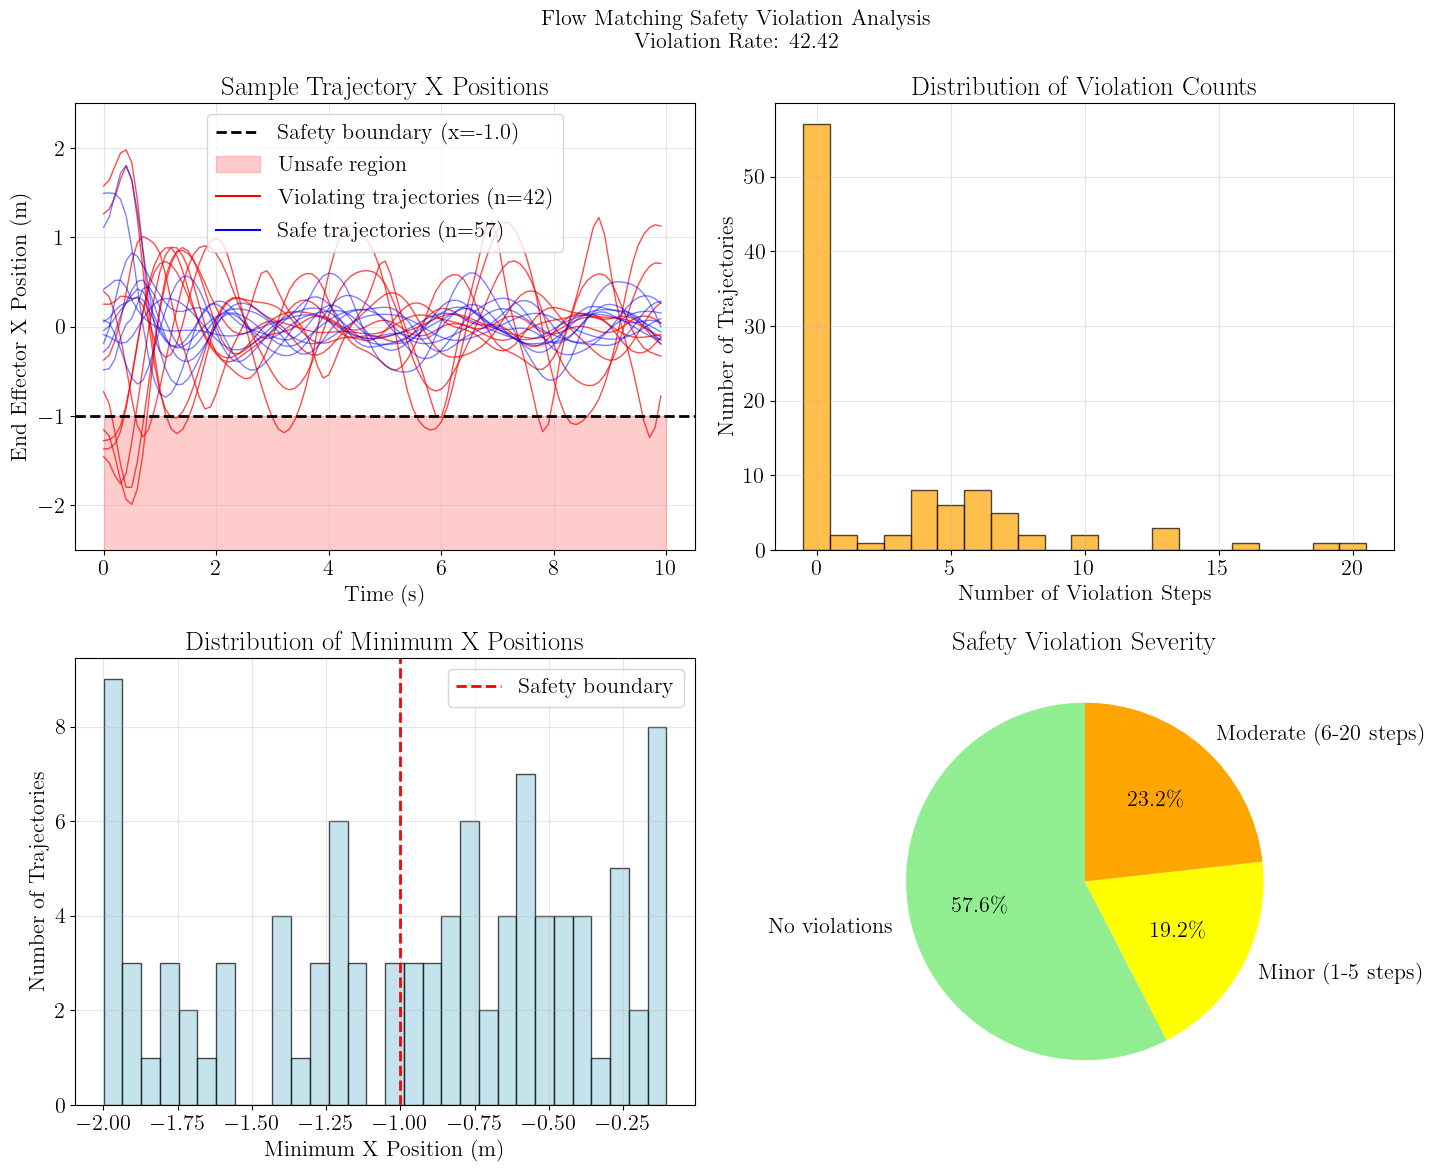


Safety violation evaluation completed in 118.97 seconds

FINAL RESULT
Flow Matching Safety Violation Rate: 42.42%
Safety Compliance Rate: 57.58%
(42/99 trajectories violated safety)

✓ Safety evaluation completed!
Key Result: 42.42% of FM trajectories violate safety constraints


In [33]:
import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

def evaluate_fm_safety_violation_rate(n_trajectories=100, x_min=-1.0):
    """
    Evaluate the safety violation rate for Flow Matching trajectories
    
    Returns the percentage of trajectories where the simulated end effector
    goes into the unsafe region (x < x_min) at least once.
    """
    print(f"Evaluating FM Safety Violation Rate with {n_trajectories} trajectories")
    print(f"Safety boundary: x >= {x_min}")
    print("=" * 70)
    
    # Initialize
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dyn = DoublePendulumDynamics()
    
    def forward_kinematics(state, l1=1.0, l2=1.0):
        """Calculate end effector position"""
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    # Storage for results
    trajectory_results = []
    safety_violations = 0
    successful_simulations = 0
    
    # Check if we can use existing generated trajectories
    if 'generated_trajectories' in globals() and len(generated_trajectories) >= n_trajectories:
        print(f"Using existing generated trajectories...")
        
        for i in tqdm(range(n_trajectories), desc="Evaluating existing FM trajectories"):
            try:
                states = generated_trajectories[i]['states']
                controls = generated_trajectories[i]['controls']
                
                # Forward simulation using controls
                simulated_states = [states[0].copy()]
                simulation_failed = False
                
                for t in range(len(controls) - 1):
                    current_state = simulated_states[-1]
                    current_control = controls[t]
                    
                    # Check for extreme values
                    if (np.any(np.abs(current_state) > 1e6) or 
                        np.any(np.abs(current_control) > 1e6)):
                        if i < 5:
                            print(f"Extreme values in trajectory {i} at step {t}")
                        simulation_failed = True
                        break
                    
                    next_state = dyn.rk4_step(current_state, current_control, 0.1)
                    
                    # Check simulation result
                    if np.any(np.isnan(next_state)) or np.any(np.isinf(next_state)):
                        if i < 5:
                            print(f"Simulation failed for trajectory {i} at step {t}")
                        simulation_failed = True
                        break
                    
                    simulated_states.append(next_state)
                
                if simulation_failed:
                    continue
                
                if len(simulated_states) != len(states):
                    if i < 5:
                        print(f"Incomplete simulation for trajectory {i}")
                    continue
                
                simulated_states = np.array(simulated_states)
                successful_simulations += 1
                
                # Calculate end effector positions from simulated states
                ee_positions = []
                for state in simulated_states:
                    ee_pos = forward_kinematics(state)
                    ee_positions.append(ee_pos)
                ee_positions = np.array(ee_positions)
                
                # Check for safety violations (x < x_min)
                x_positions = ee_positions[:, 0]
                violations = x_positions < x_min
                has_violation = np.any(violations)
                
                if has_violation:
                    safety_violations += 1
                
                # Store detailed results
                violation_count = np.sum(violations)
                min_x = np.min(x_positions)
                violation_steps = np.where(violations)[0]
                
                trajectory_results.append({
                    'trajectory_id': i,
                    'has_violation': has_violation,
                    'violation_count': violation_count,
                    'total_steps': len(simulated_states),
                    'min_x_position': min_x,
                    'safety_margin': min_x - x_min,
                    'violation_steps': violation_steps,
                    'x_positions': x_positions,
                    'ee_positions': ee_positions
                })
                
            except Exception as e:
                if i < 5:
                    print(f"Error processing trajectory {i}: {e}")
                continue
                
    else:
        print(f"Sampling new Flow Matching trajectories...")
        
        # ODE function for FM sampling
        def ode_func(t, x_flat):
            batch_size = 1
            x = x_flat.view(batch_size, 6, 100)
            t_tensor = torch.ones(batch_size, device=x.device) * t
            with torch.set_grad_enabled(False):
                v = flow_model(x, t_tensor)
            return v.view(-1)
        
        for i in tqdm(range(n_trajectories), desc="Sampling and evaluating FM trajectories"):
            try:
                with torch.no_grad():
                    # Sample trajectory
                    x0_noise = torch.randn((1, 6, 100), device=device)
                    t_span = torch.linspace(0, 1, 2, device=device)
                    
                    traj = torchdiffeq.odeint(
                        ode_func, x0_noise.view(-1), t_span,
                        method='dopri5', atol=1e-5, rtol=1e-5
                    )
                    
                    x_final = traj[-1].view(6, 100).cpu().numpy()
                    states_norm = x_final[:4, :].T
                    controls_norm = x_final[4:, :].T
                    
                    states = state_scaler.denormalize(states_norm)
                    controls = control_scaler.denormalize(controls_norm)
                    
                    # Forward simulation using controls
                    simulated_states = [states[0].copy()]
                    simulation_failed = False
                    
                    for t in range(len(controls) - 1):
                        current_state = simulated_states[-1]
                        current_control = controls[t]
                        
                        # Check for extreme values
                        if (np.any(np.abs(current_state) > 1e6) or 
                            np.any(np.abs(current_control) > 1e6)):
                            if i < 5:
                                print(f"Extreme values in trajectory {i} at step {t}")
                            simulation_failed = True
                            break
                        
                        next_state = dyn.rk4_step(current_state, current_control, 0.1)
                        
                        # Check simulation result
                        if np.any(np.isnan(next_state)) or np.any(np.isinf(next_state)):
                            if i < 5:
                                print(f"Simulation failed for trajectory {i} at step {t}")
                            simulation_failed = True
                            break
                        
                        simulated_states.append(next_state)
                    
                    if simulation_failed:
                        continue
                    
                    simulated_states = np.array(simulated_states)
                    successful_simulations += 1
                    
                    # Calculate end effector positions from simulated states
                    ee_positions = []
                    for state in simulated_states:
                        ee_pos = forward_kinematics(state)
                        ee_positions.append(ee_pos)
                    ee_positions = np.array(ee_positions)
                    
                    # Check for safety violations (x < x_min)
                    x_positions = ee_positions[:, 0]
                    violations = x_positions < x_min
                    has_violation = np.any(violations)
                    
                    if has_violation:
                        safety_violations += 1
                    
                    # Store detailed results
                    violation_count = np.sum(violations)
                    min_x = np.min(x_positions)
                    violation_steps = np.where(violations)[0]
                    
                    trajectory_results.append({
                        'trajectory_id': i,
                        'has_violation': has_violation,
                        'violation_count': violation_count,
                        'total_steps': len(simulated_states),
                        'min_x_position': min_x,
                        'safety_margin': min_x - x_min,
                        'violation_steps': violation_steps,
                        'x_positions': x_positions,
                        'ee_positions': ee_positions
                    })
                    
            except Exception as e:
                if i < 5:
                    print(f"Error sampling trajectory {i}: {e}")
                continue
    
    # Calculate statistics
    if successful_simulations == 0:
        print("✗ No successful simulations!")
        return None
    
    violation_rate = (safety_violations / successful_simulations) * 100
    
    # Print results
    print(f"\n" + "="*70)
    print("FLOW MATCHING SAFETY VIOLATION RATE RESULTS")
    print("="*70)
    print(f"Total requested trajectories: {n_trajectories}")
    print(f"Successful simulations: {successful_simulations}")
    print(f"Trajectories with violations: {safety_violations}")
    print(f"Safety violation rate: {violation_rate:.2f}%")
    print(f"Safety compliance rate: {100 - violation_rate:.2f}%")
    
    # Detailed statistics
    if len(trajectory_results) > 0:
        violation_counts = [r['violation_count'] for r in trajectory_results]
        min_x_positions = [r['min_x_position'] for r in trajectory_results]
        safety_margins = [r['safety_margin'] for r in trajectory_results]
        
        print(f"\nDetailed Statistics:")
        print(f"  Average violations per trajectory: {np.mean(violation_counts):.2f}")
        print(f"  Max violations in a single trajectory: {np.max(violation_counts)}")
        print(f"  Average minimum x position: {np.mean(min_x_positions):.4f}")
        print(f"  Worst x position: {np.min(min_x_positions):.4f}")
        print(f"  Average safety margin: {np.mean(safety_margins):.4f}")
        print(f"  Worst safety margin: {np.min(safety_margins):.4f}")
        
        # Categorize by severity
        minor_violations = sum(1 for r in trajectory_results if 0 < r['violation_count'] <= 5)
        moderate_violations = sum(1 for r in trajectory_results if 5 < r['violation_count'] <= 20)
        severe_violations = sum(1 for r in trajectory_results if r['violation_count'] > 20)
        
        print(f"\nViolation Severity:")
        print(f"  No violations: {successful_simulations - safety_violations} ({(successful_simulations - safety_violations)/successful_simulations*100:.1f}%)")
        print(f"  Minor (1-5 steps): {minor_violations} ({minor_violations/successful_simulations*100:.1f}%)")
        print(f"  Moderate (6-20 steps): {moderate_violations} ({moderate_violations/successful_simulations*100:.1f}%)")
        print(f"  Severe (>20 steps): {severe_violations} ({severe_violations/successful_simulations*100:.1f}%)")
    
    return {
        'violation_rate_percent': violation_rate,
        'safety_compliance_rate_percent': 100 - violation_rate,
        'total_trajectories': n_trajectories,
        'successful_simulations': successful_simulations,
        'trajectories_with_violations': safety_violations,
        'trajectory_results': trajectory_results,
        'x_min_threshold': x_min
    }

def visualize_safety_violation_results(results):
    """
    Create visualization of safety violation results
    """
    if results is None:
        print("No results to visualize")
        return None
    
    trajectory_results = results['trajectory_results']
    x_min = results['x_min_threshold']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Flow Matching Safety Violation Analysis\n'
                 f'Violation Rate: {results["violation_rate_percent"]:.2f}% '
                 f'({results["trajectories_with_violations"]}/{results["successful_simulations"]} trajectories)', 
                 fontsize=16)
    
    # Plot 1: X position trajectories (sample of violating and safe trajectories)
    ax = axes[0, 0]
    
    violating_trajs = [r for r in trajectory_results if r['has_violation']]
    safe_trajs = [r for r in trajectory_results if not r['has_violation']]
    
    # Plot sample of violating trajectories
    n_violating_to_plot = min(10, len(violating_trajs))
    for i in range(n_violating_to_plot):
        time_steps = np.arange(len(violating_trajs[i]['x_positions'])) * 0.1
        ax.plot(time_steps, violating_trajs[i]['x_positions'], 'r-', alpha=0.7, linewidth=1)
    
    # Plot sample of safe trajectories
    n_safe_to_plot = min(10, len(safe_trajs))
    for i in range(n_safe_to_plot):
        time_steps = np.arange(len(safe_trajs[i]['x_positions'])) * 0.1
        ax.plot(time_steps, safe_trajs[i]['x_positions'], 'b-', alpha=0.5, linewidth=1)
    
    # Safety boundary
    ax.axhline(y=x_min, color='black', linestyle='--', linewidth=2, label=f'Safety boundary (x={x_min})')
    ax.fill_between([0, 10], x_min, -3, alpha=0.2, color='red', label='Unsafe region')
    
    # Dummy lines for legend
    ax.plot([], [], 'r-', label=f'Violating trajectories (n={len(violating_trajs)})')
    ax.plot([], [], 'b-', label=f'Safe trajectories (n={len(safe_trajs)})')
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('End Effector X Position (m)')
    ax.set_title('Sample Trajectory X Positions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-2.5, 2.5)
    
    # Plot 2: Violation count distribution
    ax = axes[0, 1]
    violation_counts = [r['violation_count'] for r in trajectory_results]
    
    bins = np.arange(0, max(violation_counts) + 2) - 0.5
    ax.hist(violation_counts, bins=bins, alpha=0.7, edgecolor='black', color='orange')
    ax.set_xlabel('Number of Violation Steps')
    ax.set_ylabel('Number of Trajectories')
    ax.set_title('Distribution of Violation Counts')
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Minimum x position distribution
    ax = axes[1, 0]
    min_x_positions = [r['min_x_position'] for r in trajectory_results]
    
    ax.hist(min_x_positions, bins=30, alpha=0.7, edgecolor='black', color='lightblue')
    ax.axvline(x=x_min, color='red', linestyle='--', linewidth=2, label=f'Safety boundary')
    ax.set_xlabel('Minimum X Position (m)')
    ax.set_ylabel('Number of Trajectories')
    ax.set_title('Distribution of Minimum X Positions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Safety statistics pie chart
    ax = axes[1, 1]
    
    violation_counts_array = np.array(violation_counts)
    no_violations = np.sum(violation_counts_array == 0)
    minor_violations = np.sum((violation_counts_array > 0) & (violation_counts_array <= 5))
    moderate_violations = np.sum((violation_counts_array > 5) & (violation_counts_array <= 20))
    severe_violations = np.sum(violation_counts_array > 20)
    
    sizes = [no_violations, minor_violations, moderate_violations, severe_violations]
    labels = ['No violations', 'Minor (1-5 steps)', 'Moderate (6-20 steps)', 'Severe (>20 steps)']
    colors = ['lightgreen', 'yellow', 'orange', 'red']
    
    # Only include non-zero categories
    sizes_nonzero = [s for s in sizes if s > 0]
    labels_nonzero = [labels[i] for i, s in enumerate(sizes) if s > 0]
    colors_nonzero = [colors[i] for i, s in enumerate(sizes) if s > 0]
    
    wedges, texts, autotexts = ax.pie(sizes_nonzero, labels=labels_nonzero, colors=colors_nonzero, 
                                     autopct='%1.1f%%', startangle=90)
    ax.set_title('Safety Violation Severity')
    
    plt.tight_layout()
    plt.show()
    
    return fig

def run_safety_violation_evaluation(n_trajectories=100, x_min=-1.0):
    """
    Main function to run safety violation rate evaluation
    """
    print("FLOW MATCHING SAFETY VIOLATION RATE EVALUATION")
    print("=" * 80)
    
    start_time = time.time()
    
    # Evaluate safety violation rate
    results = evaluate_fm_safety_violation_rate(n_trajectories, x_min)
    
    if results is None:
        print("✗ Safety violation evaluation failed!")
        return None
    
    # Create visualization
    print(f"\nCreating visualization...")
    fig = visualize_safety_violation_results(results)
    
    # Final summary
    total_time = time.time() - start_time
    print(f"\nSafety violation evaluation completed in {total_time:.2f} seconds")
    
    # Key result
    print(f"\n" + "="*80)
    print("FINAL RESULT")
    print("="*80)
    print(f"Flow Matching Safety Violation Rate: {results['violation_rate_percent']:.2f}%")
    print(f"Safety Compliance Rate: {results['safety_compliance_rate_percent']:.2f}%")
    print(f"({results['trajectories_with_violations']}/{results['successful_simulations']} trajectories violated safety)")
    print("="*80)
    
    return results

# Run the safety violation evaluation
print("Starting Flow Matching safety violation rate evaluation...")
safety_results = run_safety_violation_evaluation(n_trajectories=100, x_min=-1.0)

if safety_results is not None:
    print(f"\n✓ Safety evaluation completed!")
    print(f"Key Result: {safety_results['violation_rate_percent']:.2f}% of FM trajectories violate safety constraints")
else:
    print(f"\n✗ Safety evaluation failed!")